# Clusterização temática de projetos científicos com BERTimbau, NER e representação híbrida

Este notebook tem como objetivo analisar e agrupar projetos científicos a partir de seus títulos e descrições públicas.

A base utilizada contém textos de projetos científicos e tecnológicos. O objetivo principal é identificar agrupamentos temáticos usando técnicas de Processamento de Linguagem Natural.

A metodologia combina diferentes abordagens:

1. **Limpeza e preparação textual**

   Os títulos e descrições dos projetos são combinados em uma coluna textual principal.

2. **Análise exploratória com TF-IDF**

   O TF-IDF é usado para identificar termos relevantes e apoiar a definição das entidades temáticas.

3. **NER personalizado com spaCy**

   Um modelo de reconhecimento de entidades nomeadas é treinado para identificar áreas temáticas nos textos dos projetos.

4. **BERTimbau**

   O BERTimbau é usado para gerar embeddings semânticos dos textos em português.

5. **Representação híbrida**

   A representação final combina embeddings do BERTimbau, componentes derivados de TF-IDF/SVD e entidades extraídas pelo NER.

6. **Clusterização com KMeans**

   Os projetos são agrupados em clusters temáticos, que depois são interpretados com apoio de TF-IDF, entidades NER e títulos representativos.

A proposta final é comparar diferentes representações textuais e escolher a abordagem mais adequada para interpretar os grupos de projetos.

## Organização do notebook

O notebook está organizado nas seguintes etapas:

1. Preparação do ambiente e carregamento dos dados.
2. Construção da base textual.
3. Análise de ruídos textuais.
4. Análise exploratória com TF-IDF.
5. Definição das labels temáticas.
6. Construção e validação do `TRAINING_DATA`.
7. Treinamento e aplicação do NER.
8. Geração de embeddings com BERTimbau.
9. Comparação de representações textuais.
10. Clusterização final com representação híbrida.
11. Interpretação dos clusters.
12. Conclusões e limitações.

In [1]:
# ============================================================
# PARTE 1 — PREPARAÇÃO DO AMBIENTE
# ============================================================

# Algumas bibliotecas já vêm instaladas no Kaggle.
# Ainda assim, esta célula garante que as principais dependências estejam disponíveis.
# O parâmetro -q reduz a quantidade de mensagens exibidas durante a instalação.

!pip -q install pandas numpy scikit-learn matplotlib spacy transformers accelerate torch kagglehub spacy-lookups-data

# Baixa o modelo de português do spaCy.
# Este modelo será usado mais adiante como base para processamento textual em português.
!python -m spacy download pt_core_news_lg -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 72.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 16.9 MB/s eta 0:00:0000:0100:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inco

In [2]:
# ============================================================
# IMPORTS GERAIS
# ============================================================

import os
import re
import copy
import pickle
import random
import unicodedata
import warnings

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

import spacy
from spacy.training import Example, offsets_to_biluo_tags
from spacy.util import filter_spans, minibatch, compounding
from spacy.scorer import Scorer

from spacy.lang.pt.stop_words import STOP_WORDS as STOPWORDS_SPACY_PT

from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

In [3]:
# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo disponível para execução:", device)

# Diretório de saída dos resultados.
OUTPUT_DIR = "/kaggle/working/resultados_parciais"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Diretório de saída:")
print(OUTPUT_DIR)

Dispositivo disponível para execução: cuda
Diretório de saída:
/kaggle/working/resultados_parciais


In [4]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# Bibliotecas para manipulação de arquivos e caminhos
import os
import glob
import random
import warnings
from pathlib import Path

# Bibliotecas para manipulação de dados
import numpy as np
import pandas as pd

# Biblioteca para gráficos
import matplotlib.pyplot as plt

# Bibliotecas de Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Bibliotecas para Transformers e uso de GPU
import torch
from transformers import AutoTokenizer, AutoModel

# Biblioteca para NER
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding, filter_spans
from spacy.training import offsets_to_biluo_tags

# Biblioteca para baixar datasets do Kaggle quando necessário
import kagglehub

# Remove avisos que poderiam poluir a saída do notebook.
# Isso não corrige erros; apenas evita mensagens repetitivas de warning.
warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURAÇÕES GERAIS DO PROJETO
# ============================================================

# Identificador do dataset no Kaggle.
# Caso o dataset já esteja anexado manualmente ao notebook, também criaremos
# uma função de busca em /kaggle/input na próxima etapa.
DATASET_SLUG = "georgekurokijr/dl-2024"

# Modelo BERTimbau utilizado para gerar embeddings em português.
# A versão "cased" diferencia letras maiúsculas e minúsculas.
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

# Semente aleatória para tornar os resultados mais reprodutíveis.
RANDOM_STATE = 42

# Tamanho máximo de tokens que serão enviados ao BERTimbau.
# Textos maiores serão cortados. Textos menores serão completados com padding.
MAX_LEN = 256

# Tamanho do lote usado na geração de embeddings.
# Valores maiores podem ser mais rápidos, mas consomem mais memória de GPU.
BATCH_SIZE = 8

# Faixa inicial de clusters que será testada futuramente no KMeans.
MIN_K = 2
MAX_K = 10

# Configuração das sementes aleatórias em diferentes bibliotecas.
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Identifica se existe GPU disponível.
# Se houver GPU, o PyTorch usará "cuda". Caso contrário, usará CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo disponível para execução:", device)

Dispositivo disponível para execução: cuda


# 1. Carregamento do dataset

O dataset utilizado neste projeto está disponível no Kaggle.

A base possui duas colunas principais:

- `Título_Público`;
- `Descricao_pública`.

Como o arquivo original possui codificação `latin-1`, o carregamento será feito considerando essa codificação.

O notebook tentará primeiro localizar arquivos tabulares em `/kaggle/input`. Caso nenhum arquivo seja encontrado, tentará localizar o dataset via `kagglehub`.

In [5]:
# ============================================================
# LOCALIZAÇÃO E CARREGAMENTO DO DATASET
# ============================================================

def listar_arquivos_tabulares(base_path: str):
    """
    Procura arquivos tabulares dentro de uma pasta.

    Essa função percorre recursivamente o diretório informado e retorna
    arquivos que tenham extensões compatíveis com tabelas.

    Parâmetros
    ----------
    base_path : str
        Caminho da pasta onde os arquivos serão procurados.

    Retorno
    -------
    list
        Lista de caminhos completos para arquivos tabulares encontrados.
    """

    extensoes_suportadas = (
        ".csv",
        ".tsv",
        ".xlsx",
        ".json",
        ".jsonl",
        ".parquet"
    )

    arquivos = []

    for arquivo in glob.glob(os.path.join(base_path, "**", "*"), recursive=True):
        if os.path.isfile(arquivo) and arquivo.lower().endswith(extensoes_suportadas):
            arquivos.append(arquivo)

    return arquivos


def ler_csv_latin1(caminho_arquivo: str, separador=None) -> pd.DataFrame:
    """
    Lê um arquivo CSV ou TSV utilizando latin-1.

    O encoding latin-1 é usado porque o dataset contém textos em português
    e pode apresentar caracteres acentuados. Caso ocorra algum problema,
    utilizamos UTF-8 como tentativa alternativa.

    Parâmetros
    ----------
    caminho_arquivo : str
        Caminho completo do arquivo que será lido.

    separador : str ou None
        Separador do arquivo. Para CSV comum, pode ser None para detecção automática.
        Para TSV, geralmente usamos "\\t".

    Retorno
    -------
    pd.DataFrame
        Tabela carregada em formato de DataFrame.
    """

    try:
        return pd.read_csv(
            caminho_arquivo,
            encoding="latin-1",
            sep=separador,
            engine="python"
        )

    except UnicodeDecodeError:
        print("Falha ao ler com latin-1. Tentando novamente com UTF-8...")

        return pd.read_csv(
            caminho_arquivo,
            encoding="utf-8",
            sep=separador,
            engine="python"
        )


def carregar_arquivo_tabular(caminho_arquivo: str) -> pd.DataFrame:
    """
    Carrega um arquivo tabular de acordo com sua extensão.

    Essa função centraliza a leitura do dataset, permitindo que o mesmo
    notebook funcione com CSV, TSV, Excel, JSON, JSONL ou Parquet.

    Parâmetros
    ----------
    caminho_arquivo : str
        Caminho completo do arquivo que será carregado.

    Retorno
    -------
    pd.DataFrame
        DataFrame com os dados carregados.
    """

    caminho_minusculo = caminho_arquivo.lower()

    print("Arquivo selecionado para carregamento:")
    print(caminho_arquivo)

    if caminho_minusculo.endswith(".csv"):
        return ler_csv_latin1(caminho_arquivo, separador=None)

    if caminho_minusculo.endswith(".tsv"):
        return ler_csv_latin1(caminho_arquivo, separador="\t")

    if caminho_minusculo.endswith(".xlsx"):
        return pd.read_excel(caminho_arquivo)

    if caminho_minusculo.endswith(".json"):
        return pd.read_json(caminho_arquivo)

    if caminho_minusculo.endswith(".jsonl"):
        return pd.read_json(caminho_arquivo, lines=True)

    if caminho_minusculo.endswith(".parquet"):
        return pd.read_parquet(caminho_arquivo)

    raise ValueError(f"Formato de arquivo não suportado: {caminho_arquivo}")


def localizar_dataset() -> str:
    """
    Localiza o dataset no ambiente do Kaggle.

    A função tenta primeiro encontrar arquivos tabulares em /kaggle/input.
    Caso nenhum arquivo seja encontrado, tenta baixar o dataset usando kagglehub.

    Retorno
    -------
    str
        Caminho da pasta onde o dataset foi localizado ou baixado.
    """

    caminho_kaggle_input = "/kaggle/input"

    # Primeira tentativa: procurar arquivos já anexados ao notebook do Kaggle.
    if os.path.exists(caminho_kaggle_input):
        arquivos_encontrados = listar_arquivos_tabulares(caminho_kaggle_input)

        if len(arquivos_encontrados) > 0:
            print("Dataset localizado em /kaggle/input.")
            return caminho_kaggle_input

    # Segunda tentativa: baixar o dataset pelo kagglehub.
    print("Nenhum arquivo tabular encontrado em /kaggle/input.")
    print("Tentando baixar/localizar o dataset pelo kagglehub...")

    try:
        caminho_dataset = kagglehub.dataset_download(DATASET_SLUG)
        print("Dataset baixado/localizado pelo kagglehub.")
        return caminho_dataset

    except Exception as erro:
        raise RuntimeError(
            "Não foi possível localizar ou baixar o dataset. "
            "Verifique se o dataset foi anexado ao notebook do Kaggle "
            "ou se o ambiente possui acesso ao kagglehub."
        ) from erro


# Localiza a pasta do dataset.
dataset_path = localizar_dataset()

# Lista os arquivos tabulares encontrados na pasta do dataset.
arquivos_tabulares = listar_arquivos_tabulares(dataset_path)

if len(arquivos_tabulares) == 0:
    raise FileNotFoundError(
        "Nenhum arquivo tabular foi encontrado no caminho do dataset."
    )

print("\nArquivos tabulares encontrados:")
for arquivo in arquivos_tabulares:
    print("-", arquivo)

# Por padrão, carregamos o primeiro arquivo tabular encontrado.
# Caso o dataset tenha vários arquivos, esta seleção pode ser ajustada manualmente.
caminho_arquivo_principal = arquivos_tabulares[0]

# Carrega o dataset em um DataFrame.
df = carregar_arquivo_tabular(caminho_arquivo_principal)

# Exibe informações iniciais.
print("\nDimensões do dataset:")
print(df.shape)

print("\nColunas encontradas:")
print(list(df.columns))

display(df.head())

Dataset localizado em /kaggle/input.

Arquivos tabulares encontrados:
- /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv
Arquivo selecionado para carregamento:
/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv

Dimensões do dataset:
(2725, 2)

Colunas encontradas:
['Título_Público', 'Descricao_pública']


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e s..."
1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a..."
2,Desenvolvimento de cobertura líquida para sorvete,"O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, ..."
3,Desenvolvimento de conserva de tomate cereja,"O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mat..."
4,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal,Nos últimos anos a comunidade científica tem despertado interesse na elaboração de alimentos utilizando como ingredi...


## Inspeção inicial do dataset

Antes de criar a base textual, é importante observar:

- dimensões do dataset;
- nomes das colunas;
- tipos de dados;
- quantidade de valores ausentes;
- exemplos de registros.

Essa inspeção ajuda a confirmar se o arquivo foi carregado corretamente.

In [6]:
# ============================================================
# INSPEÇÃO INICIAL DO DATASET
# ============================================================

print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nTipos das colunas:")
display(df.dtypes)

print("\nQuantidade de valores ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nAmostra aleatória de linhas do dataset:")
display(
    df.sample(
        min(5, len(df)),
        random_state=RANDOM_STATE
    )
)

Quantidade de linhas e colunas:
(2725, 2)

Tipos das colunas:


Título_Público       object
Descricao_pública    object
dtype: object


Quantidade de valores ausentes por coluna:


Descricao_pública    4
Título_Público       3
dtype: int64


Amostra aleatória de linhas do dataset:


,Título_Público,Descricao_pública
2228,Desenvolvimento de Aglomerante a Frio para minério de ferro derivado de biomassa,Desenvolvimento de Aglomerante a Frio para minério de ferro derivado de biomassa.
1344,TRACK SYSTEM,"Desenvolver uma nova plataforma de Hardware e Software formada por dispositivos de Internet das Coisas, que permita ..."
1418,LUMINÁRIAS URBANAS INTELIGENTES E SUSTENTÁVEIS,"O projeto busca transformar a iluminação pública em um ecossistema inteligente e adaptável, onde a tecnologia não ap..."
1833,Conversor do tipo filtro ativo para redução de oscilações de frequência em geradores elétricos a combustão com integ...,"Este projeto, executado pela Unidade Embrapii em Recursos Energéticos Distribuídos, visa à concepção de um sistema d..."
605,Desenvolvimento de Microstent,Desenvolver nova geometria de Microstent.


# 2. Construção da base textual

O objetivo desta etapa é criar uma base textual única para cada projeto.

A base original possui título e descrição. Essas duas informações são importantes:

- o título costuma resumir o tema principal do projeto;
- a descrição fornece mais contexto sobre objetivos, aplicação e metodologia.

Serão criadas três versões do texto:

1. `texto_original`

   Combina título e descrição uma única vez.

2. `texto_titulo_reforcado`

   Repete o título antes da descrição. Essa versão será usada posteriormente para avaliar se o título melhora a clusterização.

3. `texto`

   Coluna principal inicial do notebook. Neste momento, ela será igual ao `texto_original`.

A versão com título reforçado não será usada automaticamente em todas as etapas, mas será comparada posteriormente.

In [7]:
# ============================================================
# FUNÇÕES AUXILIARES DE NORMALIZAÇÃO
# ============================================================

def remover_acentos(texto: str) -> str:
    """
    Remove acentos de uma string.
    """

    texto = str(texto)

    texto_normalizado = unicodedata.normalize("NFKD", texto)

    texto_sem_acentos = "".join(
        caractere
        for caractere in texto_normalizado
        if not unicodedata.combining(caractere)
    )

    return texto_sem_acentos


def normalizar_nome_coluna(coluna: str) -> str:
    """
    Normaliza nomes de colunas para facilitar a identificação.
    """

    coluna = str(coluna)
    coluna = remover_acentos(coluna)
    coluna = coluna.lower()
    coluna = coluna.strip()
    coluna = re.sub(r"\s+", "_", coluna)
    coluna = re.sub(r"[^a-z0-9_]", "", coluna)

    return coluna


def limpar_texto_basico(texto: str) -> str:
    """
    Realiza uma limpeza textual leve.

    Esta função não remove acentos nem altera caixa, pois queremos preservar
    o texto original para BERTimbau e NER.
    """

    texto = str(texto)

    texto = texto.replace("\n", " ")
    texto = texto.replace("\r", " ")
    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto

In [8]:
# ============================================================
# IDENTIFICAÇÃO DAS COLUNAS DE TÍTULO E DESCRIÇÃO
# ============================================================

mapa_colunas_normalizadas = {
    normalizar_nome_coluna(coluna): coluna
    for coluna in df.columns
}

print("Mapeamento de colunas normalizadas:")

for coluna_norm, coluna_original in mapa_colunas_normalizadas.items():
    print(f"{coluna_norm}  ->  {coluna_original}")

possiveis_colunas_titulo = [
    "titulo_publico",
    "titulo",
    "title",
    "nome_projeto"
]

possiveis_colunas_descricao = [
    "descricao_publica",
    "descricao",
    "description",
    "resumo"
]

coluna_titulo = None
coluna_descricao = None

for candidato in possiveis_colunas_titulo:
    if candidato in mapa_colunas_normalizadas:
        coluna_titulo = mapa_colunas_normalizadas[candidato]
        break

for candidato in possiveis_colunas_descricao:
    if candidato in mapa_colunas_normalizadas:
        coluna_descricao = mapa_colunas_normalizadas[candidato]
        break

if coluna_titulo is None or coluna_descricao is None:
    raise ValueError(
        "Não foi possível identificar automaticamente as colunas de título e descrição."
    )

print("\nColuna selecionada como título:")
print(coluna_titulo)

print("\nColuna selecionada como descrição:")
print(coluna_descricao)

Mapeamento de colunas normalizadas:
titulo_publico  ->  Título_Público
descricao_publica  ->  Descricao_pública

Coluna selecionada como título:
Título_Público

Coluna selecionada como descrição:
Descricao_pública


In [9]:
# ============================================================
# CRIAÇÃO DA BASE TEXTUAL
# ============================================================

df_textos = df[[coluna_titulo, coluna_descricao]].copy()

df_textos = df_textos.rename(
    columns={
        coluna_titulo: "titulo",
        coluna_descricao: "descricao"
    }
)

df_textos["titulo"] = df_textos["titulo"].fillna("").apply(limpar_texto_basico)
df_textos["descricao"] = df_textos["descricao"].fillna("").apply(limpar_texto_basico)

df_textos["texto_original"] = (
    df_textos["titulo"]
    + ". "
    + df_textos["descricao"]
).apply(limpar_texto_basico)

df_textos["texto_titulo_reforcado"] = (
    df_textos["titulo"]
    + ". "
    + df_textos["titulo"]
    + ". "
    + df_textos["descricao"]
).apply(limpar_texto_basico)

# Coluna principal inicial.
df_textos["texto"] = df_textos["texto_original"]

# Remove textos vazios ou extremamente pequenos neste primeiro momento.
df_textos = df_textos[
    df_textos["texto"].str.len() > 5
].reset_index(drop=True)

print("Total de textos válidos após limpeza inicial:")
print(len(df_textos))

print("\nExemplos da base textual criada:")
display(df_textos.head(10))

Total de textos válidos após limpeza inicial:
2721

Exemplos da base textual criada:


,titulo,descricao,texto_original,texto_titulo_reforcado,texto
0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e s...",Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...,Açúcar de frutas e aplicação em bolos como substituto da sacarose. Açúcar de frutas e aplicação em bolos como substi...,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a...",Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. Desenvolver uma linha de far...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...
2,Desenvolvimento de cobertura líquida para sorvete,"O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, ...",Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mund...,Desenvolvimento de cobertura líquida para sorvete. Desenvolvimento de cobertura líquida para sorvete. O Brasil é con...,Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mund...
3,Desenvolvimento de conserva de tomate cereja,"O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mat...","Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o país com maior biodiversidade do mundo, com d...",Desenvolvimento de conserva de tomate cereja. Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o...,"Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o país com maior biodiversidade do mundo, com d..."
4,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal,Nos últimos anos a comunidade científica tem despertado interesse na elaboração de alimentos utilizando como ingredi...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Nos últimos anos a comunida...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Desenvolvimento de massa al...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Nos últimos anos a comunida...
5,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco,"O Estado de Mato Grosso do Sul apresenta uma grande diversidade de espécies nativas, sendo necessárias técnicas que ...",Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. O Estado de Mato Grosso do...,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. Desenvolvimento de Mistura...,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. O Estado de Mato Grosso do...
6,Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal,"O cacau é um fruto versátil, principalmente devido ao seu sabor, muito utilizado na forma de cacau em pó, polpa de c...",Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal. O cacau é um fruto...,Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal. Desenvolvimento de...,Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal. O cacau é um fruto...
7,Desenvolvimento de molho

## Estatísticas iniciais dos textos

Nesta etapa, serão calculadas estatísticas simples sobre o tamanho dos textos:

- quantidade de caracteres;
- quantidade aproximada de palavras;
- textos mais curtos;
- textos mais longos.

Essas informações ajudam a entender se os textos são muito curtos, muito longos ou se há possíveis registros pouco informativos.

In [10]:
# ============================================================
# ESTATÍSTICAS DE TAMANHO DOS TEXTOS
# ============================================================

df_textos["qtd_caracteres"] = df_textos["texto"].str.len()

df_textos["qtd_palavras"] = df_textos["texto"].apply(
    lambda texto: len(str(texto).split())
)

print("Estatísticas da quantidade de caracteres:")
display(df_textos["qtd_caracteres"].describe())

print("\nEstatísticas da quantidade aproximada de palavras:")
display(df_textos["qtd_palavras"].describe())

print("\nTextos mais curtos:")
display(
    df_textos[
        [
            "titulo",
            "descricao",
            "qtd_palavras",
            "texto"
        ]
    ]
    .sort_values("qtd_palavras")
    .head(10)
)

print("\nTextos mais longos:")
display(
    df_textos[
        [
            "titulo",
            "descricao",
            "qtd_palavras",
            "texto"
        ]
    ]
    .sort_values("qtd_palavras", ascending=False)
    .head(10)
)

Estatísticas da quantidade de caracteres:


count    2721.000000
mean      411.278942
std       398.545416
min        15.000000
25%       167.000000
50%       278.000000
75%       508.000000
max      3115.000000
Name: qtd_caracteres, dtype: float64


Estatísticas da quantidade aproximada de palavras:


count    2721.000000
mean       59.472253
std        58.949886
min         2.000000
25%        23.000000
50%        40.000000
75%        74.000000
max       467.000000
Name: qtd_palavras, dtype: float64


Textos mais curtos:


,titulo,descricao,qtd_palavras,texto
2345,FleetSense,Confidencial,2,FleetSense. Confidencial
2105,Biofiller,Biofiller,2,Biofiller. Biofiller
2355,PLATAFORMA COVID-19,--,3,PLATAFORMA COVID-19. --
2132,Gaia,A definir,3,Gaia. A definir
1885,a definir,a definir,4,a definir. a definir
1868,a definir,a definir,4,a definir. a definir
1933,Gênesis II,Gênesis II,4,Gênesis II. Gênesis II
192,PCS,Sistema PCS inteligente.,4,PCS. Sistema PCS inteligente.
2112,Compostos MP-R,Compostos MP-R.,4,Compostos MP-R. Compostos MP-R.
1875,BIOYLIVE,PROBIÓTICOS DE USO VETERINÁRIO,5,BIOYLIVE. PROBIÓTICOS DE USO VETERINÁRIO



Textos mais longos:


,titulo,descricao,qtd_palavras,texto
1266,DESENVOLVIMENTO DE ESTRATÉGIAS PARA REUTILIZAÇÃO DE ÁGUA DE PROCESSO NA FLOTAÇÃO DE MINÉRIO DE FERRO VISANDO À REDUÇ...,"A água desempenha um papel fundamental no processo de concentração de minério de ferro, sendo utilizada nas etapas d...",467,DESENVOLVIMENTO DE ESTRATÉGIAS PARA REUTILIZAÇÃO DE ÁGUA DE PROCESSO NA FLOTAÇÃO DE MINÉRIO DE FERRO VISANDO À REDUÇ...
1649,FLOW recomendação inteligente aplicada ao mercado de energia elétrica  uma prova de conceito,"O ambiente de comercialização de energia no Brasil, embora seja livre no que tange à negociação de preços entre as c...",459,FLOW recomendação inteligente aplicada ao mercado de energia elétrica  uma prova de conceito. O ambiente de comerci...
1697,Produção de bioplástico a partir de resíduos de mandioca visando a produção de utensílios descartáveis biodegradáveis,"Os plásticos apresentam grande importância na economia global, atingindo uma produção de 367 milhões de toneladas em...",450,Produção de bioplástico a partir de resíduos de mandioca visando a produção de utensílios descartáveis biodegradávei...
1691,"Desenvolvimento de geleia de pitaya convencional, diet e com pimenta","A pitaya (Hylocereus polyrhizus) é um fruto conhecido pelos benefícios que proporciona à saúde, principalmente devid...",448,"Desenvolvimento de geleia de pitaya convencional, diet e com pimenta. A pitaya (Hylocereus polyrhizus) é um fruto co..."
1685,Adaptação e validação da tecnologia de espectrômetros de infravermelho próximo ( NIR) para avaliação da qualidade de...,A espectroscopia no infravermelho próximo - NIRS (Near-Infrared Spectroscopy) é uma técnica analítica que permite a ...,425,Adaptação e validação da tecnologia de espectrômetros de infravermelho próximo ( NIR) para avaliação da qualidade de...
1686,Aperfeiçoamento do desenvolvimento da plataforma web de arrendamento de terras e desenvolvimento da ferramenta de in...,O arrendamento de terras é uma prática antiga e disseminada em todo território brasileiro. Nas últimas décadas tem g...,422,Aperfeiçoamento do desenvolvimento da plataforma web de arrendamento de terras e desenvolvimento da ferramenta de in...
1824,Desenvolvimento de hibridoma para produção de anticorpos monoclonais anti-peptídeo BCM-7,"O leite é uma das commodities agropecuárias mais importantes do mundo e todos os dias, bilhões de pessoas consomem l...",422,Desenvolvimento de hibridoma para produção de anticorpos monoclonais anti-peptídeo BCM-7. O leite é uma das commodit...
1695,Desenvolvimento e avaliação da eficiência de fertilizantes organominerais a base de turfa brasileira,"Nos últimos anos, a agricultura tem sido o setor mais importante e crescente da economia brasileira, e, desta forma,...",397,Desenvolvimento e avaliação da eficiência de fertilizantes organominerais a base de turfa brasileira. Nos últimos an...
2718,Talhonameno Ótimo Klabin,"A Klabin S/A é uma empresa brasileira, de caráter privado e capital aberto, tida como uma das maiores produtoras e e...",388,"Talhonameno Ótimo Klabin. A Klabin S/A é uma empresa brasileira, de caráter privado e capital aberto, tida como uma ..."
2573,EMBRAPII: Fragilização Hidrogênio Titânio,O titânio e suas ligas são materiais interessantes para a indústria de óleo e gás offshore devido à sua elevada resi...,386,EMBRAPII: Fragilização Hidrogênio Titânio. O titânio e suas ligas são materiais interessantes para a indústria de ól...


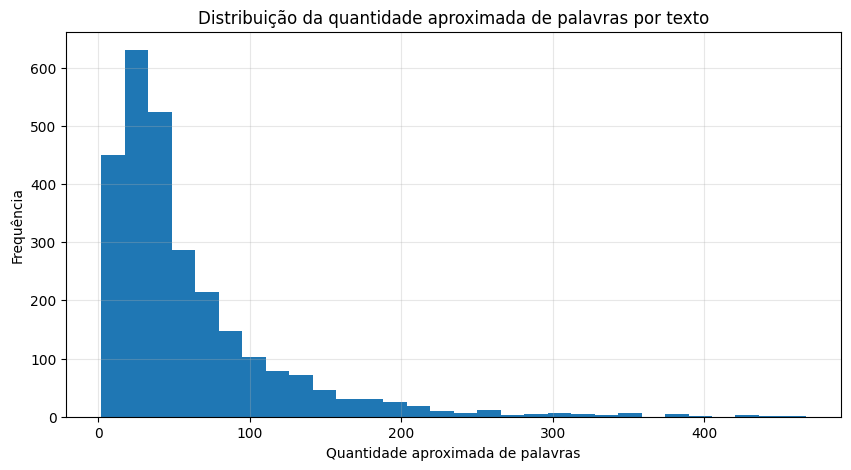

In [11]:
# ============================================================
# VISUALIZAÇÃO DA DISTRIBUIÇÃO DE PALAVRAS POR TEXTO
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df_textos["qtd_palavras"],
    bins=30
)

plt.title("Distribuição da quantidade aproximada de palavras por texto")
plt.xlabel("Quantidade aproximada de palavras")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)

plt.show()

## Remoção de duplicatas exatas

Antes de seguir para a análise de ruídos e TF-IDF, vamos remover textos exatamente duplicados.

Essa remoção evita que um mesmo projeto influencie de forma repetida as etapas de extração de termos, treinamento e clusterização.

In [12]:
# ============================================================
# REMOÇÃO DE TEXTOS DUPLICADOS
# ============================================================

quantidade_antes = len(df_textos)

duplicados_exatos = df_textos["texto"].duplicated().sum()

df_textos = df_textos.drop_duplicates(
    subset=["texto"]
).reset_index(drop=True)

quantidade_depois = len(df_textos)

print("Quantidade de textos antes da remoção de duplicatas:")
print(quantidade_antes)

print("\nQuantidade de textos exatamente duplicados:")
print(duplicados_exatos)

print("\nQuantidade de textos após a remoção de duplicatas:")
print(quantidade_depois)

print("\nTotal de linhas removidas:")
print(quantidade_antes - quantidade_depois)

Quantidade de textos antes da remoção de duplicatas:
2721

Quantidade de textos exatamente duplicados:
2

Quantidade de textos após a remoção de duplicatas:
2719

Total de linhas removidas:
2


## Base textual preparada

Ao final desta etapa, temos uma base textual inicial com:

- título do projeto;
- descrição pública;
- texto original;
- texto com título reforçado;
- quantidade de caracteres;
- quantidade de palavras.

Essa base será usada nas próximas etapas para análise de ruídos, TF-IDF, NER, BERTimbau e clusterização.

In [13]:
# ============================================================
# VISÃO FINAL DA BASE TEXTUAL INICIAL
# ============================================================

print("Formato final de df_textos:")
print(df_textos.shape)

print("\nColunas disponíveis:")
print(df_textos.columns.tolist())

print("\nAmostra final da base textual:")
display(df_textos.head(10))

Formato final de df_textos:
(2719, 7)

Colunas disponíveis:
['titulo', 'descricao', 'texto_original', 'texto_titulo_reforcado', 'texto', 'qtd_caracteres', 'qtd_palavras']

Amostra final da base textual:


,titulo,descricao,texto_original,texto_titulo_reforcado,texto,qtd_caracteres,qtd_palavras
0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e s...",Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...,Açúcar de frutas e aplicação em bolos como substituto da sacarose. Açúcar de frutas e aplicação em bolos como substi...,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...,707,102
1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a...",Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. Desenvolver uma linha de far...,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...,949,143
2,Desenvolvimento de cobertura líquida para sorvete,"O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, ...",Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mund...,Desenvolvimento de cobertura líquida para sorvete. Desenvolvimento de cobertura líquida para sorvete. O Brasil é con...,Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mund...,900,118
3,Desenvolvimento de conserva de tomate cereja,"O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mat...","Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o país com maior biodiversidade do mundo, com d...",Desenvolvimento de conserva de tomate cereja. Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o...,"Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o país com maior biodiversidade do mundo, com d...",968,137
4,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal,Nos últimos anos a comunidade científica tem despertado interesse na elaboração de alimentos utilizando como ingredi...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Nos últimos anos a comunida...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Desenvolvimento de massa al...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Nos últimos anos a comunida...,1347,187
5,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco,"O Estado de Mato Grosso do Sul apresenta uma grande diversidade de espécies nativas, sendo necessárias técnicas que ...",Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. O Estado de Mato Grosso do...,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. Desenvolvimento de Mistura...,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. O Estado de Mato Grosso do...,971,137
6,Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal,"O cacau é um fruto versátil, principalmente devido ao seu sabor, muito utilizado na forma de cacau em pó, polpa de c...",Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal. O cacau é um fruto...,Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal. Desenvolvimento de...,Desenvolvimento de mistura instantânea a base de café e cacau com ing

# 3. Análise de ruídos textuais

Antes de aplicar TF-IDF, NER, BERTimbau e clusterização, é importante analisar possíveis ruídos na base textual.

Neste projeto, consideramos como ruído forte apenas registros com alta chance de não conter informação útil para análise temática.

Exemplos de ruído forte:

- textos extremamente curtos;
- descrições explicitamente confidenciais ou não divulgadas;
- projetos cancelados ou pendentes.

Também serão marcados alguns alertas de ruído. Esses alertas não serão removidos automaticamente, mas indicam textos que podem merecer atenção, como:

- título igual à descrição;
- título mencionado dentro da descrição;
- texto curto, mas ainda possivelmente informativo;
- descrição vazia, mas com título informativo.

A estratégia adotada é conservadora. Em vez de remover muitos textos, removemos apenas os casos com evidência clara de baixa utilidade textual. Isso evita excluir projetos curtos, mas informativos.

In [14]:
# ============================================================
# NORMALIZAÇÃO AUXILIAR PARA ANÁLISE DE RUÍDOS
# ============================================================

def normalizar_texto_para_analise(texto: str) -> str:
    """
    Normaliza texto para análise de ruídos e busca textual.

    Esta função:
    - converte para minúsculas;
    - remove acentos;
    - remove espaços duplicados;
    - mantém apenas uma versão simplificada para comparação.

    Ela não substitui o texto original usado pelo BERTimbau.
    """

    texto = str(texto).lower()
    texto = remover_acentos(texto)
    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto


df_textos["titulo_norm"] = df_textos["titulo"].apply(normalizar_texto_para_analise)
df_textos["descricao_norm"] = df_textos["descricao"].apply(normalizar_texto_para_analise)
df_textos["texto_norm"] = df_textos["texto"].apply(normalizar_texto_para_analise)

print("Colunas auxiliares de normalização criadas:")
print(["titulo_norm", "descricao_norm", "texto_norm"])

Colunas auxiliares de normalização criadas:
['titulo_norm', 'descricao_norm', 'texto_norm']


In [15]:
# ============================================================
# CRITÉRIOS CONSERVADORES DE RUÍDO TEXTUAL
# ============================================================

# Descrições exatamente vazias ou sem conteúdo.
padroes_exatos_sem_conteudo = [
    "",
    "-",
    "--",
    "---",
    "a definir",
    "confidencial",
    "nao informado",
    "nao informada",
    "nao divulgado",
    "nao divulgada",
    "sem descricao",
    "sem informacao",
    "indisponivel"
]

# Expressões explícitas de descrição não divulgada.
padrao_descricao_nao_divulgada = (
    r"(confidencial\s+e\s+nao\s+pode\s+ser\s+divulgad[oa])|"
    r"(nao\s+pode\s+ser\s+divulgad[oa])|"
    r"(optamos\s+por\s+nao\s+apresentar)"
)

# Expressões explícitas de projeto cancelado ou pendente.
padrao_cancelado_ou_pendente = (
    r"\bprojeto\s+cancelado\b|"
    r"\bcancelado\b|"
    r"\bpendente\s+definicao\b|"
    r"\bpendente\s+de\s+definicao\b|"
    r"\bpendente\s+definição\b|"
    r"\bpendente\s+de\s+definição\b"
)

# Critérios principais.
df_textos["texto_extremamente_curto"] = df_textos["qtd_palavras"] <= 4

df_textos["descricao_sem_conteudo"] = df_textos["descricao_norm"].isin(
    padroes_exatos_sem_conteudo
)

df_textos["descricao_nao_divulgada"] = df_textos["descricao_norm"].str.contains(
    padrao_descricao_nao_divulgada,
    regex=True,
    na=False
)

df_textos["texto_cancelado_ou_pendente"] = df_textos["texto_norm"].str.contains(
    padrao_cancelado_ou_pendente,
    regex=True,
    na=False
)

# Critério final de remoção.
# Descrição vazia, sozinha, não remove o texto, pois o título pode ser informativo.
df_textos["ruido_forte"] = (
    df_textos["texto_extremamente_curto"]
    | df_textos["descricao_nao_divulgada"]
    | df_textos["texto_cancelado_ou_pendente"]
)

print("Critérios de ruído forte calculados.")

Critérios de ruído forte calculados.


In [16]:
# ============================================================
# CRITÉRIOS DE ALERTA DE RUÍDO
# ============================================================

df_textos["texto_curto_alerta"] = (
    (df_textos["qtd_palavras"] > 4)
    & (df_textos["qtd_palavras"] <= 10)
)

df_textos["titulo_igual_descricao"] = (
    df_textos["titulo_norm"] == df_textos["descricao_norm"]
)

df_textos["titulo_mencionado_na_descricao"] = df_textos.apply(
    lambda linha: (
        len(linha["titulo_norm"]) > 5
        and linha["titulo_norm"] in linha["descricao_norm"]
        and linha["titulo_norm"] != linha["descricao_norm"]
    ),
    axis=1
)

def calcular_razao_maiusculas(texto: str) -> float:
    """
    Calcula a proporção de letras maiúsculas em relação ao total de letras.
    """

    texto = str(texto)

    letras = [caractere for caractere in texto if caractere.isalpha()]

    if len(letras) == 0:
        return 0.0

    maiusculas = [caractere for caractere in letras if caractere.isupper()]

    return len(maiusculas) / len(letras)


df_textos["razao_maiusculas"] = df_textos["texto"].apply(calcular_razao_maiusculas)

df_textos["texto_caixa_alta"] = (
    (df_textos["razao_maiusculas"] > 0.60)
    & (df_textos["qtd_palavras"] > 4)
)

df_textos["alerta_ruido"] = (
    df_textos["texto_curto_alerta"]
    | df_textos["titulo_igual_descricao"]
    | df_textos["titulo_mencionado_na_descricao"]
    | df_textos["texto_caixa_alta"]
    | df_textos["descricao_sem_conteudo"]
)

print("Critérios de alerta de ruído calculados.")

Critérios de alerta de ruído calculados.


In [17]:
# ============================================================
# RESUMO DA ANÁLISE DE RUÍDOS
# ============================================================

resumo_ruidos = pd.DataFrame({
    "criterio": [
        "Texto extremamente curto",
        "Descrição explicitamente não divulgada",
        "Texto cancelado ou pendente",
        "Ruído forte final",
        "Descrição sem conteúdo",
        "Alerta de ruído"
    ],
    "quantidade": [
        df_textos["texto_extremamente_curto"].sum(),
        df_textos["descricao_nao_divulgada"].sum(),
        df_textos["texto_cancelado_ou_pendente"].sum(),
        df_textos["ruido_forte"].sum(),
        df_textos["descricao_sem_conteudo"].sum(),
        df_textos["alerta_ruido"].sum()
    ]
})

resumo_ruidos["percentual"] = (
    resumo_ruidos["quantidade"] / len(df_textos) * 100
).round(2)

display(resumo_ruidos)

print("\nExemplos de ruído forte:")
display(
    df_textos[df_textos["ruido_forte"]]
    [
        [
            "titulo",
            "descricao",
            "qtd_palavras",
            "texto_extremamente_curto",
            "descricao_nao_divulgada",
            "texto_cancelado_ou_pendente",
            "texto"
        ]
    ]
    .head(30)
)

print("\nExemplos de alerta de ruído que serão mantidos:")
display(
    df_textos[
        df_textos["alerta_ruido"]
        & ~df_textos["ruido_forte"]
    ]
    [
        [
            "titulo",
            "descricao",
            "qtd_palavras",
            "texto_curto_alerta",
            "titulo_igual_descricao",
            "titulo_mencionado_na_descricao",
            "descricao_sem_conteudo",
            "texto"
        ]
    ]
    .head(30)
)

,criterio,quantidade,percentual
0,Texto extremamente curto,8,0.29
1,Descrição explicitamente não divulgada,7,0.26
2,Texto cancelado ou pendente,3,0.11
3,Ruído forte final,17,0.63
4,Descrição sem conteúdo,6,0.22
5,Alerta de ruído,435,16.00



Exemplos de ruído forte:


,titulo,descricao,qtd_palavras,texto_extremamente_curto,descricao_nao_divulgada,texto_cancelado_ou_pendente,texto
192,PCS,Sistema PCS inteligente.,4,True,False,False,PCS. Sistema PCS inteligente.
429,PROJETO CANCELADO -,PROJETO CANCELADO,5,False,False,True,PROJETO CANCELADO -. PROJETO CANCELADO
491,Pendente definição do cliente,Pendente definição do cliente,8,False,False,True,Pendente definição do cliente. Pendente definição do cliente
657,HP - DeepShare 2020,O projeto é confidencial e não pode ser divulgado,13,False,True,False,HP - DeepShare 2020. O projeto é confidencial e não pode ser divulgado
658,HP - Z@Edge 2020,O projeto é confidencial e não pode ser divulgado.,13,False,True,False,HP - Z@Edge 2020. O projeto é confidencial e não pode ser divulgado.
659,HP - Z@EDGE21,O projeto é confidencial e não pode ser divulgado,12,False,True,False,HP - Z@EDGE21. O projeto é confidencial e não pode ser divulgado
695,MULTI DEVICE DOCK,O projeto é confidencial e não pode ser divulgado,12,False,True,False,MULTI DEVICE DOCK. O projeto é confidencial e não pode ser divulgado
734,Prova de Conceito de Computação Ubíqua UBIq (Phase 2),O projeto é confidencial e não pode ser divulgado.,18,False,True,False,Prova de Conceito de Computação Ubíqua UBIq (Phase 2). O projeto é confidencial e não pode ser divulgado.
797,UBI -Computação Ubíqua,O projeto é confidencial e não pode ser divulgado.,12,False,True,False,UBI -Computação Ubíqua. O projeto é confidencial e não pode ser divulgado.
1868,a definir,a definir,4,True,False,False,a definir. a definir



Exemplos de alerta de ruído que serão mantidos:


,titulo,descricao,qtd_palavras,texto_curto_alerta,titulo_igual_descricao,titulo_mencionado_na_descricao,descricao_sem_conteudo,texto
21,AGROSYSTEM,"A Agrosystem concentra seus esforços no desenvolvimento de maquinário agrícola de precisão, destacando-se por integr...",155,False,False,True,False,"AGROSYSTEM. A Agrosystem concentra seus esforços no desenvolvimento de maquinário agrícola de precisão, destacando-s..."
28,5GApps,Plataforma de software para Edge Computing baseada em 5G.,10,True,False,False,False,5GApps. Plataforma de software para Edge Computing baseada em 5G.
32,Active-IoT,Plataforma IoT para centrais de alarme.,7,True,False,False,False,Active-IoT. Plataforma IoT para centrais de alarme.
35,AGORA DIGITAL,Plataforma de software para inteligência regulatória.,8,True,False,False,False,AGORA DIGITAL. Plataforma de software para inteligência regulatória.
57,BEACON,Software embarcado de localização indoor.,6,True,False,False,False,BEACON. Software embarcado de localização indoor.
58,Bemago,Sistema para análise de dados de passagem de usuários.,10,True,False,False,False,Bemago. Sistema para análise de dados de passagem de usuários.
59,BillCrawler,O projeto objetiva o desenvolvimento de pesquisa e aplicação de técnicas de data scraping no contexto de dados finan...,56,False,False,True,False,BillCrawler. O projeto objetiva o desenvolvimento de pesquisa e aplicação de técnicas de data scraping no contexto d...
60,BIOMETRIC DETECTION,Software para detecção facial e biométrica usando vídeo.,10,True,False,False,False,BIOMETRIC DETECTION. Software para detecção facial e biométrica usando vídeo.
77,CORC,Sistemas de gerência de contêineres de computação em nuvem.,10,True,False,False,False,CORC. Sistemas de gerência de contêineres de computação em nuvem.
81,DARK STORES,"Desenvolvimento de uma plataforma digital integrada para que lojistas, fabricantes, varejistas, entre outros possam ...",64,False,False,True,False,"DARK STORES. Desenvolvimento de uma plataforma digital integrada para que lojistas, fabricantes, varejistas, entre o..."


## Filtragem conservadora da base

A partir da análise de ruídos, será criada a base `df_textos_filtrado`.

Essa base remove apenas os registros classificados como `ruido_forte`.

Os registros marcados apenas como alerta serão mantidos, pois podem conter informação temática útil. Por exemplo, um título curto como `Biofiller` pode ser pouco informativo, mas outros títulos curtos podem indicar tecnologias, produtos ou áreas relevantes.

Essa decisão preserva a maior parte da base e evita uma filtragem excessivamente agressiva.

In [18]:
# ============================================================
# CRIAÇÃO DA BASE FILTRADA FINAL
# ============================================================

quantidade_antes = len(df_textos)

df_textos_filtrado = df_textos[
    ~df_textos["ruido_forte"]
].reset_index(drop=True)

quantidade_depois = len(df_textos_filtrado)

print("Quantidade de textos na base completa:")
print(quantidade_antes)

print("\nQuantidade de textos na base filtrada:")
print(quantidade_depois)

print("\nQuantidade de textos removidos:")
print(quantidade_antes - quantidade_depois)

print("\nPercentual removido:")
print(f"{((quantidade_antes - quantidade_depois) / quantidade_antes * 100):.2f}%")

print("\nAmostra da base filtrada:")
display(
    df_textos_filtrado[
        [
            "titulo",
            "descricao",
            "texto",
            "qtd_palavras",
            "ruido_forte",
            "alerta_ruido"
        ]
    ].head(10)
)

Quantidade de textos na base completa:
2719

Quantidade de textos na base filtrada:
2702

Quantidade de textos removidos:
17

Percentual removido:
0.63%

Amostra da base filtrada:


,titulo,descricao,texto,qtd_palavras,ruido_forte,alerta_ruido
0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e s...",Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...,102,False,False
1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,"O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, destaca-se a...",Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...,143,False,False
2,Desenvolvimento de cobertura líquida para sorvete,"O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, ...",Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mund...,118,False,False
3,Desenvolvimento de conserva de tomate cereja,"O Brasil é considerado o país com maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mat...","Desenvolvimento de conserva de tomate cereja. O Brasil é considerado o país com maior biodiversidade do mundo, com d...",137,False,False
4,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal,Nos últimos anos a comunidade científica tem despertado interesse na elaboração de alimentos utilizando como ingredi...,Desenvolvimento de massa alimentícia enriquecida com fruto nativo do Cerrado e Pantanal. Nos últimos anos a comunida...,187,False,False
5,Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco,"O Estado de Mato Grosso do Sul apresenta uma grande diversidade de espécies nativas, sendo necessárias técnicas que ...",Desenvolvimento de Mistura Instantânea (Tipo Cappuccino) vegana com extrato vegetal seco. O Estado de Mato Grosso do...,137,False,False
6,Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal,"O cacau é um fruto versátil, principalmente devido ao seu sabor, muito utilizado na forma de cacau em pó, polpa de c...",Desenvolvimento de mistura instantânea a base de café e cacau com ingredientes de origem vegetal. O cacau é um fruto...,180,False,False
7,Desenvolvimento de molhos pesto de manjericão com castanhas do Brasil,Os pesquisadores na área da tecnologia de alimentos destacam a importância de pesquisas com o objetivo de inserir no...,Desenvolvimento de molhos pesto de manjericão com castanhas do Brasil. Os pesquisadores na área da tecnologia de ali...,73,False,False
8,Desenvolvimento de Shake instantâneo com frutos,"A busca por alimentos saudáveis e funcionais tem se intensificado na última década, o que aumentou com a ocorrência ...",Desenvolvimento de Shake instantâneo com frutos. A busca por alimentos saudáveis e funcionais tem se intensificado n...,175,False,False
9,Desenvolvimento de suplemento energético,"Atualmente observa-se uma mudança no perfil do consumidor, com maior preocupação com a saúde, buscando alternativas ...","Desenvolvimento de suplemento energético. Atualmente observa-se uma mudança no perfil do consumidor, com maior preoc...",353,False,False


# 4. Análise exploratória com TF-IDF

Após a limpeza conservadora, será feita uma análise exploratória com TF-IDF.

TF-IDF significa `Term Frequency - Inverse Document Frequency`.

Essa técnica atribui maior peso a termos que:

- aparecem com frequência em um texto;
- mas não aparecem igualmente em todos os textos da base.

Neste projeto, o TF-IDF será usado para:

1. identificar termos relevantes do dataset;
2. apoiar a criação das labels do NER;
3. observar diferenças entre `texto_original` e `texto_titulo_reforcado`;
4. auxiliar posteriormente na interpretação dos clusters.

O TF-IDF não substitui o BERTimbau. Ele é usado como ferramenta interpretativa e exploratória.

In [19]:
# ============================================================
# STOPWORDS REFINADAS PARA TF-IDF
# ============================================================

# Stopwords básicas do spaCy em português.
stopwords_portugues = set(
    remover_acentos(palavra.lower())
    for palavra in STOPWORDS_SPACY_PT
)

# Termos muito genéricos no contexto de projetos científicos.
# Esses termos podem aparecer em muitos projetos sem indicar um tema específico.
stopwords_dominio = {
    "projeto",
    "projetos",
    "desenvolvimento",
    "desenvolver",
    "desenvolvida",
    "desenvolvido",
    "desenvolvidas",
    "desenvolvidos",
    "pesquisa",
    "produto",
    "produtos",
    "processo",
    "processos",
    "solucao",
    "solucoes",
    "objetivo",
    "objetivos",
    "proposta",
    "forma",
    "uso",
    "utilizacao",
    "aplicacao",
    "aplicacoes",
    "meio",
    "metodo",
    "metodos",
    "metodologia",
    "analise",
    "avaliacao",
    "avaliar",
    "visa",
    "visando",
    "atraves",
    "partir",
    "base",
    "empresa",
    "mercado",
    "cliente",
    "clientes",
    "tecnica",
    "tecnicas",
    "tecnico",
    "tecnicos",
    "tecnologica",
    "tecnologicas",
    "inovacao",
    "inovacoes",
    "brasil",
    "brasileira",
    "brasileiro",
    "atualmente",
    "presente",
    "possivel",
    "diferentes",
    "novo",
    "nova",
    "novos",
    "novas",
    "melhoria",
    "melhorias",
    "obtencao",
    "alto",
    "alta",
    "baixo",
    "baixa"
}

stopwords_portugues_refinadas = sorted(
    stopwords_portugues.union(stopwords_dominio)
)

print("Quantidade de stopwords refinadas:")
print(len(stopwords_portugues_refinadas))

print("\nExemplos de stopwords refinadas:")
print(stopwords_portugues_refinadas[:100])

Quantidade de stopwords refinadas:
458

Exemplos de stopwords refinadas:
['a', 'acerca', 'ademais', 'adeus', 'agora', 'ai', 'ainda', 'alem', 'algo', 'algumas', 'alguns', 'ali', 'alta', 'alto', 'ambas', 'ambos', 'analise', 'antes', 'ao', 'aos', 'apenas', 'aplicacao', 'aplicacoes', 'apoia', 'apoio', 'apontar', 'apos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aqui', 'aquilo', 'area', 'as', 'assim', 'ate', 'atras', 'atraves', 'atualmente', 'avaliacao', 'avaliar', 'baixa', 'baixo', 'base', 'bastante', 'bem', 'boa', 'bom', 'brasil', 'brasileira', 'brasileiro', 'breve', 'ca', 'cada', 'caminho', 'catorze', 'cedo', 'cento', 'certamente', 'certeza', 'cima', 'cinco', 'cliente', 'clientes', 'coisa', 'com', 'como', 'comprida', 'comprido', 'conhecida', 'conhecido', 'conselho', 'contra', 'contudo', 'corrente', 'cuja', 'cujo', 'custa', 'da', 'dao', 'daquela', 'daquele', 'dar', 'das', 'de', 'debaixo', 'demais', 'dentro', 'depois', 'des', 'desde', 'desenvolver', 'desenvolvida', 'desenvolvidas', 'desen

In [20]:
# ============================================================
# FUNÇÃO PARA OBTER TERMOS MAIS IMPORTANTES POR TF-IDF
# ============================================================

def obter_top_termos_tfidf(matriz, termos, top_n=50):
    """
    Calcula os termos com maior peso médio de TF-IDF.

    Parâmetros
    ----------
    matriz:
        Matriz TF-IDF.

    termos:
        Lista ou array com os termos do vocabulário.

    top_n:
        Quantidade de termos retornados.

    Retorno
    -------
    pd.DataFrame
        Tabela com os principais termos e seus pesos médios.
    """

    pesos_medios = np.asarray(
        matriz.mean(axis=0)
    ).ravel()

    indices_top = pesos_medios.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "termo": termos[indices_top],
        "peso_tfidf_medio": pesos_medios[indices_top]
    })

In [21]:
# ============================================================
# TF-IDF GLOBAL NA BASE FILTRADA
# ============================================================

textos_para_tfidf = df_textos_filtrado["texto"].tolist()

vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.80
)

matriz_tfidf = vectorizer_tfidf.fit_transform(textos_para_tfidf)

termos_tfidf = np.array(
    vectorizer_tfidf.get_feature_names_out()
)

top_termos_globais = obter_top_termos_tfidf(
    matriz=matriz_tfidf,
    termos=termos_tfidf,
    top_n=80
)

print("Formato da matriz TF-IDF:")
print(matriz_tfidf.shape)

print("\nQuantidade de textos analisados:")
print(matriz_tfidf.shape[0])

print("\nQuantidade de termos considerados:")
print(matriz_tfidf.shape[1])

print("\nPrincipais termos globais pelo TF-IDF:")
display(top_termos_globais)

Formato da matriz TF-IDF:
(2702, 6118)

Quantidade de textos analisados:
2702

Quantidade de termos considerados:
6118

Principais termos globais pelo TF-IDF:


,termo,peso_tfidf_medio
0,producao,0.016557
1,software,0.016066
2,dados,0.014079
3,plataforma,0.013391
4,controle,0.012698
...,...,...
75,aumento,0.004511
76,smart,0.004504
77,operacao,0.004440
78,algoritmos,0.004411


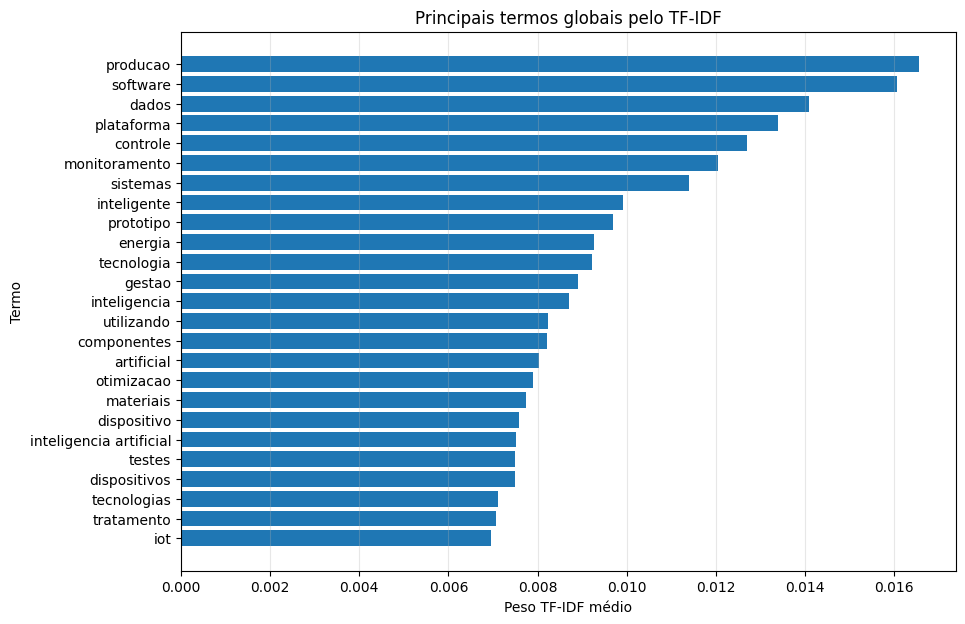

In [22]:
# ============================================================
# GRÁFICO DOS PRINCIPAIS TERMOS GLOBAIS PELO TF-IDF
# ============================================================

top_plot = top_termos_globais.head(25).sort_values(
    by="peso_tfidf_medio",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_plot["termo"],
    top_plot["peso_tfidf_medio"]
)

plt.title("Principais termos globais pelo TF-IDF")
plt.xlabel("Peso TF-IDF médio")
plt.ylabel("Termo")
plt.grid(True, axis="x", alpha=0.3)

plt.show()

## Frequência de termos após remoção de stopwords

Além do TF-IDF, também é útil observar a frequência simples dos termos.

A frequência mostra quais termos aparecem mais vezes na base. Já o TF-IDF mostra quais termos são mais relevantes considerando sua distribuição entre os textos.

A combinação dessas duas análises ajuda a identificar termos candidatos para criação das labels do NER.

In [23]:
# ============================================================
# FREQUÊNCIA DE TERMOS APÓS REMOÇÃO DE STOPWORDS
# ============================================================

vectorizer_freq = CountVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=3
)

matriz_freq = vectorizer_freq.fit_transform(
    df_textos_filtrado["texto"].tolist()
)

termos_freq = np.array(
    vectorizer_freq.get_feature_names_out()
)

frequencias = np.asarray(
    matriz_freq.sum(axis=0)
).ravel()

indices_ordenados = frequencias.argsort()[::-1][:100]

top_frequencias = pd.DataFrame({
    "termo": termos_freq[indices_ordenados],
    "frequencia": frequencias[indices_ordenados]
})

print("Termos mais frequentes após remoção de stopwords:")
display(top_frequencias.head(80))

Termos mais frequentes após remoção de stopwords:


,termo,frequencia
0,producao,539
1,dados,470
2,software,343
3,sistemas,343
4,controle,341
...,...,...
75,algoritmos,100
76,sensores,99
77,conceito,98
78,construcao,98


In [24]:
# ============================================================
# TERMOS CANDIDATOS PARA APOIAR O NER
# ============================================================

termos_candidatos = top_termos_globais.merge(
    top_frequencias,
    on="termo",
    how="outer"
)

termos_candidatos["peso_tfidf_medio"] = termos_candidatos[
    "peso_tfidf_medio"
].fillna(0)

termos_candidatos["frequencia"] = termos_candidatos[
    "frequencia"
].fillna(0).astype(int)

termos_candidatos = termos_candidatos.sort_values(
    by=["peso_tfidf_medio", "frequencia"],
    ascending=False
).reset_index(drop=True)

print("Termos candidatos para apoiar a criação das labels do NER:")
display(termos_candidatos.head(100))

Termos candidatos para apoiar a criação das labels do NER:


,termo,peso_tfidf_medio,frequencia
0,producao,0.016557,539
1,software,0.016066,343
2,dados,0.014079,470
3,plataforma,0.013391,324
4,controle,0.012698,341
...,...,...,...
95,sendo,0.000000,86
96,nacional,0.000000,84
97,custos,0.000000,83
98,utilizados,0.000000,82


# 5. Comparação entre texto original e título reforçado

Na preparação da base, foram criadas duas representações textuais:

- `texto_original`;
- `texto_titulo_reforcado`.

A versão com título reforçado repete o título antes da descrição. Essa estratégia foi testada porque o título costuma resumir o tema principal do projeto.

Nesta etapa, a comparação será feita inicialmente com TF-IDF. Mais adiante, a comparação será feita também com embeddings BERTimbau e clusterização.

O objetivo é verificar se reforçar o título altera os termos principais e se essa alteração pode ser útil para a clusterização temática.

In [25]:
# ============================================================
# FUNÇÃO PARA CALCULAR TF-IDF DE UMA COLUNA TEXTUAL
# ============================================================

def calcular_top_tfidf_coluna(df_base, coluna_texto, top_n=40):
    """
    Calcula os principais termos TF-IDF de uma coluna textual.
    """

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words=stopwords_portugues_refinadas,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.80
    )

    matriz = vectorizer.fit_transform(
        df_base[coluna_texto].tolist()
    )

    termos = np.array(
        vectorizer.get_feature_names_out()
    )

    top_termos = obter_top_termos_tfidf(
        matriz=matriz,
        termos=termos,
        top_n=top_n
    )

    return top_termos, matriz, termos


top_tfidf_texto_original, matriz_tfidf_original, termos_tfidf_original = calcular_top_tfidf_coluna(
    df_base=df_textos_filtrado,
    coluna_texto="texto_original",
    top_n=40
)

top_tfidf_titulo_reforcado, matriz_tfidf_titulo_reforcado, termos_tfidf_titulo_reforcado = calcular_top_tfidf_coluna(
    df_base=df_textos_filtrado,
    coluna_texto="texto_titulo_reforcado",
    top_n=40
)

comparacao_tfidf_titulo = pd.DataFrame({
    "termo_texto_original": top_tfidf_texto_original["termo"],
    "peso_texto_original": top_tfidf_texto_original["peso_tfidf_medio"],
    "termo_texto_titulo_reforcado": top_tfidf_titulo_reforcado["termo"],
    "peso_texto_titulo_reforcado": top_tfidf_titulo_reforcado["peso_tfidf_medio"]
})

print("Comparação dos principais termos por TF-IDF:")
display(comparacao_tfidf_titulo)

Comparação dos principais termos por TF-IDF:


,termo_texto_original,peso_texto_original,termo_texto_titulo_reforcado,peso_texto_titulo_reforcado
0,producao,0.016557,producao,0.016346
1,software,0.016066,software,0.014566
2,dados,0.014079,plataforma,0.013894
3,plataforma,0.013391,dados,0.013151
4,controle,0.012698,monitoramento,0.012776
5,monitoramento,0.012054,controle,0.012663
6,sistemas,0.011391,inteligente,0.011639
7,inteligente,0.009910,sistemas,0.011102
8,prototipo,0.009696,energia,0.009047
9,energia,0.009276,prototipo,0.009025


## Interpretação parcial do TF-IDF

A análise com TF-IDF permite observar quais termos são mais relevantes na base após a remoção de palavras muito genéricas.

Essa etapa tem três funções principais no projeto:

1. apoiar a criação das labels do NER;
2. indicar áreas frequentes nos projetos;
3. ajudar na interpretação posterior dos clusters.

A comparação entre `texto_original` e `texto_titulo_reforcado` também permite avaliar se o título contém informação temática relevante.

A decisão final sobre o uso do título reforçado será feita mais adiante, durante a comparação das representações na clusterização.

In [26]:
# ============================================================
# SALVAMENTO DOS RESULTADOS PARCIAIS
# ============================================================

resumo_ruidos.to_csv(
    os.path.join(OUTPUT_DIR, "resumo_ruidos.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_textos_filtrado.to_csv(
    os.path.join(OUTPUT_DIR, "df_textos_filtrado_inicial.csv"),
    index=False,
    encoding="utf-8-sig"
)

top_termos_globais.to_csv(
    os.path.join(OUTPUT_DIR, "top_termos_tfidf_global.csv"),
    index=False,
    encoding="utf-8-sig"
)

top_frequencias.to_csv(
    os.path.join(OUTPUT_DIR, "top_frequencias_termos.csv"),
    index=False,
    encoding="utf-8-sig"
)

termos_candidatos.to_csv(
    os.path.join(OUTPUT_DIR, "termos_candidatos_ner.csv"),
    index=False,
    encoding="utf-8-sig"
)

comparacao_tfidf_titulo.to_csv(
    os.path.join(OUTPUT_DIR, "comparacao_tfidf_titulo.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos parciais salvos em:")
print(OUTPUT_DIR)

print("\nArquivos disponíveis:")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Arquivos parciais salvos em:
/kaggle/working/resultados_parciais

Arquivos disponíveis:
- comparacao_tfidf_titulo.csv
- df_textos_filtrado_inicial.csv
- resumo_ruidos.csv
- termos_candidatos_ner.csv
- top_frequencias_termos.csv
- top_termos_tfidf_global.csv


# 6. Definição das labels finais do NER

Nesta etapa, vamos definir as labels usadas no treinamento do modelo de NER.

NER significa `Named Entity Recognition`, ou reconhecimento de entidades nomeadas. Em tarefas tradicionais, o NER identifica entidades como pessoas, organizações, locais, datas e valores.

Neste projeto, o NER será usado de forma personalizada para identificar expressões ligadas a áreas temáticas dos projetos científicos.

As labels finais foram definidas com base em:

- análise dos termos mais relevantes pelo TF-IDF;
- inspeção manual dos títulos e descrições;
- resultados preliminares de clusterização;
- necessidade de cobrir projetos de sistemas, automação, controle e monitoramento.

As labels finais são:

1. `AREA_COMPUTACAO_DADOS`
2. `AREA_ENERGIA`
3. `AREA_MEIO_AMBIENTE_SUSTENTABILIDADE`
4. `AREA_SAUDE_BIOTECNOLOGIA`
5. `AREA_ALIMENTOS_AGRO`
6. `AREA_ENGENHARIA_MATERIAIS`
7. `AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO`

A última label foi adicionada porque a análise preliminar mostrou muitos projetos com vocabulário técnico-operacional, como sistemas, controle, monitoramento, sensores, hardware e equipamentos. Esses projetos não eram bem representados pelas seis labels iniciais.

In [27]:
# ============================================================
# LABELS FINAIS DO NER
# ============================================================

labels_ner_treino_v2 = {
    "AREA_COMPUTACAO_DADOS": {
        "descricao": "Computação, software, IA, algoritmos, IoT, nuvem e sistemas digitais.",
        "termos_referencia": [
            "software",
            "software embarcado",
            "inteligência artificial",
            "inteligencia artificial",
            "machine learning",
            "aprendizado de máquina",
            "aprendizagem de máquina",
            "algoritmo",
            "algoritmos",
            "iot",
            "internet das coisas",
            "nuvem",
            "big data",
            "analytics",
            "edge computing",
            "visão computacional",
            "visao computacional",
            "processamento de imagens",
            "mineração de dados",
            "mineracao de dados",
            "classificação de documentos",
            "classificacao de documentos",
            "extração inteligente",
            "extracao inteligente",
            "plataforma digital"
        ]
    },

    "AREA_ENERGIA": {
        "descricao": "Energia elétrica, energia solar, baterias, eficiência energética e veículos elétricos.",
        "termos_referencia": [
            "energia solar",
            "energia elétrica",
            "energia eletrica",
            "eficiência energética",
            "eficiencia energetica",
            "consumo energético",
            "consumo energetico",
            "geração de energia",
            "geracao de energia",
            "bateria",
            "baterias",
            "íons-lítio",
            "ions-litio",
            "lítio",
            "litio",
            "conversor",
            "conversores",
            "veículo elétrico",
            "veiculo eletrico",
            "veículos elétricos",
            "veiculos eletricos",
            "fotovoltaico",
            "solar tracking",
            "bess"
        ]
    },

    "AREA_MEIO_AMBIENTE_SUSTENTABILIDADE": {
        "descricao": "Sustentabilidade, resíduos, efluentes, carbono, reciclagem e impacto ambiental.",
        "termos_referencia": [
            "sustentabilidade",
            "sustentável",
            "sustentavel",
            "resíduo",
            "residuo",
            "resíduos",
            "residuos",
            "resíduos sólidos",
            "residuos solidos",
            "efluentes",
            "poluentes",
            "crédito de carbono",
            "credito de carbono",
            "carbono",
            "reciclagem",
            "reaproveitamento",
            "reutilização",
            "reutilizacao",
            "bioplástico",
            "bioplastico",
            "biodegradável",
            "biodegradavel",
            "impacto ambiental",
            "tratamento de água",
            "tratamento de agua",
            "águas residuais",
            "aguas residuais"
        ]
    },

    "AREA_SAUDE_BIOTECNOLOGIA": {
        "descricao": "Saúde, biotecnologia, biofármacos, enzimas, vacinas e aplicações biomédicas.",
        "termos_referencia": [
            "saúde",
            "saude",
            "biotecnologia",
            "biofármaco",
            "biofarmaco",
            "biofármacos",
            "biofarmacos",
            "enzima",
            "enzimas",
            "vacina",
            "vacinas",
            "diagnóstico",
            "diagnostico",
            "diagnósticos",
            "diagnosticos",
            "micro-organismos",
            "microrganismos",
            "hibridoma",
            "biomaterial",
            "biomateriais",
            "microstent",
            "biomédica",
            "biomedica",
            "terapia",
            "anticorpos",
            "probióticos",
            "probioticos"
        ]
    },

    "AREA_ALIMENTOS_AGRO": {
        "descricao": "Alimentos, agricultura, fertilizantes, cultivo, frutas, bioinsumos e agroindústria.",
        "termos_referencia": [
            "alimentos",
            "alimentício",
            "alimenticio",
            "alimentícia",
            "alimenticia",
            "agricultura",
            "agrícola",
            "agricola",
            "agroindustrial",
            "fertilizante",
            "fertilizantes",
            "biofertilizante",
            "biofertilizantes",
            "cultivo",
            "soja",
            "cacau",
            "tomate",
            "pitaya",
            "castanhas",
            "farofa",
            "sorvete",
            "geleia",
            "massa alimentícia",
            "massa alimenticia",
            "bioinsumo",
            "bioinsumos",
            "bioinseticida",
            "fungos entomopatogênicos",
            "fungos entomopatogenicos"
        ]
    },

    "AREA_ENGENHARIA_MATERIAIS": {
        "descricao": "Engenharia, materiais, manufatura, fabricação, aço, ligas e propriedades mecânicas.",
        "termos_referencia": [
            "manufatura aditiva",
            "fabricação",
            "fabricacao",
            "usinagem",
            "tratamento térmico",
            "tratamento termico",
            "propriedades mecânicas",
            "propriedades mecanicas",
            "ligas metálicas",
            "ligas metalicas",
            "liga metálica",
            "liga metalica",
            "titânio",
            "titanio",
            "aço",
            "aco",
            "aços",
            "acos",
            "compósitos",
            "compositos",
            "nanocompósito",
            "nanocomposito",
            "material resistente",
            "materiais compósitos",
            "materiais compositos",
            "mancais magnéticos",
            "mancais magneticos",
            "engrenagens",
            "componentes mecânicos",
            "componentes mecanicos",
            "metalurgia",
            "corrosão",
            "corrosao",
            "estampagem a quente"
        ]
    },

    "AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO": {
        "descricao": "Sistemas, automação, controle, monitoramento, sensores, hardware e equipamentos.",
        "termos_referencia": [
            "sistema de controle",
            "sistemas de controle",
            "controle de processos",
            "controle automático",
            "controle automatico",
            "monitoramento",
            "sistema de monitoramento",
            "monitoramento remoto",
            "automação",
            "automacao",
            "automação industrial",
            "automacao industrial",
            "sensores",
            "sensor",
            "hardware",
            "sistema embarcado",
            "sistemas embarcados",
            "aquisição de dados",
            "aquisicao de dados",
            "coleta de dados",
            "telemetria",
            "rastreabilidade",
            "rastreamento",
            "manutenção",
            "manutencao",
            "equipamento",
            "equipamentos",
            "dispositivo",
            "dispositivos",
            "controle remoto",
            "instrumentação",
            "instrumentacao"
        ]
    }
}

df_labels_ner_treino_v2 = pd.DataFrame([
    {
        "label": label,
        "descricao": conteudo["descricao"],
        "qtd_termos": len(conteudo["termos_referencia"]),
        "exemplos_de_termos": ", ".join(conteudo["termos_referencia"][:10])
    }
    for label, conteudo in labels_ner_treino_v2.items()
])

display(df_labels_ner_treino_v2)

,label,descricao,qtd_termos,exemplos_de_termos
0,AREA_COMPUTACAO_DADOS,"Computação, software, IA, algoritmos, IoT, nuvem e sistemas digitais.",25,"software, software embarcado, inteligência artificial, inteligencia artificial, machine learning, aprendizado de máq..."
1,AREA_ENERGIA,"Energia elétrica, energia solar, baterias, eficiência energética e veículos elétricos.",24,"energia solar, energia elétrica, energia eletrica, eficiência energética, eficiencia energetica, consumo energético,..."
2,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,"Sustentabilidade, resíduos, efluentes, carbono, reciclagem e impacto ambiental.",27,"sustentabilidade, sustentável, sustentavel, resíduo, residuo, resíduos, residuos, resíduos sólidos, residuos solidos..."
3,AREA_SAUDE_BIOTECNOLOGIA,"Saúde, biotecnologia, biofármacos, enzimas, vacinas e aplicações biomédicas.",27,"saúde, saude, biotecnologia, biofármaco, biofarmaco, biofármacos, biofarmacos, enzima, enzimas, vacina"
4,AREA_ALIMENTOS_AGRO,"Alimentos, agricultura, fertilizantes, cultivo, frutas, bioinsumos e agroindústria.",29,"alimentos, alimentício, alimenticio, alimentícia, alimenticia, agricultura, agrícola, agricola, agroindustrial, fert..."
5,AREA_ENGENHARIA_MATERIAIS,"Engenharia, materiais, manufatura, fabricação, aço, ligas e propriedades mecânicas.",34,"manufatura aditiva, fabricação, fabricacao, usinagem, tratamento térmico, tratamento termico, propriedades mecânicas..."
6,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,"Sistemas, automação, controle, monitoramento, sensores, hardware e equipamentos.",32,"sistema de controle, sistemas de controle, controle de processos, controle automático, controle automatico, monitora..."


## Construção automática de entidades candidatas

Para treinar o NER, precisamos criar exemplos no formato aceito pelo spaCy.

Cada entidade é representada por uma tupla:
(inicio, fim, label)

In [28]:
# ============================================================
# FUNÇÕES PARA BUSCA E GERAÇÃO DE SPANS
# ============================================================

nlp_validacao = spacy.blank("pt")


def criar_padrao_regex_original(termo: str) -> str:
    """
    Cria um padrão regex seguro para buscar um termo no texto original.

    O padrão usa limites de palavra para evitar que termos sejam encontrados
    dentro de outras palavras.
    """

    termo = str(termo).strip()

    partes = termo.split()

    partes_escape = [
        re.escape(parte)
        for parte in partes
    ]

    termo_regex = r"\s+".join(partes_escape)

    padrao = r"(?<!\w)" + termo_regex + r"(?!\w)"

    return padrao


def extrair_entidades_texto(texto: str, labels: dict, nlp_tokenizer) -> list:
    """
    Extrai entidades candidatas de um texto.

    Retorna uma lista no formato:
    (inicio, fim, label)
    """

    doc = nlp_tokenizer.make_doc(texto)

    spans_candidatos = []

    for label, conteudo in labels.items():
        for termo in conteudo["termos_referencia"]:
            padrao = criar_padrao_regex_original(termo)

            for match in re.finditer(padrao, texto, flags=re.IGNORECASE):
                inicio, fim = match.start(), match.end()

                span = doc.char_span(
                    inicio,
                    fim,
                    label=label,
                    alignment_mode="expand"
                )

                if span is not None:
                    spans_candidatos.append(span)

    spans_filtrados = filter_spans(spans_candidatos)

    entidades = [
        (span.start_char, span.end_char, span.label_)
        for span in spans_filtrados
    ]

    return entidades


def criar_dataframe_entidades_candidatas(df_base, labels):
    """
    Cria uma tabela com todas as entidades candidatas encontradas.
    """

    registros = []

    for indice, linha in df_base.iterrows():
        texto = linha["texto"]

        entidades = extrair_entidades_texto(
            texto=texto,
            labels=labels,
            nlp_tokenizer=nlp_validacao
        )

        for inicio, fim, label in entidades:
            registros.append({
                "indice_texto": indice,
                "label": label,
                "entidade": texto[inicio:fim],
                "inicio": inicio,
                "fim": fim,
                "titulo": linha["titulo"],
                "texto": texto
            })

    return pd.DataFrame(registros)

In [29]:
# ============================================================
# CRIAÇÃO DA TABELA DE ENTIDADES CANDIDATAS
# ============================================================

df_entidades_candidatas_v2 = criar_dataframe_entidades_candidatas(
    df_base=df_textos_filtrado,
    labels=labels_ner_treino_v2
)

print("Quantidade total de entidades candidatas encontradas:")
print(len(df_entidades_candidatas_v2))

print("\nQuantidade de entidades candidatas por label:")
display(
    df_entidades_candidatas_v2["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="quantidade")
)

print("\nAmostra de entidades candidatas:")
display(df_entidades_candidatas_v2.head(100))

Quantidade total de entidades candidatas encontradas:
4717

Quantidade de entidades candidatas por label:


,label,quantidade
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,1524
1,AREA_COMPUTACAO_DADOS,1173
2,AREA_ENGENHARIA_MATERIAIS,562
3,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,495
4,AREA_ALIMENTOS_AGRO,343
5,AREA_ENERGIA,320
6,AREA_SAUDE_BIOTECNOLOGIA,300



Amostra de entidades candidatas:


,indice_texto,label,entidade,inicio,fim,titulo,texto
0,0,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,sustentável,200,211,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
1,0,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,Sustentável,374,385,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
2,0,AREA_ALIMENTOS_AGRO,alimentos,697,706,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
3,1,AREA_ALIMENTOS_AGRO,castanhas,37,46,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...
4,1,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,sustentável,745,756,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...
...,...,...,...,...,...,...,...
95,19,AREA_ENGENHARIA_MATERIAIS,componentes mecânicos,145,166,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais. O estado de tensão residual influencia amplamente n...
96,19,AREA_ENGENHARIA_MATERIAIS,componentes mecânicos,327,348,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais. O estado de tensão residual influencia amplamente n...
97,19,AREA_ENGENHARIA_MATERIAIS,engrenagens,358,369,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais. O estado de tensão residual influencia amplamente n...
98,19,AREA_ENGENHARIA_MATERIAIS,fabricação,757,767,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais,DRS: DEMO - Demonstrador Técnico Econômico de Tensões Residuais. O estado de tensão residual influencia amplamente n...


# 7. Construção do TRAINING_DATA

Agora será criado o `TRAINING_DATA` para o treinamento do NER.

A estratégia adotada será balanceada:

- limitar a quantidade de exemplos positivos por label;
- incluir exemplos negativos, ou seja, textos sem entidades anotadas;
- embaralhar os exemplos para evitar viés de ordem;
- validar automaticamente os spans.

Os exemplos negativos são importantes porque ajudam o modelo a aprender que nem todo texto contém necessariamente uma entidade temática.

In [30]:
# ============================================================
# FUNÇÃO PARA CRIAR TRAINING_DATA BALANCEADO
# ============================================================

def criar_training_data_balanceado(
    df_base,
    labels,
    max_exemplos_por_label=90,
    max_exemplos_negativos=60,
    random_state=42
):
    """
    Cria um TRAINING_DATA balanceado para treinamento do NER.

    A função percorre os textos, extrai entidades candidatas e seleciona
    exemplos até atingir um limite por label.

    Também adiciona exemplos negativos, ou seja, textos sem entidades.
    """

    rng = np.random.default_rng(random_state)

    indices_embaralhados = list(df_base.index)
    rng.shuffle(indices_embaralhados)

    contagem_labels = Counter()

    exemplos_positivos = []
    exemplos_negativos = []

    for indice in indices_embaralhados:
        texto = df_base.loc[indice, "texto"]

        entidades = extrair_entidades_texto(
            texto=texto,
            labels=labels,
            nlp_tokenizer=nlp_validacao
        )

        if len(entidades) == 0:
            exemplos_negativos.append(
                (texto, {"entities": []})
            )
            continue

        labels_no_texto = set(
            label
            for _, _, label in entidades
        )

        deve_incluir = any(
            contagem_labels[label] < max_exemplos_por_label
            for label in labels_no_texto
        )

        if deve_incluir:
            exemplos_positivos.append(
                (texto, {"entities": entidades})
            )

            for label in labels_no_texto:
                contagem_labels[label] += 1

        if all(
            contagem_labels[label] >= max_exemplos_por_label
            for label in labels.keys()
        ):
            break

    rng.shuffle(exemplos_negativos)

    exemplos_negativos = exemplos_negativos[
        :max_exemplos_negativos
    ]

    training_data = exemplos_positivos + exemplos_negativos

    rng.shuffle(training_data)

    return training_data

In [31]:
# ============================================================
# VALIDAÇÃO DO TRAINING_DATA
# ============================================================

def validar_training_data(training_data, nlp_tokenizer):
    """
    Valida o TRAINING_DATA verificando se as entidades estão alinhadas
    com a tokenização do spaCy.
    """

    training_data_validado = []
    problemas = []

    for i, (texto, anotacoes) in enumerate(training_data):
        entidades = anotacoes.get("entities", [])

        doc = nlp_tokenizer.make_doc(texto)

        try:
            tags = offsets_to_biluo_tags(
                doc,
                entidades
            )

            if "-" in tags:
                problemas.append({
                    "indice_exemplo": i,
                    "motivo": "Span desalinhado",
                    "texto": texto,
                    "entidades": entidades,
                    "tags": tags
                })
            else:
                training_data_validado.append(
                    (texto, {"entities": entidades})
                )

        except Exception as erro:
            problemas.append({
                "indice_exemplo": i,
                "motivo": str(erro),
                "texto": texto,
                "entidades": entidades,
                "tags": None
            })

    return training_data_validado, problemas

In [32]:
# ============================================================
# CRIAÇÃO E VALIDAÇÃO DO TRAINING_DATA V2
# ============================================================

TRAINING_DATA_V2 = criar_training_data_balanceado(
    df_base=df_textos_filtrado,
    labels=labels_ner_treino_v2,
    max_exemplos_por_label=90,
    max_exemplos_negativos=60,
    random_state=RANDOM_STATE
)

TRAINING_DATA_V2_VALIDADO, problemas_training_data_v2 = validar_training_data(
    training_data=TRAINING_DATA_V2,
    nlp_tokenizer=nlp_validacao
)

print("Quantidade total de exemplos no TRAINING_DATA_V2:")
print(len(TRAINING_DATA_V2))

print("\nQuantidade de exemplos válidos:")
print(len(TRAINING_DATA_V2_VALIDADO))

print("\nQuantidade de exemplos com problemas:")
print(len(problemas_training_data_v2))

contagem_entidades_v2 = Counter()

for _, anotacoes in TRAINING_DATA_V2_VALIDADO:
    for _, _, label in anotacoes["entities"]:
        contagem_entidades_v2[label] += 1

df_contagem_entidades_v2 = pd.DataFrame(
    contagem_entidades_v2.items(),
    columns=["label", "quantidade_entidades"]
).sort_values(
    by="quantidade_entidades",
    ascending=False
)

print("\nDistribuição de entidades no TRAINING_DATA_V2_VALIDADO:")
display(df_contagem_entidades_v2)

if len(problemas_training_data_v2) > 0:
    print("\nAmostra de problemas encontrados:")
    display(pd.DataFrame(problemas_training_data_v2).head())

Quantidade total de exemplos no TRAINING_DATA_V2:
570

Quantidade de exemplos válidos:
570

Quantidade de exemplos com problemas:
0

Distribuição de entidades no TRAINING_DATA_V2_VALIDADO:


,label,quantidade_entidades
2,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,354
0,AREA_ENGENHARIA_MATERIAIS,236
6,AREA_COMPUTACAO_DADOS,229
1,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,192
5,AREA_ENERGIA,192
4,AREA_ALIMENTOS_AGRO,189
3,AREA_SAUDE_BIOTECNOLOGIA,156


## Ajuste de entidades ambíguas

A inspeção dos exemplos mostrou que alguns termos podem ser semanticamente ambíguos.

O principal caso é `diagnóstico`. Essa palavra pode aparecer em textos de saúde, mas também em contextos de diagnóstico de falhas, diagnóstico de equipamentos ou diagnóstico operacional.

Para evitar que o modelo associe qualquer ocorrência de `diagnóstico` à área de saúde e biotecnologia, esse termo será removido das anotações quando estiver ligado à label `AREA_SAUDE_BIOTECNOLOGIA`.

Essa decisão melhora a precisão sem alterar a estrutura geral do conjunto de treinamento.

In [33]:
# ============================================================
# FILTRO DE ENTIDADES AMBÍGUAS
# ============================================================

def normalizar_entidade_filtro(texto: str) -> str:
    """
    Normaliza uma entidade para comparação simples.
    """

    texto = str(texto).lower()
    texto = remover_acentos(texto)
    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto


termos_saude_ambiguos = {
    "diagnostico",
    "diagnosticos"
}


def filtrar_entidades_ambiguas(training_data):
    """
    Remove entidades semanticamente ambíguas do TRAINING_DATA.
    """

    training_data_filtrado = []

    for texto, anotacoes in training_data:
        entidades_filtradas = []

        for inicio, fim, label in anotacoes["entities"]:
            entidade_texto = texto[inicio:fim]

            entidade_norm = normalizar_entidade_filtro(
                entidade_texto
            )

            remover = (
                label == "AREA_SAUDE_BIOTECNOLOGIA"
                and entidade_norm in termos_saude_ambiguos
            )

            if not remover:
                entidades_filtradas.append(
                    (inicio, fim, label)
                )

        training_data_filtrado.append(
            (texto, {"entities": entidades_filtradas})
        )

    return training_data_filtrado

In [34]:
# ============================================================
# APLICAÇÃO DO FILTRO DE ENTIDADES AMBÍGUAS
# ============================================================

TRAINING_DATA_V2_AJUSTADO = filtrar_entidades_ambiguas(
    TRAINING_DATA_V2_VALIDADO
)

TRAINING_DATA_V2_AJUSTADO, problemas_ajuste_v2 = validar_training_data(
    training_data=TRAINING_DATA_V2_AJUSTADO,
    nlp_tokenizer=nlp_validacao
)

print("Total de exemplos no TRAINING_DATA_V2_AJUSTADO:")
print(len(TRAINING_DATA_V2_AJUSTADO))

print("\nTotal de problemas após ajuste:")
print(len(problemas_ajuste_v2))

contagem_entidades_v2_ajustada = Counter()

for _, anotacoes in TRAINING_DATA_V2_AJUSTADO:
    for _, _, label in anotacoes["entities"]:
        contagem_entidades_v2_ajustada[label] += 1

df_contagem_entidades_v2_ajustada = pd.DataFrame(
    contagem_entidades_v2_ajustada.items(),
    columns=["label", "quantidade_entidades"]
).sort_values(
    by="quantidade_entidades",
    ascending=False
)

print("\nDistribuição de entidades após ajuste:")
display(df_contagem_entidades_v2_ajustada)

Total de exemplos no TRAINING_DATA_V2_AJUSTADO:
570

Total de problemas após ajuste:
0

Distribuição de entidades após ajuste:


,label,quantidade_entidades
2,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,354
0,AREA_ENGENHARIA_MATERIAIS,236
6,AREA_COMPUTACAO_DADOS,229
1,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,192
5,AREA_ENERGIA,192
4,AREA_ALIMENTOS_AGRO,189
3,AREA_SAUDE_BIOTECNOLOGIA,113


# 8. Treinamento do modelo NER

Agora vamos treinar o modelo de NER com spaCy.

O modelo será treinado para reconhecer as sete labels temáticas definidas anteriormente.

A base será dividida em treino e validação. A validação será usada para observar o desempenho do modelo em exemplos que não foram usados diretamente no treinamento.

As métricas avaliadas serão:

- precisão;
- revocação;
- F1-score;
- métricas por label.

Como o `TRAINING_DATA` foi criado de forma semiautomática, as métricas devem ser interpretadas com cuidado. Elas indicam o quanto o modelo aprendeu o padrão de anotação construído, mas não substituem avaliação manual completa.

In [35]:
# ============================================================
# DIVISÃO ENTRE TREINO E VALIDAÇÃO
# ============================================================

def dividir_treino_validacao(
    training_data,
    proporcao_treino=0.85,
    random_state=42
):
    """
    Divide o TRAINING_DATA em treino e validação.
    """

    rng = np.random.default_rng(random_state)

    indices = np.arange(
        len(training_data)
    )

    rng.shuffle(indices)

    limite_treino = int(
        len(indices) * proporcao_treino
    )

    indices_treino = indices[:limite_treino]
    indices_validacao = indices[limite_treino:]

    dados_treino = [
        training_data[i]
        for i in indices_treino
    ]

    dados_validacao = [
        training_data[i]
        for i in indices_validacao
    ]

    return dados_treino, dados_validacao


DADOS_TREINO_NER_V2, DADOS_VALIDACAO_NER_V2 = dividir_treino_validacao(
    training_data=TRAINING_DATA_V2_AJUSTADO,
    proporcao_treino=0.85,
    random_state=RANDOM_STATE
)

print("Quantidade de exemplos para treino:")
print(len(DADOS_TREINO_NER_V2))

print("\nQuantidade de exemplos para validação:")
print(len(DADOS_VALIDACAO_NER_V2))

Quantidade de exemplos para treino:
484

Quantidade de exemplos para validação:
86


In [36]:
# ============================================================
# TREINAMENTO DO MODELO NER V2
# ============================================================

nlp_ner_v2 = spacy.blank("pt")

ner_v2 = nlp_ner_v2.add_pipe("ner")

for texto, anotacoes in DADOS_TREINO_NER_V2:
    for _, _, label in anotacoes["entities"]:
        ner_v2.add_label(label)

print("Labels adicionadas ao NER V2:")
print(ner_v2.labels)


def gerar_exemplos_inicializacao_v2():
    """
    Gera exemplos para inicialização do modelo spaCy.
    """

    for texto, anotacoes in DADOS_TREINO_NER_V2:
        doc = nlp_ner_v2.make_doc(texto)
        yield Example.from_dict(doc, anotacoes)


optimizer_v2 = nlp_ner_v2.initialize(
    get_examples=gerar_exemplos_inicializacao_v2
)

N_EPOCHS_V2 = 25
DROP_OUT_V2 = 0.25

historico_treinamento_ner_v2 = []

for epoch in range(1, N_EPOCHS_V2 + 1):
    perdas = {}

    rng = np.random.default_rng(
        RANDOM_STATE + epoch
    )

    indices = np.arange(
        len(DADOS_TREINO_NER_V2)
    )

    rng.shuffle(indices)

    dados_embaralhados = [
        DADOS_TREINO_NER_V2[i]
        for i in indices
    ]

    batches = minibatch(
        dados_embaralhados,
        size=compounding(4.0, 32.0, 1.3)
    )

    for batch in batches:
        exemplos_batch = []

        for texto, anotacoes in batch:
            doc = nlp_ner_v2.make_doc(texto)

            exemplo = Example.from_dict(
                doc,
                anotacoes
            )

            exemplos_batch.append(exemplo)

        nlp_ner_v2.update(
            exemplos_batch,
            drop=DROP_OUT_V2,
            sgd=optimizer_v2,
            losses=perdas
        )

    perda_ner = perdas.get("ner", 0)

    historico_treinamento_ner_v2.append({
        "epoch": epoch,
        "loss_ner": perda_ner
    })

    print(
        f"Epoch {epoch:02d} | Loss NER V2: {perda_ner:.4f}"
    )

df_historico_treinamento_ner_v2 = pd.DataFrame(
    historico_treinamento_ner_v2
)

display(df_historico_treinamento_ner_v2)

Labels adicionadas ao NER V2:
('AREA_ALIMENTOS_AGRO', 'AREA_COMPUTACAO_DADOS', 'AREA_ENERGIA', 'AREA_ENGENHARIA_MATERIAIS', 'AREA_MEIO_AMBIENTE_SUSTENTABILIDADE', 'AREA_SAUDE_BIOTECNOLOGIA', 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO')
Epoch 01 | Loss NER V2: 14135.2031
Epoch 02 | Loss NER V2: 2297.2517
Epoch 03 | Loss NER V2: 1671.4548
Epoch 04 | Loss NER V2: 1392.7393
Epoch 05 | Loss NER V2: 1181.5090
Epoch 06 | Loss NER V2: 1094.2255
Epoch 07 | Loss NER V2: 1023.9500
Epoch 08 | Loss NER V2: 484.5574
Epoch 09 | Loss NER V2: 343.4097
Epoch 10 | Loss NER V2: 985.4802
Epoch 11 | Loss NER V2: 356.2032
Epoch 12 | Loss NER V2: 279.0293
Epoch 13 | Loss NER V2: 178.8216
Epoch 14 | Loss NER V2: 172.2538
Epoch 15 | Loss NER V2: 371.1952
Epoch 16 | Loss NER V2: 161.2958
Epoch 17 | Loss NER V2: 228.2962
Epoch 18 | Loss NER V2: 132.1619
Epoch 19 | Loss NER V2: 83.5878
Epoch 20 | Loss NER V2: 81.0549
Epoch 21 | Loss NER V2: 78.0467
Epoch 22 | Loss NER V2: 61.7528
Epoch 23 | Loss NER V2: 73.2659
Epoch 

,epoch,loss_ner
0,1,14135.203125
1,2,2297.251709
2,3,1671.454834
3,4,1392.739258
4,5,1181.509033
5,6,1094.225464
6,7,1023.949951
7,8,484.557434
8,9,343.409729
9,10,985.480164


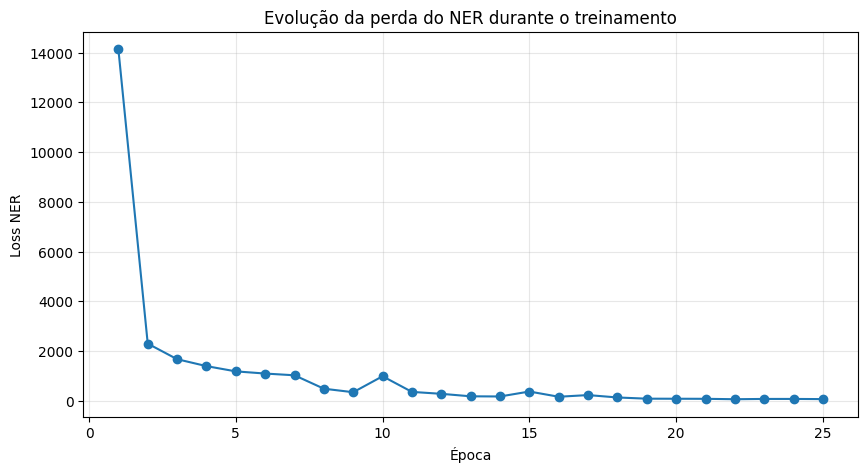

In [37]:
# ============================================================
# GRÁFICO DA PERDA DO TREINAMENTO DO NER
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_historico_treinamento_ner_v2["epoch"],
    df_historico_treinamento_ner_v2["loss_ner"],
    marker="o"
)

plt.title("Evolução da perda do NER durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss NER")
plt.grid(True, alpha=0.3)

plt.show()

In [38]:
# ============================================================
# AVALIAÇÃO DO NER V2
# ============================================================

exemplos_validacao_v2 = []

for texto, anotacoes in DADOS_VALIDACAO_NER_V2:
    doc_predito = nlp_ner_v2(texto)

    exemplo = Example.from_dict(
        doc_predito,
        anotacoes
    )

    exemplos_validacao_v2.append(exemplo)

scorer_v2 = Scorer()

metricas_ner_v2 = scorer_v2.score(
    exemplos_validacao_v2
)

print("Métricas gerais do NER V2 na validação:")
print("Precisão:", round(metricas_ner_v2.get("ents_p", 0), 4))
print("Revocação:", round(metricas_ner_v2.get("ents_r", 0), 4))
print("F1-score:", round(metricas_ner_v2.get("ents_f", 0), 4))

metricas_por_label_v2 = metricas_ner_v2.get(
    "ents_per_type",
    {}
)

df_metricas_por_label_v2 = pd.DataFrame.from_dict(
    metricas_por_label_v2,
    orient="index"
).reset_index()

df_metricas_por_label_v2 = df_metricas_por_label_v2.rename(
    columns={
        "index": "label",
        "p": "precisao",
        "r": "revocacao",
        "f": "f1"
    }
)

print("\nMétricas por label — NER V2:")
display(df_metricas_por_label_v2)

Métricas gerais do NER V2 na validação:
Precisão: 0.9459
Revocação: 0.9091
F1-score: 0.9272

Métricas por label — NER V2:


,label,precisao,revocacao,f1
0,AREA_COMPUTACAO_DADOS,0.948718,0.948718,0.948718
1,AREA_ENGENHARIA_MATERIAIS,0.973684,0.740000,0.840909
2,AREA_ALIMENTOS_AGRO,1.000000,0.958333,0.978723
3,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,0.972973,0.972973,0.972973
4,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,0.936170,0.977778,0.956522
5,AREA_ENERGIA,1.000000,0.888889,0.941176
6,AREA_SAUDE_BIOTECNOLOGIA,0.642857,1.000000,0.782609


# 9. Aplicação do NER em toda a base

Após o treinamento, o modelo NER será aplicado em todos os textos da base filtrada.

O resultado será uma tabela chamada `df_entidades_v2`, contendo:

- índice do texto;
- título do projeto;
- entidade extraída;
- label prevista;
- posição inicial;
- posição final;
- texto completo.

Essa tabela será usada posteriormente para construir a representação híbrida e para interpretar os clusters.

In [39]:
# ============================================================
# FUNÇÃO PARA APLICAR O NER EM TODA A BASE
# ============================================================

def aplicar_ner_base_completa(df_base, modelo):
    """
    Aplica o modelo de NER em toda a base textual.

    Retorna uma tabela com as entidades extraídas.
    """

    registros = []

    for indice, linha in df_base.iterrows():
        texto = linha["texto"]

        doc = modelo(texto)

        for ent in doc.ents:
            registros.append({
                "indice_texto": indice,
                "titulo": linha["titulo"],
                "entidade": ent.text,
                "label": ent.label_,
                "inicio": ent.start_char,
                "fim": ent.end_char,
                "texto": texto
            })

    return pd.DataFrame(registros)

In [40]:
# ============================================================
# APLICAÇÃO DO NER V2 NA BASE FILTRADA
# ============================================================

df_entidades_v2 = aplicar_ner_base_completa(
    df_base=df_textos_filtrado,
    modelo=nlp_ner_v2
)

print("Quantidade total de entidades extraídas pelo NER V2:")
print(len(df_entidades_v2))

print("\nDistribuição de entidades extraídas por label:")
display(
    df_entidades_v2["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="quantidade")
)

print("\nAmostra de entidades extraídas pelo NER V2:")
display(df_entidades_v2.head(100))

Quantidade total de entidades extraídas pelo NER V2:
4659

Distribuição de entidades extraídas por label:


,label,quantidade
0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,1536
1,AREA_COMPUTACAO_DADOS,1195
2,AREA_ENGENHARIA_MATERIAIS,530
3,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,512
4,AREA_ALIMENTOS_AGRO,333
5,AREA_ENERGIA,318
6,AREA_SAUDE_BIOTECNOLOGIA,235



Amostra de entidades extraídas pelo NER V2:


,indice_texto,titulo,entidade,label,inicio,fim,texto
0,0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,sustentável,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,200,211,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
1,0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,Sustentável,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,374,385,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
2,0,Açúcar de frutas e aplicação em bolos como substituto da sacarose,alimentos,AREA_ALIMENTOS_AGRO,697,706,Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indúst...
3,1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,castanhas,AREA_ALIMENTOS_AGRO,37,46,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...
4,1,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal,sustentável,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,745,756,Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológi...
...,...,...,...,...,...,...,...
95,21,AGROSYSTEM,eficiência energética,AREA_ENERGIA,1114,1135,"AGROSYSTEM. A Agrosystem concentra seus esforços no desenvolvimento de maquinário agrícola de precisão, destacando-s..."
96,22,HUAWEI - PV generation with optimal BESS based on AI,Inteligência Artificial,AREA_COMPUTACAO_DADOS,241,264,HUAWEI - PV generation with optimal BESS based on AI. Executar atividades de pesquisa e desenvolvimento de uma soluç...
97,23,HUAWEI SOLAR TRACKING CONTROL (AI BASED),Inteligência Artificial,AREA_COMPUTACAO_DADOS,120,143,HUAWEI SOLAR TRACKING CONTROL (AI BASED). O Objetivo deste projeto consiste no desenvolvimento de um sistema baseado...
98,24,Siemens-Energy,equipamento,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,267,278,"Siemens-Energy. Análise dos dados coletados na indústria, estruturação, organização e validação do banco de dados da..."


In [41]:
# ============================================================
# TESTE QUALITATIVO DO NER V2
# ============================================================

def aplicar_ner_em_amostra(df_base, modelo, n=12, random_state=42):
    """
    Aplica o modelo de NER em uma amostra aleatória de textos.
    """

    amostra = df_base.sample(
        n=min(n, len(df_base)),
        random_state=random_state
    )

    registros = []

    for indice, linha in amostra.iterrows():
        texto = linha["texto"]

        doc = modelo(texto)

        entidades = [
            {
                "entidade": ent.text,
                "label": ent.label_,
                "inicio": ent.start_char,
                "fim": ent.end_char
            }
            for ent in doc.ents
        ]

        registros.append({
            "indice_texto": indice,
            "titulo": linha["titulo"],
            "texto": texto,
            "entidades_extraidas": entidades,
            "qtd_entidades": len(entidades)
        })

    return pd.DataFrame(registros)


df_teste_qualitativo_ner_v2 = aplicar_ner_em_amostra(
    df_base=df_textos_filtrado,
    modelo=nlp_ner_v2,
    n=12,
    random_state=RANDOM_STATE
)

display(df_teste_qualitativo_ner_v2)

,indice_texto,titulo,texto,entidades_extraidas,qtd_entidades
0,945,Jiga de testes automatizados para garantir a qualidade dos acessórios para redes ópticas,Jiga de testes automatizados para garantir a qualidade dos acessórios para redes ópticas. Desenvolvimento de uma Jig...,"[{'entidade': 'dispositivos', 'label': 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO', 'inicio': 297, 'fim': 309}]",1
1,1576,PFood - Sistema Inteligente de Gestão e Logística Alimentícia,PFood - Sistema Inteligente de Gestão e Logística Alimentícia. O projeto tem como objetivo o desenvolvimento de uma ...,[],0
2,1405,LORA FUOTA REVOLUTION - UMA SOLUÇÃO DE ATUALIZAÇÃO RÁPIDA DE FIRMWARE UTILIZANDO LORA E LORAWAN EM APLICAÇÕES IOT,LORA FUOTA REVOLUTION - UMA SOLUÇÃO DE ATUALIZAÇÃO RÁPIDA DE FIRMWARE UTILIZANDO LORA E LORAWAN EM APLICAÇÕES IOT. D...,[],0
3,1260,SLOPE BREAK : METODOLOGIA DE CÁLCULO DA PROJEÇÃO E ALCANCE RUPTURAS EM TALUDES,SLOPE BREAK : METODOLOGIA DE CÁLCULO DA PROJEÇÃO E ALCANCE RUPTURAS EM TALUDES. A ruptura de taludes gera grandes pr...,[],0
4,2297,Desenvolvimento de Revestimento Inteligente Hidrofóbico para Aplicação em Painéis Fotovoltaicos,Desenvolvimento de Revestimento Inteligente Hidrofóbico para Aplicação em Painéis Fotovoltaicos. O objetivo deste pr...,"[{'entidade': 'manutenção', 'label': 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO', 'inicio': 401, 'fim': 411}, {'entidade...",2
5,572,Conectah  Jornada do Paciente com Hemofilia na estadual do Ceará,Conectah  Jornada do Paciente com Hemofilia na estadual do Ceará. O projeto prevê o desenvolvimento de uma solução ...,"[{'entidade': 'nuvem', 'label': 'AREA_COMPUTACAO_DADOS', 'inicio': 133, 'fim': 138}]",1
6,2184,Pesquisa sobre Desempenho Termodinâmico de Compressores Herméticos de Refrigeração,Pesquisa sobre Desempenho Termodinâmico de Compressores Herméticos de Refrigeração. Análise do Desempenho de Compres...,[],0
7,1569,"Desenvolvimento de sistema de controle, automação e configuração de um rastreador solar fotovoltaico","Desenvolvimento de sistema de controle, automação e configuração de um rastreador solar fotovoltaico. O Projeto tem ...","[{'entidade': 'sistema de controle', 'label': 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO', 'inicio': 19, 'fim': 38}, {'e...",4
8,1992,Desenvolvimento de Tecnologias de Informática Abrangendo Atividades de Pesquisa e Desenvolvimento na Área de Eletrôn...,Desenvolvimento de Tecnologias de Informática Abrangendo Atividades de Pesquisa e Desenvolvimento na Área de Eletrôn...,[],0
9,2001,Filtro Ativo para Redes Elétricas,Filtro Ativo para Redes Elétricas. Desenvolvimento (software e hardware) de filtro ativo para redes elétricas,"[{'entidade': 'software', 'label': 'AREA_COMPUTACAO_DADOS', 'inicio': 52, 'fim': 60}, {'entidade': 'hardware', 'labe...",2


## Cobertura do NER na base

Antes de usar as entidades na representação híbrida, vamos medir a cobertura do NER.

Essa análise mostra:

- quantos textos receberam pelo menos uma entidade;
- quantos textos não receberam nenhuma entidade;
- a média de entidades por texto.

Essa informação será importante para interpretar limitações da clusterização final.

In [42]:
# ============================================================
# COBERTURA DO NER V2 NA BASE
# ============================================================

qtd_entidades_por_texto_v2 = (
    df_entidades_v2
    .groupby("indice_texto")
    .size()
    .rename("qtd_entidades_ner_v2")
)

df_textos_filtrado["qtd_entidades_ner_v2"] = df_textos_filtrado.index.map(
    qtd_entidades_por_texto_v2
).fillna(0).astype(int)

df_textos_filtrado["possui_entidade_ner_v2"] = (
    df_textos_filtrado["qtd_entidades_ner_v2"] > 0
)

qtd_textos_com_ner = int(
    df_textos_filtrado["possui_entidade_ner_v2"].sum()
)

qtd_textos_sem_ner = len(df_textos_filtrado) - qtd_textos_com_ner

print("Quantidade de textos na base filtrada:")
print(len(df_textos_filtrado))

print("\nTextos com pelo menos uma entidade NER:")
print(qtd_textos_com_ner)

print("\nTextos sem entidades NER:")
print(qtd_textos_sem_ner)

print("\nPercentual de textos com entidades NER:")
print(f"{qtd_textos_com_ner / len(df_textos_filtrado) * 100:.2f}%")

print("\nMédia de entidades por texto:")
print(df_textos_filtrado["qtd_entidades_ner_v2"].mean())

Quantidade de textos na base filtrada:
2702

Textos com pelo menos uma entidade NER:
1747

Textos sem entidades NER:
955

Percentual de textos com entidades NER:
64.66%

Média de entidades por texto:
1.724278312361214


In [43]:
# ============================================================
# SALVAMENTO DOS RESULTADOS DO NER
# ============================================================

modelo_ner_v2_dir = "/kaggle/working/modelo_ner_v2_projetos_cientificos"

os.makedirs(modelo_ner_v2_dir, exist_ok=True)

nlp_ner_v2.to_disk(modelo_ner_v2_dir)

df_labels_ner_treino_v2.to_csv(
    os.path.join(OUTPUT_DIR, "labels_ner_treino_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_entidades_candidatas_v2.to_csv(
    os.path.join(OUTPUT_DIR, "entidades_candidatas_ner_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_contagem_entidades_v2_ajustada.to_csv(
    os.path.join(OUTPUT_DIR, "distribuicao_training_data_ner_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_historico_treinamento_ner_v2.to_csv(
    os.path.join(OUTPUT_DIR, "historico_treinamento_ner_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_metricas_por_label_v2.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_ner_v2_por_label.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_entidades_v2.to_csv(
    os.path.join(OUTPUT_DIR, "entidades_extraidas_ner_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_textos_filtrado.to_csv(
    os.path.join(OUTPUT_DIR, "df_textos_filtrado_com_ner_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("Modelo NER V2 salvo em:")
print(modelo_ner_v2_dir)

print("\nArquivos salvos em:")
print(OUTPUT_DIR)

print("\nArquivos disponíveis:")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Modelo NER V2 salvo em:
/kaggle/working/modelo_ner_v2_projetos_cientificos

Arquivos salvos em:
/kaggle/working/resultados_parciais

Arquivos disponíveis:
- comparacao_tfidf_titulo.csv
- df_textos_filtrado_com_ner_v2.csv
- df_textos_filtrado_inicial.csv
- distribuicao_training_data_ner_v2.csv
- entidades_candidatas_ner_v2.csv
- entidades_extraidas_ner_v2.csv
- historico_treinamento_ner_v2.csv
- labels_ner_treino_v2.csv
- metricas_ner_v2_por_label.csv
- resumo_ruidos.csv
- termos_candidatos_ner.csv
- top_frequencias_termos.csv
- top_termos_tfidf_global.csv


# 10. Geração de embeddings com BERTimbau

Nesta etapa, vamos gerar embeddings semânticos para os textos dos projetos usando o BERTimbau.

O BERTimbau é um modelo baseado na arquitetura BERT treinado para a língua portuguesa. Diferentemente do TF-IDF, que representa textos a partir da frequência de palavras, o BERTimbau gera representações vetoriais contextuais.

Isso significa que o modelo considera o contexto em que as palavras aparecem.

Cada texto será transformado em um vetor numérico. Esses vetores serão usados posteriormente na clusterização.

Neste notebook, vamos gerar embeddings para três versões textuais:

1. `texto_original`

   Combina título e descrição uma única vez.

2. `texto_titulo_reforcado`

   Repete o título antes da descrição, dando maior peso ao resumo temático do projeto.

3. `texto_enriquecido_ner_v2`

   Combina o texto com entidades extraídas pelo modelo NER V2.

A comparação entre essas versões ajudará a verificar se o reforço do título e o uso do NER melhoram a separação temática dos projetos.

In [44]:
# ============================================================
# CARREGAMENTO DO BERTIMBAU
# ============================================================

NOME_MODELO_BERT = "neuralmind/bert-base-portuguese-cased"

tokenizer_bert = AutoTokenizer.from_pretrained(NOME_MODELO_BERT)
modelo_bert = AutoModel.from_pretrained(NOME_MODELO_BERT)

modelo_bert = modelo_bert.to(device)
modelo_bert.eval()

print("Modelo BERTimbau carregado:")
print(NOME_MODELO_BERT)

print("\nDispositivo usado:")
print(device)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Modelo BERTimbau carregado:
neuralmind/bert-base-portuguese-cased

Dispositivo usado:
cuda


## Análise da quantidade de tokens

Modelos baseados em BERT possuem um limite máximo de tokens por entrada.

Antes de gerar os embeddings, vamos verificar quantos tokens o BERTimbau gera para os textos da base.

Essa análise é importante porque o tokenizer do BERT pode dividir uma palavra em vários sub-tokens. Portanto, a quantidade de tokens pode ser maior do que a quantidade simples de palavras.

Com base nessa distribuição, será definido o valor de `MAX_LEN_BERT`, que controla o tamanho máximo dos textos enviados ao modelo.

In [45]:
# ============================================================
# ANÁLISE DO TAMANHO DOS TEXTOS EM TOKENS BERT
# ============================================================

def contar_tokens_bert(texto):
    """
    Conta a quantidade de tokens gerados pelo tokenizer do BERTimbau.
    """

    tokens = tokenizer_bert(
        str(texto),
        add_special_tokens=True,
        truncation=False
    )

    return len(tokens["input_ids"])


df_textos_filtrado["qtd_tokens_bert"] = df_textos_filtrado["texto"].apply(
    contar_tokens_bert
)

print("Estatísticas da quantidade de tokens BERT por texto:")
display(df_textos_filtrado["qtd_tokens_bert"].describe())

limites_tokens = [128, 256, 384, 512]

resumo_limites_tokens = []

for limite in limites_tokens:
    quantidade_acima = int(
        (df_textos_filtrado["qtd_tokens_bert"] > limite).sum()
    )

    percentual_acima = quantidade_acima / len(df_textos_filtrado) * 100

    resumo_limites_tokens.append({
        "limite_tokens": limite,
        "qtd_textos_acima_do_limite": quantidade_acima,
        "percentual_acima_do_limite": round(percentual_acima, 2)
    })

df_resumo_limites_tokens = pd.DataFrame(
    resumo_limites_tokens
)

print("\nQuantidade de textos acima de cada limite:")
display(df_resumo_limites_tokens)

Estatísticas da quantidade de tokens BERT por texto:


count    2702.000000
mean       91.890081
std        86.187672
min        10.000000
25%        39.000000
50%        63.000000
75%       112.750000
max       769.000000
Name: qtd_tokens_bert, dtype: float64


Quantidade de textos acima de cada limite:


,limite_tokens,qtd_textos_acima_do_limite,percentual_acima_do_limite
0,128,558,20.65
1,256,147,5.44
2,384,45,1.67
3,512,16,0.59


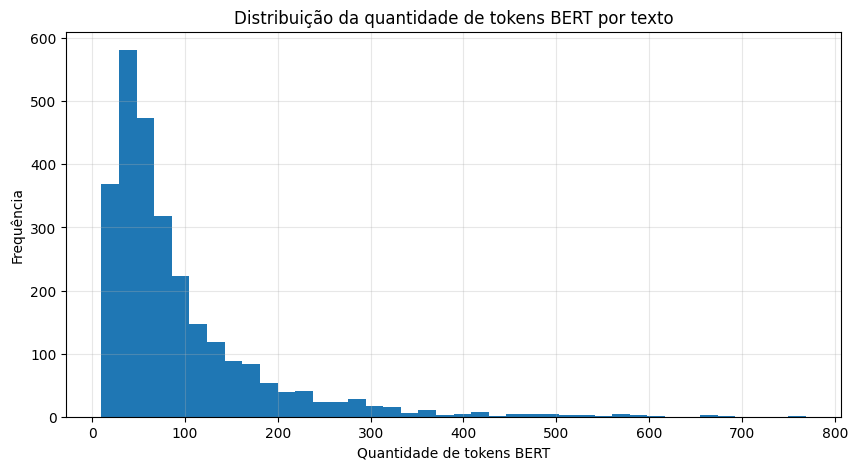

In [46]:
# ============================================================
# VISUALIZAÇÃO DA DISTRIBUIÇÃO DE TOKENS
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df_textos_filtrado["qtd_tokens_bert"],
    bins=40
)

plt.title("Distribuição da quantidade de tokens BERT por texto")
plt.xlabel("Quantidade de tokens BERT")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)

plt.show()

## Definição do limite de tokens

Para gerar embeddings, precisamos definir um tamanho máximo de tokens.

Neste notebook, será usado:

MAX_LEN_BERT = 256

In [47]:

# ============================================================
# CONFIGURAÇÃO DE EMBEDDINGS
# ============================================================

MAX_LEN_BERT = 256

BATCH_SIZE_BERT = 16 if device.type == "cuda" else 4

print("MAX_LEN_BERT:", MAX_LEN_BERT)
print("BATCH_SIZE_BERT:", BATCH_SIZE_BERT)

MAX_LEN_BERT: 256
BATCH_SIZE_BERT: 16


## Mean pooling

O BERT retorna um embedding para cada token do texto.

Para representar cada projeto com um único vetor, será usada a técnica de `mean pooling`.

O mean pooling calcula a média dos embeddings dos tokens válidos do texto, ignorando tokens de padding.

Assim, cada projeto passa a ser representado por um vetor de 768 dimensões.

In [48]:
# ============================================================
# FUNÇÃO DE MEAN POOLING
# ============================================================

def mean_pooling(saida_modelo, attention_mask):
    """
    Calcula o mean pooling dos embeddings dos tokens.

    O BERT retorna embeddings para cada token.
    Esta função calcula a média dos embeddings dos tokens válidos,
    ignorando tokens de padding.
    """

    token_embeddings = saida_modelo.last_hidden_state

    mascara_expandida = attention_mask.unsqueeze(-1).expand(
        token_embeddings.size()
    ).float()

    soma_embeddings = torch.sum(
        token_embeddings * mascara_expandida,
        dim=1
    )

    soma_mascara = torch.clamp(
        mascara_expandida.sum(dim=1),
        min=1e-9
    )

    embeddings = soma_embeddings / soma_mascara

    return embeddings

In [49]:
# ============================================================
# FUNÇÃO PARA GERAR EMBEDDINGS COM BERTIMBAU
# ============================================================

def gerar_embeddings_bertimbau(
    textos,
    tokenizer,
    modelo,
    batch_size=16,
    max_len=256
):
    """
    Gera embeddings para uma lista de textos usando BERTimbau.

    Parâmetros
    ----------
    textos:
        Lista de textos.

    tokenizer:
        Tokenizer do modelo BERTimbau.

    modelo:
        Modelo BERTimbau.

    batch_size:
        Tamanho do lote de processamento.

    max_len:
        Quantidade máxima de tokens por texto.

    Retorno
    -------
    np.ndarray
        Matriz de embeddings com uma linha por texto.
    """

    todos_embeddings = []

    for inicio in tqdm(range(0, len(textos), batch_size)):
        fim = inicio + batch_size

        lote_textos = textos[inicio:fim]

        entradas = tokenizer(
            lote_textos,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        entradas = {
            chave: valor.to(device)
            for chave, valor in entradas.items()
        }

        with torch.no_grad():
            saida_modelo = modelo(**entradas)

        embeddings_lote = mean_pooling(
            saida_modelo=saida_modelo,
            attention_mask=entradas["attention_mask"]
        )

        todos_embeddings.append(
            embeddings_lote.cpu().numpy()
        )

    matriz_embeddings = np.vstack(
        todos_embeddings
    )

    return matriz_embeddings

# 11. Texto enriquecido com entidades NER

Além do texto original e do texto com título reforçado, vamos criar uma terceira representação textual.

Essa representação será chamada de `texto_enriquecido_ner_v2`.

Ela combina:

- título reforçado;
- descrição;
- entidades extraídas pelo NER V2;
- labels temáticas previstas pelo NER.

A ideia é verificar se o acréscimo das entidades ajuda a destacar temas importantes dos projetos.

Essa representação não substitui o texto original. Ela será usada apenas como uma das alternativas comparadas na clusterização.

In [50]:
# ============================================================
# CRIAÇÃO DO TEXTO ENRIQUECIDO COM NER V2
# ============================================================

entidades_por_indice_v2 = (
    df_entidades_v2
    .groupby("indice_texto")
    .apply(
        lambda grupo: " ".join(
            sorted(
                set(
                    list(grupo["label"].astype(str))
                    + list(grupo["entidade"].astype(str))
                )
            )
        )
    )
    .to_dict()
)


def criar_texto_enriquecido_ner_v2(linha):
    """
    Cria uma versão textual enriquecida com entidades extraídas pelo NER V2.
    """

    indice = linha.name

    entidades = entidades_por_indice_v2.get(
        indice,
        ""
    )

    texto_enriquecido = (
        str(linha["texto_titulo_reforcado"])
        + " ENTIDADES_TEMATICAS: "
        + entidades
    )

    return texto_enriquecido


df_textos_filtrado["texto_enriquecido_ner_v2"] = df_textos_filtrado.apply(
    criar_texto_enriquecido_ner_v2,
    axis=1
)

print("Exemplo de texto original:")
print(df_textos_filtrado["texto_original"].iloc[0][:700])

print("\nExemplo de texto com título reforçado:")
print(df_textos_filtrado["texto_titulo_reforcado"].iloc[0][:700])

print("\nExemplo de texto enriquecido com NER V2:")
print(df_textos_filtrado["texto_enriquecido_ner_v2"].iloc[0][:900])

Exemplo de texto original:
Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contribui para os Objetivos de Desenvolvimento Sustentável (ODS) estabelecidos pela Organização das Nações Unidas (ONU) especialmente no âmbito do Objetivo 12 (Assegurar padrões de produção e de consumo sustentáveis). Diante desse cenário, a presenta proposta buscará desenvolver e produzir frutose em pó que substitua a sacarose para atender o mercado de indústrias de ali

Exemplo de texto com título reforçado:
Açúcar de frutas e aplicação em bolos como substituto da sacarose. Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de prod

# 12. Geração dos embeddings das representações textuais

Agora serão gerados embeddings para três representações:

1. `texto_original`;
2. `texto_titulo_reforcado`;
3. `texto_enriquecido_ner_v2`.

A comparação entre essas representações é importante porque permite verificar empiricamente se o título reforçado e as entidades NER ajudam ou não na clusterização.

Os embeddings serão armazenados em variáveis separadas para uso posterior.

In [51]:
# ============================================================
# GERAÇÃO DOS EMBEDDINGS — TEXTO ORIGINAL
# ============================================================

textos_original = df_textos_filtrado["texto_original"].tolist()

embeddings_texto_original = gerar_embeddings_bertimbau(
    textos=textos_original,
    tokenizer=tokenizer_bert,
    modelo=modelo_bert,
    batch_size=BATCH_SIZE_BERT,
    max_len=MAX_LEN_BERT
)

print("Formato dos embeddings do texto original:")
print(embeddings_texto_original.shape)

  0%|          | 0/169 [00:00<?, ?it/s]

Formato dos embeddings do texto original:
(2702, 768)


In [52]:
# ============================================================
# GERAÇÃO DOS EMBEDDINGS — TÍTULO REFORÇADO
# ============================================================

textos_titulo_reforcado = df_textos_filtrado["texto_titulo_reforcado"].tolist()

embeddings_titulo_reforcado = gerar_embeddings_bertimbau(
    textos=textos_titulo_reforcado,
    tokenizer=tokenizer_bert,
    modelo=modelo_bert,
    batch_size=BATCH_SIZE_BERT,
    max_len=MAX_LEN_BERT
)

print("Formato dos embeddings do texto com título reforçado:")
print(embeddings_titulo_reforcado.shape)

  0%|          | 0/169 [00:00<?, ?it/s]

Formato dos embeddings do texto com título reforçado:
(2702, 768)


In [53]:
# ============================================================
# GERAÇÃO DOS EMBEDDINGS — TEXTO ENRIQUECIDO COM NER V2
# ============================================================

textos_enriquecidos_ner_v2 = df_textos_filtrado["texto_enriquecido_ner_v2"].tolist()

embeddings_enriquecido_ner_v2 = gerar_embeddings_bertimbau(
    textos=textos_enriquecidos_ner_v2,
    tokenizer=tokenizer_bert,
    modelo=modelo_bert,
    batch_size=BATCH_SIZE_BERT,
    max_len=MAX_LEN_BERT
)

print("Formato dos embeddings do texto enriquecido com NER V2:")
print(embeddings_enriquecido_ner_v2.shape)

  0%|          | 0/169 [00:00<?, ?it/s]

Formato dos embeddings do texto enriquecido com NER V2:
(2702, 768)


In [54]:
# ============================================================
# VERIFICAÇÃO DOS EMBEDDINGS
# ============================================================

representacoes_embeddings = {
    "texto_original": embeddings_texto_original,
    "texto_titulo_reforcado": embeddings_titulo_reforcado,
    "texto_enriquecido_ner_v2": embeddings_enriquecido_ner_v2
}

for nome, matriz in representacoes_embeddings.items():
    print("=" * 80)
    print(nome)
    print("Formato:", matriz.shape)
    print("Há NaN?", np.isnan(matriz).any())
    print("Há infinito?", np.isinf(matriz).any())

texto_original
Formato: (2702, 768)
Há NaN? False
Há infinito? False
texto_titulo_reforcado
Formato: (2702, 768)
Há NaN? False
Há infinito? False
texto_enriquecido_ner_v2
Formato: (2702, 768)
Há NaN? False
Há infinito? False


# 13. Comparação inicial das representações com KMeans

Antes de construir a representação híbrida final, vamos comparar as três representações textuais baseadas em BERTimbau.

Para cada representação, será feito:

1. normalização dos embeddings;
2. redução para 50 dimensões com PCA;
3. aplicação do KMeans com diferentes valores de `k`;
4. cálculo do Silhouette Score;
5. análise do tamanho dos clusters.

Essa comparação ajuda a responder duas perguntas:

- repetir o título melhora a clusterização?
- enriquecer o texto com entidades NER melhora a separação temática?

O resultado dessa etapa não será necessariamente a clusterização final. Ele será usado como comparação para a representação híbrida.

In [55]:
# ============================================================
# FUNÇÃO PARA AVALIAR REPRESENTAÇÕES COM PCA + KMEANS
# ============================================================

def avaliar_representacao_kmeans(
    embeddings,
    nome_representacao,
    valores_k=range(2, 13),
    n_componentes_pca=50,
    random_state=42
):
    """
    Avalia uma representação textual com PCA + KMeans para vários valores de k.
    """

    embeddings_norm = normalize(
        embeddings,
        norm="l2"
    )

    n_componentes = min(
        n_componentes_pca,
        embeddings_norm.shape[1]
    )

    pca_cluster = PCA(
        n_components=n_componentes,
        random_state=random_state
    )

    embeddings_pca_cluster = pca_cluster.fit_transform(
        embeddings_norm
    )

    resultados = []

    for k in valores_k:
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=30
        )

        labels = kmeans.fit_predict(
            embeddings_pca_cluster
        )

        silhouette = silhouette_score(
            embeddings_pca_cluster,
            labels,
            metric="euclidean"
        )

        contagem = pd.Series(labels).value_counts()

        resultados.append({
            "representacao": nome_representacao,
            "k": k,
            "silhouette_score": silhouette,
            "inertia": kmeans.inertia_,
            "menor_cluster": int(contagem.min()),
            "maior_cluster": int(contagem.max()),
            "percentual_menor_cluster": round(contagem.min() / len(labels) * 100, 2),
            "percentual_maior_cluster": round(contagem.max() / len(labels) * 100, 2),
            "variancia_pca_50": pca_cluster.explained_variance_ratio_.sum()
        })

    return pd.DataFrame(resultados)

In [56]:
# ============================================================
# AVALIAÇÃO DAS TRÊS REPRESENTAÇÕES TEXTUAIS
# ============================================================

resultados_comparacao = []

for nome, matriz in representacoes_embeddings.items():
    print(f"Avaliando representação: {nome}")

    df_resultado_temp = avaliar_representacao_kmeans(
        embeddings=matriz,
        nome_representacao=nome,
        valores_k=range(2, 13),
        n_componentes_pca=50,
        random_state=RANDOM_STATE
    )

    resultados_comparacao.append(
        df_resultado_temp
    )

df_comparacao_representacoes = pd.concat(
    resultados_comparacao,
    ignore_index=True
)

print("Comparação geral entre representações:")
display(
    df_comparacao_representacoes.sort_values(
        by=["representacao", "k"]
    )
)

Avaliando representação: texto_original
Avaliando representação: texto_titulo_reforcado
Avaliando representação: texto_enriquecido_ner_v2
Comparação geral entre representações:


,representacao,k,silhouette_score,inertia,menor_cluster,maior_cluster,percentual_menor_cluster,percentual_maior_cluster,variancia_pca_50
22,texto_enriquecido_ner_v2,2,0.118696,361.972382,1320,1382,48.85,51.15,0.731497
23,texto_enriquecido_ner_v2,3,0.111790,337.822815,697,1061,25.80,39.27,0.731497
24,texto_enriquecido_ner_v2,4,0.112144,321.759583,188,1008,6.96,37.31,0.731497
25,texto_enriquecido_ner_v2,5,0.102857,307.070923,188,749,6.96,27.72,0.731497
26,texto_enriquecido_ner_v2,6,0.088191,296.262817,184,650,6.81,24.06,0.731497
27,texto_enriquecido_ner_v2,7,0.092940,287.699127,48,642,1.78,23.76,0.731497
28,texto_enriquecido_ner_v2,8,0.098450,279.516052,48,614,1.78,22.72,0.731497
29,texto_enriquecido_ner_v2,9,0.102008,272.786987,48,562,1.78,20.80,0.731497
30,texto_enriquecido_ner_v2,10,0.086028,267.194794,48,406,1.78,15.03,0.731497
31,texto_enriquecido_ner_v2,11,0.089968,261.793091,48,392,1.78,14.51,0.731497


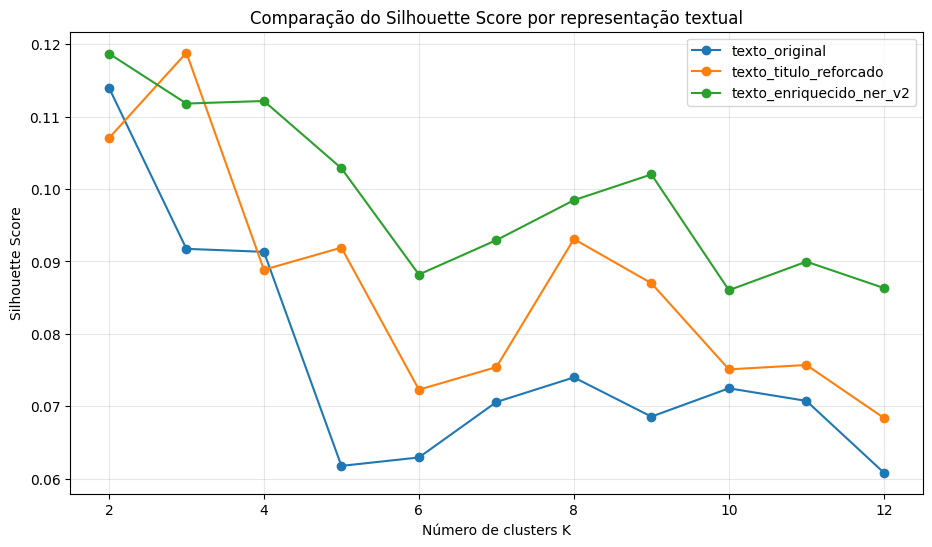

In [57]:
# ============================================================
# GRÁFICO DE SILHOUETTE POR REPRESENTAÇÃO
# ============================================================

plt.figure(figsize=(11, 6))

for nome in df_comparacao_representacoes["representacao"].unique():
    dados = df_comparacao_representacoes[
        df_comparacao_representacoes["representacao"] == nome
    ]

    plt.plot(
        dados["k"],
        dados["silhouette_score"],
        marker="o",
        label=nome
    )

plt.title("Comparação do Silhouette Score por representação textual")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [58]:
# ============================================================
# CANDIDATOS INTERPRETÁVEIS ENTRE AS REPRESENTAÇÕES
# ============================================================

df_candidatos_representacoes = df_comparacao_representacoes[
    (df_comparacao_representacoes["k"] >= 4)
    & (df_comparacao_representacoes["percentual_menor_cluster"] >= 2.0)
].sort_values(
    by="silhouette_score",
    ascending=False
)

print("Candidatos interpretáveis entre as representações BERTimbau:")
display(df_candidatos_representacoes.head(20))

Candidatos interpretáveis entre as representações BERTimbau:


,representacao,k,silhouette_score,inertia,menor_cluster,maior_cluster,percentual_menor_cluster,percentual_maior_cluster,variancia_pca_50
24,texto_enriquecido_ner_v2,4,0.112144,321.759583,188,1008,6.96,37.31,0.731497
25,texto_enriquecido_ner_v2,5,0.102857,307.070923,188,749,6.96,27.72,0.731497
14,texto_titulo_reforcado,5,0.091904,384.889557,218,841,8.07,31.13,0.700730
2,texto_original,4,0.091324,419.095276,222,986,8.22,36.49,0.705666
13,texto_titulo_reforcado,4,0.088851,400.914978,219,963,8.11,35.64,0.700730
26,texto_enriquecido_ner_v2,6,0.088191,296.262817,184,650,6.81,24.06,0.731497
15,texto_titulo_reforcado,6,0.072299,373.487183,213,706,7.88,26.13,0.700730
4,texto_original,6,0.062939,391.640625,169,665,6.25,24.61,0.705666
3,texto_original,5,0.061777,404.539307,169,747,6.25,27.65,0.705666


## Interpretação da comparação inicial

Essa comparação permite avaliar o impacto das representações textuais.

Em geral, valores maiores de Silhouette indicam maior separação entre os clusters. No entanto, a escolha final não deve depender apenas dessa métrica.

Um valor de `k = 2` pode apresentar bom Silhouette, mas produzir uma divisão muito ampla e pouco informativa. Para análise temática, clusters mais interpretáveis podem ser preferíveis mesmo com Silhouette ligeiramente menor.

A comparação desta etapa será usada como referência para a clusterização híbrida final.

In [59]:
# ============================================================
# SALVAMENTO DOS EMBEDDINGS E DA COMPARAÇÃO
# ============================================================

np.save(
    os.path.join(OUTPUT_DIR, "embeddings_texto_original.npy"),
    embeddings_texto_original
)

np.save(
    os.path.join(OUTPUT_DIR, "embeddings_titulo_reforcado.npy"),
    embeddings_titulo_reforcado
)

np.save(
    os.path.join(OUTPUT_DIR, "embeddings_enriquecido_ner_v2.npy"),
    embeddings_enriquecido_ner_v2
)

df_resumo_limites_tokens.to_csv(
    os.path.join(OUTPUT_DIR, "resumo_limites_tokens_bert.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_comparacao_representacoes.to_csv(
    os.path.join(OUTPUT_DIR, "comparacao_representacoes_bertimbau.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_candidatos_representacoes.to_csv(
    os.path.join(OUTPUT_DIR, "candidatos_representacoes_bertimbau.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_textos_filtrado.to_csv(
    os.path.join(OUTPUT_DIR, "df_textos_filtrado_com_embeddings_info.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("Embeddings e comparações salvos em:")
print(OUTPUT_DIR)

print("\nArquivos disponíveis:")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Embeddings e comparações salvos em:
/kaggle/working/resultados_parciais

Arquivos disponíveis:
- candidatos_representacoes_bertimbau.csv
- comparacao_representacoes_bertimbau.csv
- comparacao_tfidf_titulo.csv
- df_textos_filtrado_com_embeddings_info.csv
- df_textos_filtrado_com_ner_v2.csv
- df_textos_filtrado_inicial.csv
- distribuicao_training_data_ner_v2.csv
- embeddings_enriquecido_ner_v2.npy
- embeddings_texto_original.npy
- embeddings_titulo_reforcado.npy
- entidades_candidatas_ner_v2.csv
- entidades_extraidas_ner_v2.csv
- historico_treinamento_ner_v2.csv
- labels_ner_treino_v2.csv
- metricas_ner_v2_por_label.csv
- resumo_limites_tokens_bert.csv
- resumo_ruidos.csv
- termos_candidatos_ner.csv
- top_frequencias_termos.csv
- top_termos_tfidf_global.csv


# 14. Representação híbrida final

A clusterização baseada apenas em embeddings BERTimbau captura relações semânticas gerais entre os textos, mas pode deixar de destacar termos específicos importantes do domínio.

Por outro lado, o TF-IDF destaca termos relevantes, mas não captura bem o contexto semântico das frases.

O NER personalizado identifica entidades temáticas, mas depende da cobertura das labels e do conjunto de treinamento criado.

Por isso, a representação final deste notebook será híbrida, combinando três fontes de informação:

1. **BERTimbau com título reforçado**

   Captura o sentido geral dos textos em português, dando maior peso ao título do projeto.

2. **TF-IDF com redução por SVD**

   Preserva termos técnicos importantes do domínio, como `software`, `energia`, `resíduos`, `baterias`, `aço`, `fertilizantes`, `saúde`, entre outros.

3. **Features do NER V2**

   Indicam quais áreas temáticas foram reconhecidas em cada projeto.

A hipótese é que essa combinação gere clusters mais interpretáveis do que usar apenas uma representação textual.

In [60]:
# ============================================================
# BLOCO 1 — FEATURES BERTIMBAU COM TÍTULO REFORÇADO
# ============================================================

# Usamos os embeddings do texto com título reforçado porque o título
# costuma resumir o tema principal do projeto.

embeddings_bert_hibrido_base = normalize(
    embeddings_titulo_reforcado,
    norm="l2"
)

pca_bert_hibrido = PCA(
    n_components=50,
    random_state=RANDOM_STATE
)

features_bert_hibrido = pca_bert_hibrido.fit_transform(
    embeddings_bert_hibrido_base
)

print("Features BERT/PCA:")
print(features_bert_hibrido.shape)

print("\nVariância explicada pelo PCA do BERT:")
print(pca_bert_hibrido.explained_variance_ratio_.sum())

Features BERT/PCA:
(2702, 50)

Variância explicada pelo PCA do BERT:
0.7007303


In [61]:
# ============================================================
# BLOCO 2 — FEATURES TF-IDF + SVD
# ============================================================

vectorizer_tfidf_hibrido = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stopwords_portugues_refinadas,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.75,
    max_features=5000
)

matriz_tfidf_hibrido = vectorizer_tfidf_hibrido.fit_transform(
    df_textos_filtrado["texto_titulo_reforcado"].tolist()
)

n_componentes_svd = min(
    50,
    matriz_tfidf_hibrido.shape[1] - 1
)

svd_tfidf_hibrido = TruncatedSVD(
    n_components=n_componentes_svd,
    random_state=RANDOM_STATE
)

features_tfidf_hibrido = svd_tfidf_hibrido.fit_transform(
    matriz_tfidf_hibrido
)

print("Features TF-IDF/SVD:")
print(features_tfidf_hibrido.shape)

print("\nVariância explicada pelo SVD do TF-IDF:")
print(svd_tfidf_hibrido.explained_variance_ratio_.sum())

Features TF-IDF/SVD:
(2702, 50)

Variância explicada pelo SVD do TF-IDF:
0.1599537500537294


In [62]:
# ============================================================
# BLOCO 3 — FEATURES DO NER V2
# ============================================================

labels_ner_v2_ordenadas = sorted(
    df_entidades_v2["label"].unique()
)

df_ner_counts_v2 = (
    df_entidades_v2
    .groupby(["indice_texto", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=df_textos_filtrado.index,
        columns=labels_ner_v2_ordenadas,
        fill_value=0
    )
)

# Proporção de entidades por label no texto.
soma_entidades_por_texto_v2 = df_ner_counts_v2.sum(axis=1).replace(0, 1)

df_ner_prop_v2 = df_ner_counts_v2.div(
    soma_entidades_por_texto_v2,
    axis=0
)

# Presença ou ausência de cada label no texto.
df_ner_bin_v2 = (
    df_ner_counts_v2 > 0
).astype(int)

features_ner_hibrido_final = np.hstack([
    df_ner_prop_v2.values,
    df_ner_bin_v2.values
])

print("Features NER V2:")
print(features_ner_hibrido_final.shape)

print("\nLabels NER V2 usadas nas features:")
print(labels_ner_v2_ordenadas)

print("\nAmostra da matriz de contagem de entidades:")
display(df_ner_counts_v2.head())

Features NER V2:
(2702, 14)

Labels NER V2 usadas nas features:
['AREA_ALIMENTOS_AGRO', 'AREA_COMPUTACAO_DADOS', 'AREA_ENERGIA', 'AREA_ENGENHARIA_MATERIAIS', 'AREA_MEIO_AMBIENTE_SUSTENTABILIDADE', 'AREA_SAUDE_BIOTECNOLOGIA', 'AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO']

Amostra da matriz de contagem de entidades:


label,AREA_ALIMENTOS_AGRO,AREA_COMPUTACAO_DADOS,AREA_ENERGIA,AREA_ENGENHARIA_MATERIAIS,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,AREA_SAUDE_BIOTECNOLOGIA,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO
0,1,0,0,0,2,0,0
1,3,0,0,0,1,0,0
2,1,0,0,0,2,0,0
3,0,0,0,0,1,0,0
4,3,0,0,0,2,0,0


## Combinação das features

Os três blocos de features possuem escalas diferentes. Por isso, antes de combiná-los, será aplicada padronização com `StandardScaler`.

Depois, cada bloco receberá um peso:

- BERTimbau: peso `1.0`;
- TF-IDF/SVD: peso `0.8`;
- NER V2: peso `1.3`.

O NER recebe um peso um pouco maior porque queremos reforçar os sinais temáticos extraídos das entidades.

Após a combinação, a matriz final será normalizada com norma L2.

In [63]:
# ============================================================
# PADRONIZAÇÃO E COMBINAÇÃO DAS FEATURES HÍBRIDAS FINAIS
# ============================================================

scaler_bert_final = StandardScaler()
scaler_tfidf_final = StandardScaler()
scaler_ner_final = StandardScaler()

features_bert_scaled_final = scaler_bert_final.fit_transform(
    features_bert_hibrido
)

features_tfidf_scaled_final = scaler_tfidf_final.fit_transform(
    features_tfidf_hibrido
)

features_ner_scaled_final = scaler_ner_final.fit_transform(
    features_ner_hibrido_final
)

PESO_BERT_FINAL = 1.0
PESO_TFIDF_FINAL = 0.8
PESO_NER_FINAL = 1.3

features_hibridas_final = np.hstack([
    features_bert_scaled_final * PESO_BERT_FINAL,
    features_tfidf_scaled_final * PESO_TFIDF_FINAL,
    features_ner_scaled_final * PESO_NER_FINAL
])

features_hibridas_final_norm = normalize(
    features_hibridas_final,
    norm="l2"
)

print("Formato final das features híbridas finais:")
print(features_hibridas_final_norm.shape)

print("\nPesos usados:")
print("PESO_BERT_FINAL:", PESO_BERT_FINAL)
print("PESO_TFIDF_FINAL:", PESO_TFIDF_FINAL)
print("PESO_NER_FINAL:", PESO_NER_FINAL)

print("\nHá valores NaN?")
print(np.isnan(features_hibridas_final_norm).any())

print("\nHá valores infinitos?")
print(np.isinf(features_hibridas_final_norm).any())

Formato final das features híbridas finais:
(2702, 114)

Pesos usados:
PESO_BERT_FINAL: 1.0
PESO_TFIDF_FINAL: 0.8
PESO_NER_FINAL: 1.3

Há valores NaN?
False

Há valores infinitos?
False


# 15. Clusterização com KMeans

Com a representação híbrida final criada, vamos aplicar KMeans para diferentes valores de `k`.

O objetivo é encontrar uma quantidade de clusters que tenha bom equilíbrio entre:

- Silhouette Score;
- tamanho razoável dos clusters;
- interpretabilidade temática;
- coerência com os termos TF-IDF;
- coerência com as entidades NER.

A escolha final não será baseada apenas no maior Silhouette Score. Como o objetivo do projeto é interpretar áreas temáticas, a interpretabilidade dos clusters também será considerada.

In [64]:
# ============================================================
# AVALIAÇÃO DO KMEANS NA REPRESENTAÇÃO HÍBRIDA FINAL
# ============================================================

valores_k_hibrido_final = list(range(2, 13))

resultados_hibrido_final = []

for k in valores_k_hibrido_final:
    print(f"Treinando KMeans híbrido final com k={k}...")

    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels_temp = kmeans_temp.fit_predict(
        features_hibridas_final_norm
    )

    silhouette_temp = silhouette_score(
        features_hibridas_final_norm,
        labels_temp,
        metric="euclidean"
    )

    contagem = pd.Series(labels_temp).value_counts()

    resultados_hibrido_final.append({
        "representacao": "hibrida_final_bert_tfidf_ner_v2",
        "k": k,
        "silhouette_score": silhouette_temp,
        "inertia": kmeans_temp.inertia_,
        "menor_cluster": int(contagem.min()),
        "maior_cluster": int(contagem.max()),
        "percentual_menor_cluster": round(contagem.min() / len(labels_temp) * 100, 2),
        "percentual_maior_cluster": round(contagem.max() / len(labels_temp) * 100, 2)
    })

df_resultados_hibrido_final = pd.DataFrame(
    resultados_hibrido_final
)

display(df_resultados_hibrido_final)

Treinando KMeans híbrido final com k=2...
Treinando KMeans híbrido final com k=3...
Treinando KMeans híbrido final com k=4...
Treinando KMeans híbrido final com k=5...
Treinando KMeans híbrido final com k=6...
Treinando KMeans híbrido final com k=7...
Treinando KMeans híbrido final com k=8...
Treinando KMeans híbrido final com k=9...
Treinando KMeans híbrido final com k=10...
Treinando KMeans híbrido final com k=11...
Treinando KMeans híbrido final com k=12...


,representacao,k,silhouette_score,inertia,menor_cluster,maior_cluster,percentual_menor_cluster,percentual_maior_cluster
0,hibrida_final_bert_tfidf_ner_v2,2,0.043214,2584.828365,1087,1615,40.23,59.77
1,hibrida_final_bert_tfidf_ner_v2,3,0.049815,2496.502083,504,1560,18.65,57.74
2,hibrida_final_bert_tfidf_ner_v2,4,0.058473,2413.772466,245,1354,9.07,50.11
3,hibrida_final_bert_tfidf_ner_v2,5,0.067223,2342.026666,226,1171,8.36,43.34
4,hibrida_final_bert_tfidf_ner_v2,6,0.075429,2281.984457,161,1084,5.96,40.12
5,hibrida_final_bert_tfidf_ner_v2,7,0.084962,2222.191796,151,1014,5.59,37.53
6,hibrida_final_bert_tfidf_ner_v2,8,0.092282,2172.657300,123,955,4.55,35.34
7,hibrida_final_bert_tfidf_ner_v2,9,0.084044,2145.061695,121,955,4.48,35.34
8,hibrida_final_bert_tfidf_ner_v2,10,0.086192,2127.400214,43,942,1.59,34.86
9,hibrida_final_bert_tfidf_ner_v2,11,0.082309,2111.688847,125,531,4.63,19.65


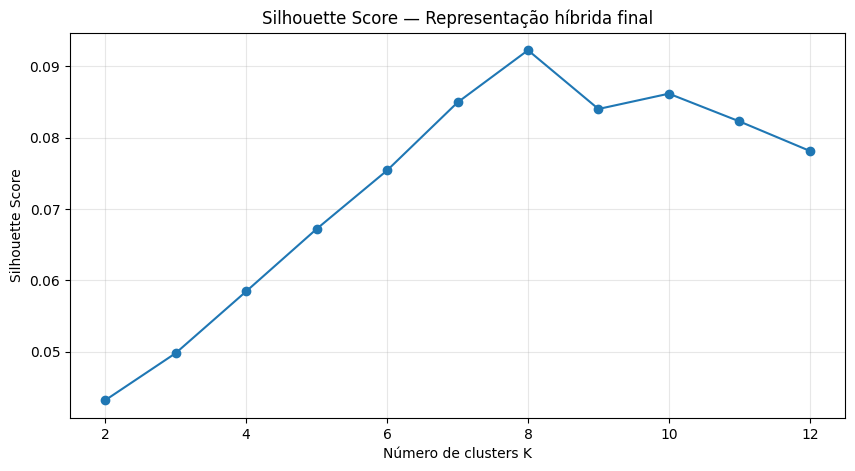

In [65]:
# ============================================================
# GRÁFICO DO SILHOUETTE SCORE — HÍBRIDO FINAL
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_resultados_hibrido_final["k"],
    df_resultados_hibrido_final["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score — Representação híbrida final")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)

plt.show()

In [66]:
# ============================================================
# CANDIDATOS INTERPRETÁVEIS — HÍBRIDO FINAL
# ============================================================

df_candidatos_hibrido_final = df_resultados_hibrido_final[
    (df_resultados_hibrido_final["k"] >= 4)
    & (df_resultados_hibrido_final["percentual_menor_cluster"] >= 2.0)
].sort_values(
    by="silhouette_score",
    ascending=False
)

print("Candidatos interpretáveis da representação híbrida final:")
display(df_candidatos_hibrido_final)

Candidatos interpretáveis da representação híbrida final:


,representacao,k,silhouette_score,inertia,menor_cluster,maior_cluster,percentual_menor_cluster,percentual_maior_cluster
6,hibrida_final_bert_tfidf_ner_v2,8,0.092282,2172.657300,123,955,4.55,35.34
5,hibrida_final_bert_tfidf_ner_v2,7,0.084962,2222.191796,151,1014,5.59,37.53
7,hibrida_final_bert_tfidf_ner_v2,9,0.084044,2145.061695,121,955,4.48,35.34
9,hibrida_final_bert_tfidf_ner_v2,11,0.082309,2111.688847,125,531,4.63,19.65
10,hibrida_final_bert_tfidf_ner_v2,12,0.078165,2099.334112,125,513,4.63,18.99
4,hibrida_final_bert_tfidf_ner_v2,6,0.075429,2281.984457,161,1084,5.96,40.12
3,hibrida_final_bert_tfidf_ner_v2,5,0.067223,2342.026666,226,1171,8.36,43.34
2,hibrida_final_bert_tfidf_ner_v2,4,0.058473,2413.772466,245,1354,9.07,50.11


## Escolha do número final de clusters

Para a representação híbrida final, será escolhido automaticamente o melhor valor de `k` entre os candidatos interpretáveis.

Os critérios são:

- `k >= 4`;
- menor cluster com pelo menos 2% da base;
- maior Silhouette Score entre os candidatos.

Essa regra evita soluções muito simples, como `k = 2`, e também evita clusters minúsculos difíceis de interpretar.

Nos testes realizados, a representação híbrida final indicou `k = 8` como melhor candidato interpretável.

In [67]:
# ============================================================
# ESCOLHA DO K HÍBRIDO FINAL
# ============================================================

if len(df_candidatos_hibrido_final) > 0:
    melhor_hibrido_final = df_candidatos_hibrido_final.iloc[0]
else:
    melhor_hibrido_final = df_resultados_hibrido_final.sort_values(
        by="silhouette_score",
        ascending=False
    ).iloc[0]

K_HIBRIDO_FINAL_ESCOLHIDO = int(
    melhor_hibrido_final["k"]
)

print("K híbrido final escolhido:")
print(K_HIBRIDO_FINAL_ESCOLHIDO)

print("\nSilhouette correspondente:")
print(melhor_hibrido_final["silhouette_score"])

K híbrido final escolhido:
8

Silhouette correspondente:
0.09228183783774309


In [68]:
# ============================================================
# TREINAMENTO FINAL DO KMEANS HÍBRIDO
# ============================================================

kmeans_hibrido_final = KMeans(
    n_clusters=K_HIBRIDO_FINAL_ESCOLHIDO,
    random_state=RANDOM_STATE,
    n_init=80
)

clusters_hibridos_final = kmeans_hibrido_final.fit_predict(
    features_hibridas_final_norm
)

df_textos_filtrado["cluster_hibrido_final"] = clusters_hibridos_final

print("Distribuição de textos por cluster híbrido final:")
display(
    df_textos_filtrado["cluster_hibrido_final"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_hibrido_final")
    .reset_index(name="quantidade_textos")
)

Distribuição de textos por cluster híbrido final:


,cluster_hibrido_final,quantidade_textos
0,0,493
1,1,444
2,2,177
3,3,212
4,4,955
5,5,148
6,6,150
7,7,123


# 16. Interpretação dos clusters

O KMeans gera apenas números de clusters. Para interpretar o significado de cada grupo, vamos usar três fontes:

1. **Títulos representativos**

   Projetos mais próximos do centróide de cada cluster.

2. **TF-IDF médio por cluster**

   Termos que aparecem com maior relevância média nos textos do cluster.

3. **Entidades NER por cluster**

   Labels temáticas mais frequentes em cada grupo.

Essa combinação permite atribuir nomes interpretáveis aos clusters finais.

In [69]:
# ============================================================
# TÍTULOS REPRESENTATIVOS PRÓXIMOS DOS CENTRÓIDES
# ============================================================

def obter_titulos_proximos_centroides(
    df_base,
    embeddings_cluster,
    kmeans,
    coluna_cluster,
    n=10
):
    """
    Retorna os títulos mais próximos do centróide de cada cluster.
    """

    registros = []

    for cluster_id in sorted(df_base[coluna_cluster].unique()):
        indices_cluster = np.where(
            df_base[coluna_cluster].values == cluster_id
        )[0]

        centroide = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

        distancias_cluster = np.linalg.norm(
            embeddings_cluster[indices_cluster] - centroide,
            axis=1
        )

        ordem = np.argsort(
            distancias_cluster
        )[:n]

        for posicao, indice_local in enumerate(ordem, start=1):
            indice_df = indices_cluster[indice_local]

            registros.append({
                "cluster": cluster_id,
                "posicao": posicao,
                "titulo": df_base.iloc[indice_df]["titulo"],
                "qtd_palavras": df_base.iloc[indice_df]["qtd_palavras"],
                "distancia_centroide": distancias_cluster[indice_local]
            })

    return pd.DataFrame(registros)


df_titulos_hibrido_final = obter_titulos_proximos_centroides(
    df_base=df_textos_filtrado,
    embeddings_cluster=features_hibridas_final_norm,
    kmeans=kmeans_hibrido_final,
    coluna_cluster="cluster_hibrido_final",
    n=12
)

display(df_titulos_hibrido_final)

,cluster,posicao,titulo,qtd_palavras,distancia_centroide
0,0,1,Desenvolvimento de Solução para Supervisão de Isolamento e Alarme de Anunciação.,75,0.842171
1,0,2,Teradoros Production Line,108,0.845892
2,0,3,SISTEMA PARA MONITORAMENTO PREDITIVO CONTÍNUO DE ESTEIRAS TRANSPORTADORAS,84,0.846699
3,0,4,FIRMWARE VIA ETHERNET,28,0.849801
4,0,5,Controlador Semafórico Inteligente,68,0.850062
...,...,...,...,...,...
91,7,8,Produto para cuidados anti-rugas e antienvelhecimento baseado no equilíbrio da microbiota cutânea,162,0.625888
92,7,9,SISTEMA INTELIGENTE EXPLICÁVEL PARA PREDIÇÃO DE RISCO CARDIOLÓGICO,82,0.626275
93,7,10,EMBRAPII CEINFAR - Descoberta de compostos ativos (hits) e prova de conceito de novos compostos-líderes (leads) par...,105,0.632133
94,7,11,Desenvolvimento de foco cirúrgico,87,0.637403


In [70]:
# ============================================================
# TF-IDF MÉDIO POR CLUSTER
# ============================================================

def calcular_tfidf_medio_por_cluster(
    df_base,
    coluna_texto="texto",
    coluna_cluster="cluster_hibrido_final",
    top_n=25
):
    """
    Calcula TF-IDF por documento e depois tira a média dos pesos
    dentro de cada cluster.
    """

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words=stopwords_portugues_refinadas,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.75
    )

    matriz = vectorizer.fit_transform(
        df_base[coluna_texto].tolist()
    )

    termos = np.array(
        vectorizer.get_feature_names_out()
    )

    registros = []

    for cluster_id in sorted(df_base[coluna_cluster].unique()):
        posicoes_cluster = np.where(
            df_base[coluna_cluster].values == cluster_id
        )[0]

        matriz_cluster = matriz[posicoes_cluster]

        pesos_medios = np.asarray(
            matriz_cluster.mean(axis=0)
        ).ravel()

        indices_top = pesos_medios.argsort()[::-1][:top_n]

        for posicao, indice_termo in enumerate(indices_top, start=1):
            registros.append({
                "cluster": cluster_id,
                "posicao": posicao,
                "termo": termos[indice_termo],
                "peso_tfidf_medio": pesos_medios[indice_termo]
            })

    return pd.DataFrame(registros)


df_tfidf_hibrido_final_clusters = calcular_tfidf_medio_por_cluster(
    df_base=df_textos_filtrado,
    coluna_texto="texto",
    coluna_cluster="cluster_hibrido_final",
    top_n=25
)

display(df_tfidf_hibrido_final_clusters)

,cluster,posicao,termo,peso_tfidf_medio
0,0,1,monitoramento,0.053814
1,0,2,dispositivo,0.040150
2,0,3,equipamento,0.036108
3,0,4,equipamentos,0.031930
4,0,5,dispositivos,0.031239
...,...,...,...,...
195,7,21,saude mental,0.013501
196,7,22,formulacao,0.013434
197,7,23,biomateriais,0.013342
198,7,24,artificial,0.013250


In [71]:
# ============================================================
# ENTIDADES NER V2 POR CLUSTER
# ============================================================

df_entidades_com_cluster_hibrido_final = df_entidades_v2.merge(
    df_textos_filtrado[["cluster_hibrido_final"]],
    left_on="indice_texto",
    right_index=True,
    how="left"
)

print("Quantidade de entidades com cluster híbrido final associado:")
print(len(df_entidades_com_cluster_hibrido_final))

print("\nQuantidade de entidades sem cluster híbrido final associado:")
print(
    df_entidades_com_cluster_hibrido_final["cluster_hibrido_final"]
    .isna()
    .sum()
)

df_entidades_por_cluster_hibrido_final = (
    df_entidades_com_cluster_hibrido_final
    .groupby(["cluster_hibrido_final", "label"])
    .size()
    .reset_index(name="quantidade_entidades")
    .sort_values(
        ["cluster_hibrido_final", "quantidade_entidades"],
        ascending=[True, False]
    )
)

display(df_entidades_por_cluster_hibrido_final)

Quantidade de entidades com cluster híbrido final associado:
4659

Quantidade de entidades sem cluster híbrido final associado:
0


,cluster_hibrido_final,label,quantidade_entidades
4,0,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,1016
1,0,AREA_COMPUTACAO_DADOS,186
3,0,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,7
0,0,AREA_ALIMENTOS_AGRO,1
2,0,AREA_ENGENHARIA_MATERIAIS,1
6,1,AREA_COMPUTACAO_DADOS,836
9,1,AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO,172
8,1,AREA_MEIO_AMBIENTE_SUSTENTABILIDADE,8
5,1,AREA_ALIMENTOS_AGRO,3
7,1,AREA_ENGENHARIA_MATERIAIS,2


In [72]:
# ============================================================
# COBERTURA DO NER V2 POR CLUSTER FINAL
# ============================================================

qtd_entidades_por_texto_v2 = (
    df_entidades_v2
    .groupby("indice_texto")
    .size()
    .rename("qtd_entidades_ner_v2")
)

df_textos_filtrado["qtd_entidades_ner_v2"] = df_textos_filtrado.index.map(
    qtd_entidades_por_texto_v2
).fillna(0).astype(int)

df_textos_filtrado["possui_entidade_ner_v2"] = (
    df_textos_filtrado["qtd_entidades_ner_v2"] > 0
)

df_cobertura_ner_clusters_final = (
    df_textos_filtrado
    .groupby("cluster_hibrido_final")
    .agg(
        quantidade_textos=("texto", "count"),
        textos_com_entidade_ner_v2=("possui_entidade_ner_v2", "sum"),
        media_entidades_por_texto_v2=("qtd_entidades_ner_v2", "mean")
    )
    .reset_index()
)

df_cobertura_ner_clusters_final["textos_sem_entidade_ner_v2"] = (
    df_cobertura_ner_clusters_final["quantidade_textos"]
    - df_cobertura_ner_clusters_final["textos_com_entidade_ner_v2"]
)

df_cobertura_ner_clusters_final["percentual_com_entidade_ner_v2"] = (
    df_cobertura_ner_clusters_final["textos_com_entidade_ner_v2"]
    / df_cobertura_ner_clusters_final["quantidade_textos"]
    * 100
).round(2)

df_cobertura_ner_clusters_final["percentual_sem_entidade_ner_v2"] = (
    df_cobertura_ner_clusters_final["textos_sem_entidade_ner_v2"]
    / df_cobertura_ner_clusters_final["quantidade_textos"]
    * 100
).round(2)

display(df_cobertura_ner_clusters_final)

,cluster_hibrido_final,quantidade_textos,textos_com_entidade_ner_v2,media_entidades_por_texto_v2,textos_sem_entidade_ner_v2,percentual_com_entidade_ner_v2,percentual_sem_entidade_ner_v2
0,0,493,493,2.456389,0,100.0,0.0
1,1,444,444,2.299550,0,100.0,0.0
2,2,177,177,2.548023,0,100.0,0.0
3,3,212,212,2.905660,0,100.0,0.0
4,4,955,0,0.000000,955,0.0,100.0
5,5,148,148,3.189189,0,100.0,0.0
6,6,150,150,3.526667,0,100.0,0.0
7,7,123,123,2.918699,0,100.0,0.0


In [73]:
# ============================================================
# RESUMO DOS CLUSTERS FINAIS
# ============================================================

resumo_hibrido_final = []

for cluster_id in sorted(df_textos_filtrado["cluster_hibrido_final"].unique()):
    df_cluster = df_textos_filtrado[
        df_textos_filtrado["cluster_hibrido_final"] == cluster_id
    ]

    termos_principais = (
        df_tfidf_hibrido_final_clusters[
            df_tfidf_hibrido_final_clusters["cluster"] == cluster_id
        ]
        .head(10)["termo"]
        .tolist()
    )

    labels_principais = (
        df_entidades_por_cluster_hibrido_final[
            df_entidades_por_cluster_hibrido_final["cluster_hibrido_final"] == cluster_id
        ]
        .head(4)
        .apply(
            lambda linha: f"{linha['label']} ({linha['quantidade_entidades']})",
            axis=1
        )
        .tolist()
    )

    titulos_representativos = (
        df_titulos_hibrido_final[
            df_titulos_hibrido_final["cluster"] == cluster_id
        ]
        .head(5)["titulo"]
        .tolist()
    )

    resumo_hibrido_final.append({
        "cluster": cluster_id,
        "quantidade_textos": len(df_cluster),
        "termos_principais": ", ".join(termos_principais),
        "labels_ner_principais": ", ".join(labels_principais),
        "titulos_representativos": " | ".join(titulos_representativos)
    })

df_resumo_hibrido_final = pd.DataFrame(
    resumo_hibrido_final
)

display(df_resumo_hibrido_final)

,cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,493,"monitoramento, dispositivo, equipamento, equipamentos, dispositivos, hardware, automacao, software, controle, sensores","AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (1016), AREA_COMPUTACAO_DADOS (186), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (7), ...",Desenvolvimento de Solução para Supervisão de Isolamento e Alarme de Anunciação. | Teradoros Production Line | SISTE...
1,1,444,"software, inteligencia, artificial, inteligencia artificial, plataforma, dados, iot, computacional, nuvem, algoritmos","AREA_COMPUTACAO_DADOS (836), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (172), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (8), A...",Inteligência Artificial na Geração de Métodos Quantitativos para Previsão de Indicadores Econômicos | THEIA | Sistem...
2,2,177,"residuos, sustentavel, producao, residuo, carbono, prima, materiais, tratamento, materia prima, efluentes","AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (367), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (35), AREA_COMPUTACAO_DADOS (20), A...",Desenvolvimento de processos e produtos a partir da pirólise de polietileno para acesso a diferentes mercados | Biop...
3,3,212,"fabricacao, aco, acos, corrosao, manufatura, aditiva, manufatura aditiva, materiais, propriedades, resistencia","AREA_ENGENHARIA_MATERIAIS (482), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (78), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (28...",Influência de diferentes tipos de copolímero Estireno-Butadieno (SBR) nas propriedades físicas e mecânicas de pasta ...
4,4,955,"producao, sistemas, rota, prototipo, controle, plataforma, tratamento, tecnologia, otimizacao, desempenho",,Micropropagação vegetal da alfavaca para obtenção de bioativos de valor agregado com foco no agronegócio. | Maximiza...
5,5,148,"soja, fertilizantes, agricultura, producao, agricola, alimentos, controle, pragas, plantas, cultivo","AREA_ALIMENTOS_AGRO (307), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (62), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (54), ARE...",Desenvolvimento de biofertilizante para mitigação do estresse hídrico de culturas graníferas | Desenvolvimento de um...
6,6,150,"energia, baterias, eletrica, bateria, eletricos, energia eletrica, energetica, veiculos eletricos, veiculos, eficien...","AREA_ENERGIA (314), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (108), AREA_COMPUTACAO_DADOS (59), AREA_MEIO_AMBIENTE_SUST...",Metodologia de projeto e desenvolvimento experimental de conversores CC-CC para aplicação em sistemas fotovoltaicos ...
7,7,123,"saude, producao, enzimas, microrganismos, 19, covid, tratamento, covid 19, monitoramento, diagnostico","AREA_SAUDE_BIOTECNOLOGIA (205), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (65), AREA_COMPUTACAO_DADOS (48), AREA_MEIO_AM...",EMBRAPII CEINFAR  Novos produtos naturais antimicrobianos | Determinação de padrões de expressão gênica e marcadore...


## Nomeação manual dos clusters

Após observar os termos principais, entidades NER e títulos representativos, os clusters serão nomeados manualmente.

Essa nomeação não altera o resultado do KMeans. Ela serve apenas para facilitar a interpretação dos agrupamentos.

Os nomes abaixo correspondem à configuração final observada nos testes com `k = 8`.

In [74]:
# ============================================================
# NOMEAÇÃO DOS CLUSTERS HÍBRIDOS FINAIS
# ============================================================

nomes_clusters_hibrido_final = {
    0: "Sustentabilidade, resíduos e carbono",
    1: "Sistemas, automação e monitoramento",
    2: "Computação, software e inteligência artificial",
    3: "Engenharia de materiais, manufatura e metalurgia",
    4: "Saúde, biotecnologia e aplicações biomédicas",
    5: "Energia, baterias e sistemas elétricos",
    6: "Processos, rotas tecnológicas e projetos técnico-operacionais gerais",
    7: "Agro, alimentos e fertilizantes"
}

df_textos_filtrado["nome_cluster_hibrido_final"] = df_textos_filtrado[
    "cluster_hibrido_final"
].map(nomes_clusters_hibrido_final)

df_resumo_hibrido_final_nomeado = df_resumo_hibrido_final.copy()

df_resumo_hibrido_final_nomeado["nome_cluster"] = df_resumo_hibrido_final_nomeado[
    "cluster"
].map(nomes_clusters_hibrido_final)

df_resumo_hibrido_final_nomeado = df_resumo_hibrido_final_nomeado[
    [
        "cluster",
        "nome_cluster",
        "quantidade_textos",
        "termos_principais",
        "labels_ner_principais",
        "titulos_representativos"
    ]
]

display(df_resumo_hibrido_final_nomeado)

,cluster,nome_cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,"Sustentabilidade, resíduos e carbono",493,"monitoramento, dispositivo, equipamento, equipamentos, dispositivos, hardware, automacao, software, controle, sensores","AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (1016), AREA_COMPUTACAO_DADOS (186), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (7), ...",Desenvolvimento de Solução para Supervisão de Isolamento e Alarme de Anunciação. | Teradoros Production Line | SISTE...
1,1,"Sistemas, automação e monitoramento",444,"software, inteligencia, artificial, inteligencia artificial, plataforma, dados, iot, computacional, nuvem, algoritmos","AREA_COMPUTACAO_DADOS (836), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (172), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (8), A...",Inteligência Artificial na Geração de Métodos Quantitativos para Previsão de Indicadores Econômicos | THEIA | Sistem...
2,2,"Computação, software e inteligência artificial",177,"residuos, sustentavel, producao, residuo, carbono, prima, materiais, tratamento, materia prima, efluentes","AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (367), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (35), AREA_COMPUTACAO_DADOS (20), A...",Desenvolvimento de processos e produtos a partir da pirólise de polietileno para acesso a diferentes mercados | Biop...
3,3,"Engenharia de materiais, manufatura e metalurgia",212,"fabricacao, aco, acos, corrosao, manufatura, aditiva, manufatura aditiva, materiais, propriedades, resistencia","AREA_ENGENHARIA_MATERIAIS (482), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (78), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (28...",Influência de diferentes tipos de copolímero Estireno-Butadieno (SBR) nas propriedades físicas e mecânicas de pasta ...
4,4,"Saúde, biotecnologia e aplicações biomédicas",955,"producao, sistemas, rota, prototipo, controle, plataforma, tratamento, tecnologia, otimizacao, desempenho",,Micropropagação vegetal da alfavaca para obtenção de bioativos de valor agregado com foco no agronegócio. | Maximiza...
5,5,"Energia, baterias e sistemas elétricos",148,"soja, fertilizantes, agricultura, producao, agricola, alimentos, controle, pragas, plantas, cultivo","AREA_ALIMENTOS_AGRO (307), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (62), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (54), ARE...",Desenvolvimento de biofertilizante para mitigação do estresse hídrico de culturas graníferas | Desenvolvimento de um...
6,6,"Processos, rotas tecnológicas e projetos técnico-operacionais gerais",150,"energia, baterias, eletrica, bateria, eletricos, energia eletrica, energetica, veiculos eletricos, veiculos, eficien...","AREA_ENERGIA (314), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (108), AREA_COMPUTACAO_DADOS (59), AREA_MEIO_AMBIENTE_SUST...",Metodologia de projeto e desenvolvimento experimental de conversores CC-CC para aplicação em sistemas fotovoltaicos ...
7,7,"Agro, alimentos e fertilizantes",123,"saude, producao, enzimas, microrganismos, 19, covid, tratamento, covid 19, monitoramento, diagnostico","AREA_SAUDE_BIOTECNOLOGIA (205), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (65), AREA_COMPUTACAO_DADOS (48), AREA_MEIO_AM...",EMBRAPII CEINFAR  Novos produtos naturais antimicrobianos | Determinação de padrões de expressão gênica e marcadore...


# 17. Visualizações finais dos clusters

Nesta etapa, vamos visualizar os clusters finais em duas dimensões.

Serão usadas duas técnicas:

1. **PCA**

   Reduz a representação híbrida final para duas dimensões de forma linear.

2. **t-SNE**

   Reduz a representação para duas dimensões tentando preservar relações locais entre os pontos.

Essas visualizações ajudam a observar a separação dos agrupamentos, mas não devem ser interpretadas como prova definitiva da qualidade dos clusters.

Como a representação original possui muitas dimensões, a projeção em duas dimensões perde informação.

Variância explicada pelos dois componentes PCA:
[0.05173834 0.04223889]

Variância explicada acumulada:
0.0939772328075552


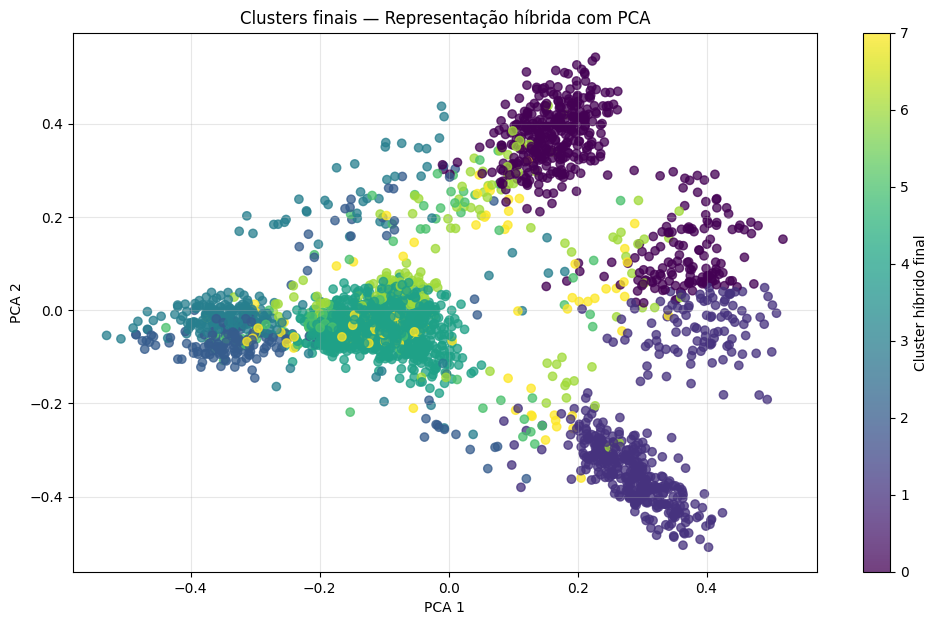

In [75]:
# ============================================================
# PCA 2D — REPRESENTAÇÃO HÍBRIDA FINAL
# ============================================================

pca_visual_hibrido_final = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

features_hibridas_final_pca2 = pca_visual_hibrido_final.fit_transform(
    features_hibridas_final_norm
)

df_textos_filtrado["pca_hibrido_final_1"] = features_hibridas_final_pca2[:, 0]
df_textos_filtrado["pca_hibrido_final_2"] = features_hibridas_final_pca2[:, 1]

print("Variância explicada pelos dois componentes PCA:")
print(pca_visual_hibrido_final.explained_variance_ratio_)

print("\nVariância explicada acumulada:")
print(pca_visual_hibrido_final.explained_variance_ratio_.sum())

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_textos_filtrado["pca_hibrido_final_1"],
    df_textos_filtrado["pca_hibrido_final_2"],
    c=df_textos_filtrado["cluster_hibrido_final"],
    alpha=0.75
)

plt.title("Clusters finais — Representação híbrida com PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster híbrido final")

plt.show()

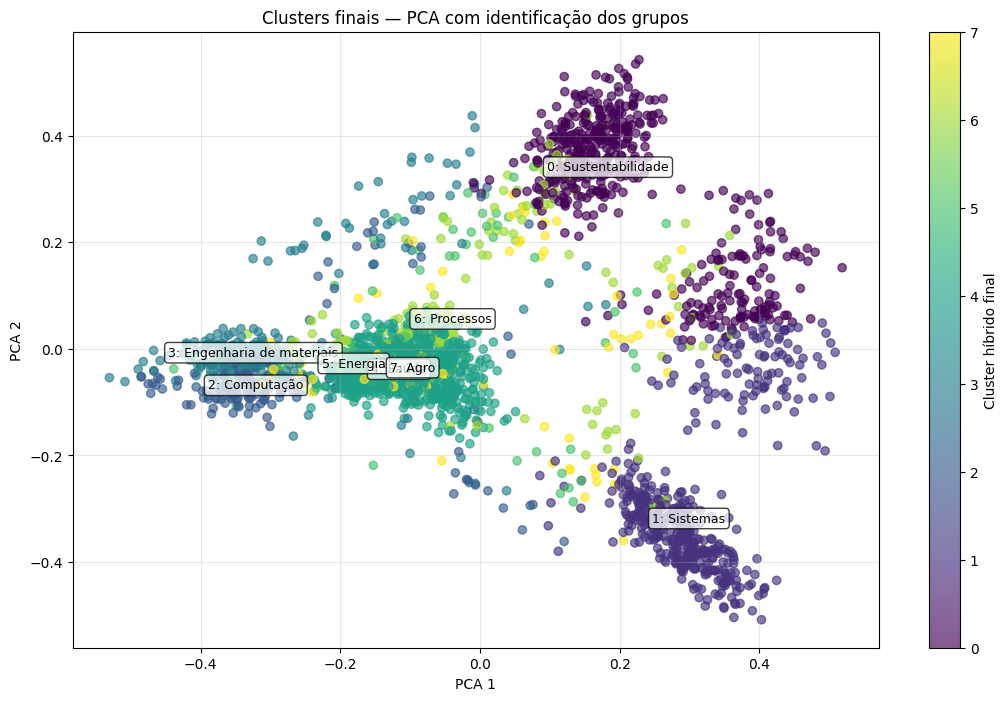

In [76]:
# ============================================================
# PCA 2D COM NOMES DOS CLUSTERS
# ============================================================

plt.figure(figsize=(13, 8))

scatter = plt.scatter(
    df_textos_filtrado["pca_hibrido_final_1"],
    df_textos_filtrado["pca_hibrido_final_2"],
    c=df_textos_filtrado["cluster_hibrido_final"],
    alpha=0.65
)

for cluster_id in sorted(df_textos_filtrado["cluster_hibrido_final"].unique()):
    df_cluster = df_textos_filtrado[
        df_textos_filtrado["cluster_hibrido_final"] == cluster_id
    ]

    x_medio = df_cluster["pca_hibrido_final_1"].median()
    y_medio = df_cluster["pca_hibrido_final_2"].median()

    nome_curto = nomes_clusters_hibrido_final.get(
        cluster_id,
        f"Cluster {cluster_id}"
    )

    texto_label = f"{cluster_id}: {nome_curto.split(',')[0]}"

    plt.text(
        x_medio,
        y_medio,
        texto_label,
        fontsize=9,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            alpha=0.75
        )
    )

plt.title("Clusters finais — PCA com identificação dos grupos")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster híbrido final")

plt.show()

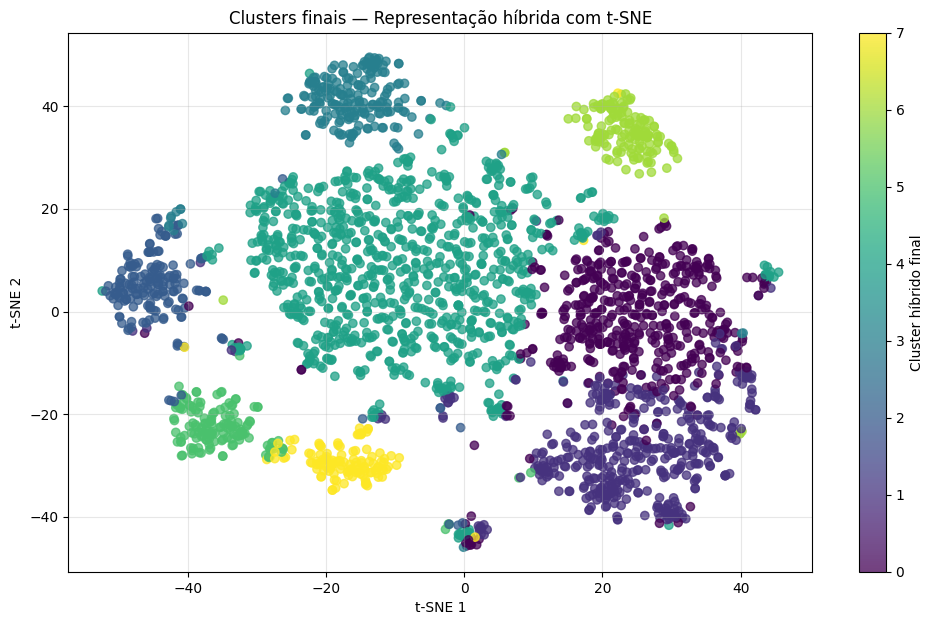

In [77]:
# ============================================================
# t-SNE — REPRESENTAÇÃO HÍBRIDA FINAL
# ============================================================

tsne_hibrido_final = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

features_hibridas_final_tsne = tsne_hibrido_final.fit_transform(
    features_hibridas_final_norm
)

df_textos_filtrado["tsne_hibrido_final_1"] = features_hibridas_final_tsne[:, 0]
df_textos_filtrado["tsne_hibrido_final_2"] = features_hibridas_final_tsne[:, 1]

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_textos_filtrado["tsne_hibrido_final_1"],
    df_textos_filtrado["tsne_hibrido_final_2"],
    c=df_textos_filtrado["cluster_hibrido_final"],
    alpha=0.75
)

plt.title("Clusters finais — Representação híbrida com t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster híbrido final")

plt.show()

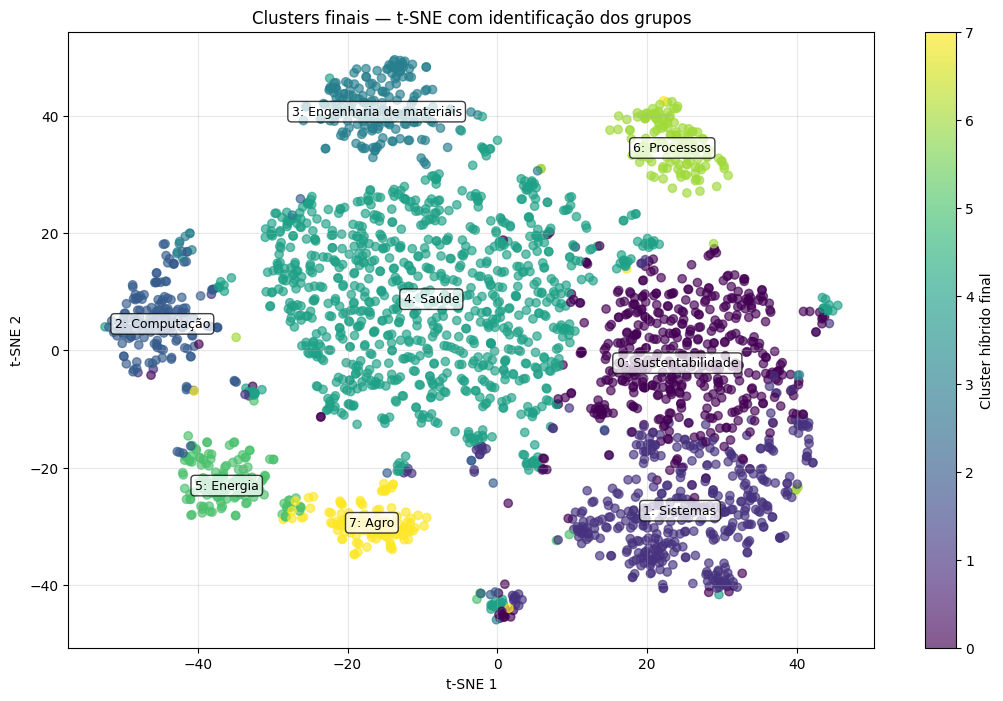

In [78]:
# ============================================================
# t-SNE COM NOMES DOS CLUSTERS
# ============================================================

plt.figure(figsize=(13, 8))

scatter = plt.scatter(
    df_textos_filtrado["tsne_hibrido_final_1"],
    df_textos_filtrado["tsne_hibrido_final_2"],
    c=df_textos_filtrado["cluster_hibrido_final"],
    alpha=0.65
)

for cluster_id in sorted(df_textos_filtrado["cluster_hibrido_final"].unique()):
    df_cluster = df_textos_filtrado[
        df_textos_filtrado["cluster_hibrido_final"] == cluster_id
    ]

    x_medio = df_cluster["tsne_hibrido_final_1"].median()
    y_medio = df_cluster["tsne_hibrido_final_2"].median()

    nome_curto = nomes_clusters_hibrido_final.get(
        cluster_id,
        f"Cluster {cluster_id}"
    )

    texto_label = f"{cluster_id}: {nome_curto.split(',')[0]}"

    plt.text(
        x_medio,
        y_medio,
        texto_label,
        fontsize=9,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            alpha=0.75
        )
    )

plt.title("Clusters finais — t-SNE com identificação dos grupos")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)

plt.colorbar(scatter, label="Cluster híbrido final")

plt.show()

## Observação sobre as visualizações

As visualizações em PCA e t-SNE ajudam a observar padrões gerais, mas devem ser interpretadas com cautela.

O PCA é uma projeção linear e, neste projeto, os dois primeiros componentes explicam apenas parte da variância total da representação híbrida. Por isso, é esperado que alguns clusters apareçam sobrepostos.

O t-SNE pode mostrar separações locais mais nítidas, mas também é uma técnica de visualização, não uma métrica final de qualidade.

A interpretação dos clusters será baseada em conjunto:

- métricas de clusterização;
- termos TF-IDF;
- entidades NER;
- títulos representativos;
- inspeção qualitativa dos grupos.

# 18. Comparação final das abordagens

Durante o projeto, foram comparadas diferentes formas de representar os textos:

1. **BERTimbau com texto original**

   Usa apenas título e descrição, sem reforço do título.

2. **BERTimbau com título reforçado**

   Repete o título antes da descrição, aumentando o peso da informação mais resumida do projeto.

3. **BERTimbau enriquecido com NER V2**

   Acrescenta entidades e labels temáticas ao texto.

4. **Representação híbrida final**

   Combina BERTimbau, TF-IDF/SVD e NER V2.

A comparação considera o Silhouette Score, mas a decisão final também considera a interpretabilidade dos clusters.

In [79]:
# ============================================================
# FUNÇÕES AUXILIARES PARA EXTRAIR RESULTADOS DE COMPARAÇÃO
# ============================================================

def obter_linha_representacao(df_resultados, representacao, k=None, criterio="melhor_interpretavel"):
    """
    Obtém uma linha de resultado para uma representação.

    Se k for informado, retorna a linha daquele k.
    Caso contrário, retorna a melhor linha conforme o critério.
    """

    df_temp = df_resultados[
        df_resultados["representacao"] == representacao
    ].copy()

    if len(df_temp) == 0:
        return None

    if k is not None:
        df_k = df_temp[
            df_temp["k"] == k
        ]

        if len(df_k) == 0:
            return None

        return df_k.iloc[0]

    if criterio == "melhor_interpretavel":
        df_temp = df_temp[
            (df_temp["k"] >= 4)
            & (df_temp["percentual_menor_cluster"] >= 2.0)
        ]

    if len(df_temp) == 0:
        return None

    return df_temp.sort_values(
        by="silhouette_score",
        ascending=False
    ).iloc[0]


def linha_comparacao(
    modelo,
    representacao,
    linha_resultado,
    decisao,
    observacao
):
    """
    Cria uma linha para a tabela de comparação final.
    """

    if linha_resultado is None:
        return {
            "modelo": modelo,
            "representacao": representacao,
            "k": np.nan,
            "silhouette_score": np.nan,
            "decisao": decisao,
            "observacao": observacao
        }

    return {
        "modelo": modelo,
        "representacao": representacao,
        "k": int(linha_resultado["k"]),
        "silhouette_score": float(linha_resultado["silhouette_score"]),
        "decisao": decisao,
        "observacao": observacao
    }

In [80]:
# ============================================================
# COMPARAÇÃO FINAL DAS ABORDAGENS
# ============================================================

linha_original_k2 = obter_linha_representacao(
    df_resultados=df_comparacao_representacoes,
    representacao="texto_original",
    k=2
)

linha_titulo_reforcado = obter_linha_representacao(
    df_resultados=df_comparacao_representacoes,
    representacao="texto_titulo_reforcado",
    k=None,
    criterio="melhor_interpretavel"
)

linha_enriquecido_ner = obter_linha_representacao(
    df_resultados=df_comparacao_representacoes,
    representacao="texto_enriquecido_ner_v2",
    k=None,
    criterio="melhor_interpretavel"
)

linha_hibrido_final = melhor_hibrido_final

comparacao_final = [
    linha_comparacao(
        modelo="bertimbau_original_k2",
        representacao="BERTimbau com texto original",
        linha_resultado=linha_original_k2,
        decisao="Usado como comparação inicial",
        observacao=(
            "Representação simples baseada apenas no texto original. "
            "Serve como referência inicial, mas tende a produzir grupos mais amplos."
        )
    ),
    linha_comparacao(
        modelo="bertimbau_titulo_reforcado",
        representacao="BERTimbau com título reforçado",
        linha_resultado=linha_titulo_reforcado,
        decisao="Usado como comparação",
        observacao=(
            "Avalia se repetir o título melhora a representação temática dos projetos."
        )
    ),
    linha_comparacao(
        modelo="bertimbau_enriquecido_ner_v2",
        representacao="BERTimbau com texto enriquecido por NER V2",
        linha_resultado=linha_enriquecido_ner,
        decisao="Usado como comparação",
        observacao=(
            "Incorpora entidades temáticas ao texto, mas ainda depende apenas de embeddings BERTimbau."
        )
    ),
    {
        "modelo": "hibrido_final_ner_v2",
        "representacao": "BERTimbau + TF-IDF/SVD + NER V2",
        "k": int(K_HIBRIDO_FINAL_ESCOLHIDO),
        "silhouette_score": float(melhor_hibrido_final["silhouette_score"]),
        "decisao": "Escolhido como resultado principal",
        "observacao": (
            "Combina semântica contextual, termos técnicos e entidades temáticas. "
            "Foi escolhido por apresentar a melhor interpretabilidade geral dos clusters."
        )
    }
]

df_comparacao_final_modelos = pd.DataFrame(
    comparacao_final
).sort_values(
    by="silhouette_score",
    ascending=False
)

display(df_comparacao_final_modelos)

,modelo,representacao,k,silhouette_score,decisao,observacao
0,bertimbau_original_k2,BERTimbau com texto original,2,0.113995,Usado como comparação inicial,"Representação simples baseada apenas no texto original. Serve como referência inicial, mas tende a produzir grupos m..."
2,bertimbau_enriquecido_ner_v2,BERTimbau com texto enriquecido por NER V2,4,0.112144,Usado como comparação,"Incorpora entidades temáticas ao texto, mas ainda depende apenas de embeddings BERTimbau."
3,hibrido_final_ner_v2,BERTimbau + TF-IDF/SVD + NER V2,8,0.092282,Escolhido como resultado principal,"Combina semântica contextual, termos técnicos e entidades temáticas. Foi escolhido por apresentar a melhor interpret..."
1,bertimbau_titulo_reforcado,BERTimbau com título reforçado,5,0.091904,Usado como comparação,Avalia se repetir o título melhora a representação temática dos projetos.


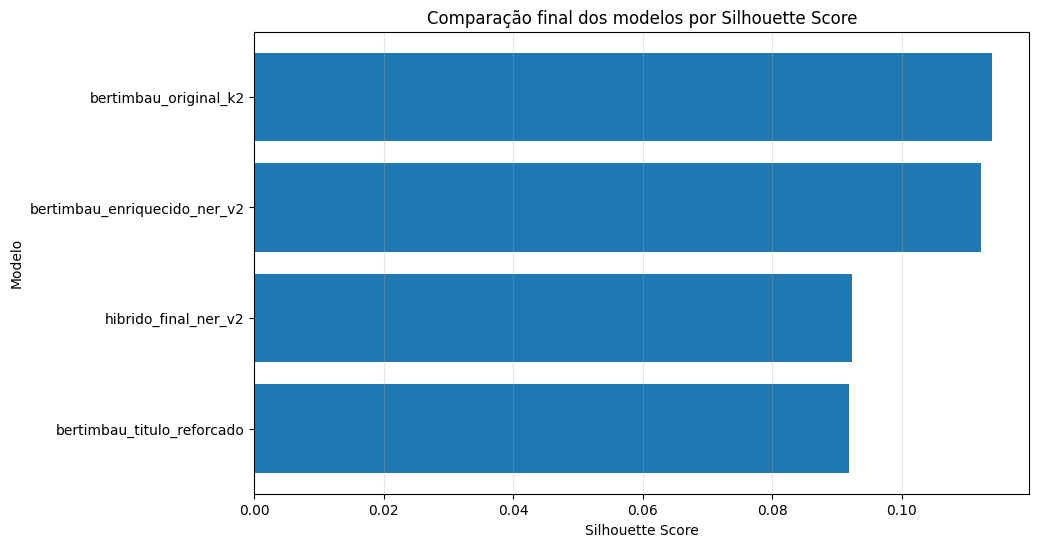

In [81]:
# ============================================================
# GRÁFICO DA COMPARAÇÃO FINAL
# ============================================================

df_plot_comparacao = df_comparacao_final_modelos.dropna(
    subset=["silhouette_score"]
).copy()

df_plot_comparacao = df_plot_comparacao.sort_values(
    by="silhouette_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    df_plot_comparacao["modelo"],
    df_plot_comparacao["silhouette_score"]
)

plt.title("Comparação final dos modelos por Silhouette Score")
plt.xlabel("Silhouette Score")
plt.ylabel("Modelo")
plt.grid(True, axis="x", alpha=0.3)

plt.show()

## Decisão final

A representação escolhida como resultado principal foi a representação híbrida final:

BERTimbau + TF-IDF/SVD + NER V2

Essa abordagem foi escolhida porque combina três tipos de informação:

o significado contextual dos textos, capturado pelo BERTimbau;

os termos técnicos relevantes, capturados pelo TF-IDF/SVD;

as áreas temáticas reconhecidas pelo NER personalizado.


Embora o Silhouette Score não seja extremamente alto, os clusters finais apresentaram boa interpretabilidade temática.

Além disso, a inclusão da label AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO melhorou a explicação de projetos ligados a sistemas, controle, monitoramento, hardware, equipamentos e automação.

# 19. Análise dos clusters finais

A tabela abaixo apresenta a interpretação final dos clusters gerados pela representação híbrida.

Os nomes foram atribuídos manualmente a partir dos termos TF-IDF, entidades NER e títulos representativos.

In [82]:
# ============================================================
# TABELA FINAL DOS CLUSTERS NOMEADOS
# ============================================================

display(df_resumo_hibrido_final_nomeado)

,cluster,nome_cluster,quantidade_textos,termos_principais,labels_ner_principais,titulos_representativos
0,0,"Sustentabilidade, resíduos e carbono",493,"monitoramento, dispositivo, equipamento, equipamentos, dispositivos, hardware, automacao, software, controle, sensores","AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (1016), AREA_COMPUTACAO_DADOS (186), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (7), ...",Desenvolvimento de Solução para Supervisão de Isolamento e Alarme de Anunciação. | Teradoros Production Line | SISTE...
1,1,"Sistemas, automação e monitoramento",444,"software, inteligencia, artificial, inteligencia artificial, plataforma, dados, iot, computacional, nuvem, algoritmos","AREA_COMPUTACAO_DADOS (836), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (172), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (8), A...",Inteligência Artificial na Geração de Métodos Quantitativos para Previsão de Indicadores Econômicos | THEIA | Sistem...
2,2,"Computação, software e inteligência artificial",177,"residuos, sustentavel, producao, residuo, carbono, prima, materiais, tratamento, materia prima, efluentes","AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (367), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (35), AREA_COMPUTACAO_DADOS (20), A...",Desenvolvimento de processos e produtos a partir da pirólise de polietileno para acesso a diferentes mercados | Biop...
3,3,"Engenharia de materiais, manufatura e metalurgia",212,"fabricacao, aco, acos, corrosao, manufatura, aditiva, manufatura aditiva, materiais, propriedades, resistencia","AREA_ENGENHARIA_MATERIAIS (482), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (78), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (28...",Influência de diferentes tipos de copolímero Estireno-Butadieno (SBR) nas propriedades físicas e mecânicas de pasta ...
4,4,"Saúde, biotecnologia e aplicações biomédicas",955,"producao, sistemas, rota, prototipo, controle, plataforma, tratamento, tecnologia, otimizacao, desempenho",,Micropropagação vegetal da alfavaca para obtenção de bioativos de valor agregado com foco no agronegócio. | Maximiza...
5,5,"Energia, baterias e sistemas elétricos",148,"soja, fertilizantes, agricultura, producao, agricola, alimentos, controle, pragas, plantas, cultivo","AREA_ALIMENTOS_AGRO (307), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (62), AREA_MEIO_AMBIENTE_SUSTENTABILIDADE (54), ARE...",Desenvolvimento de biofertilizante para mitigação do estresse hídrico de culturas graníferas | Desenvolvimento de um...
6,6,"Processos, rotas tecnológicas e projetos técnico-operacionais gerais",150,"energia, baterias, eletrica, bateria, eletricos, energia eletrica, energetica, veiculos eletricos, veiculos, eficien...","AREA_ENERGIA (314), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (108), AREA_COMPUTACAO_DADOS (59), AREA_MEIO_AMBIENTE_SUST...",Metodologia de projeto e desenvolvimento experimental de conversores CC-CC para aplicação em sistemas fotovoltaicos ...
7,7,"Agro, alimentos e fertilizantes",123,"saude, producao, enzimas, microrganismos, 19, covid, tratamento, covid 19, monitoramento, diagnostico","AREA_SAUDE_BIOTECNOLOGIA (205), AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO (65), AREA_COMPUTACAO_DADOS (48), AREA_MEIO_AM...",EMBRAPII CEINFAR  Novos produtos naturais antimicrobianos | Determinação de padrões de expressão gênica e marcadore...


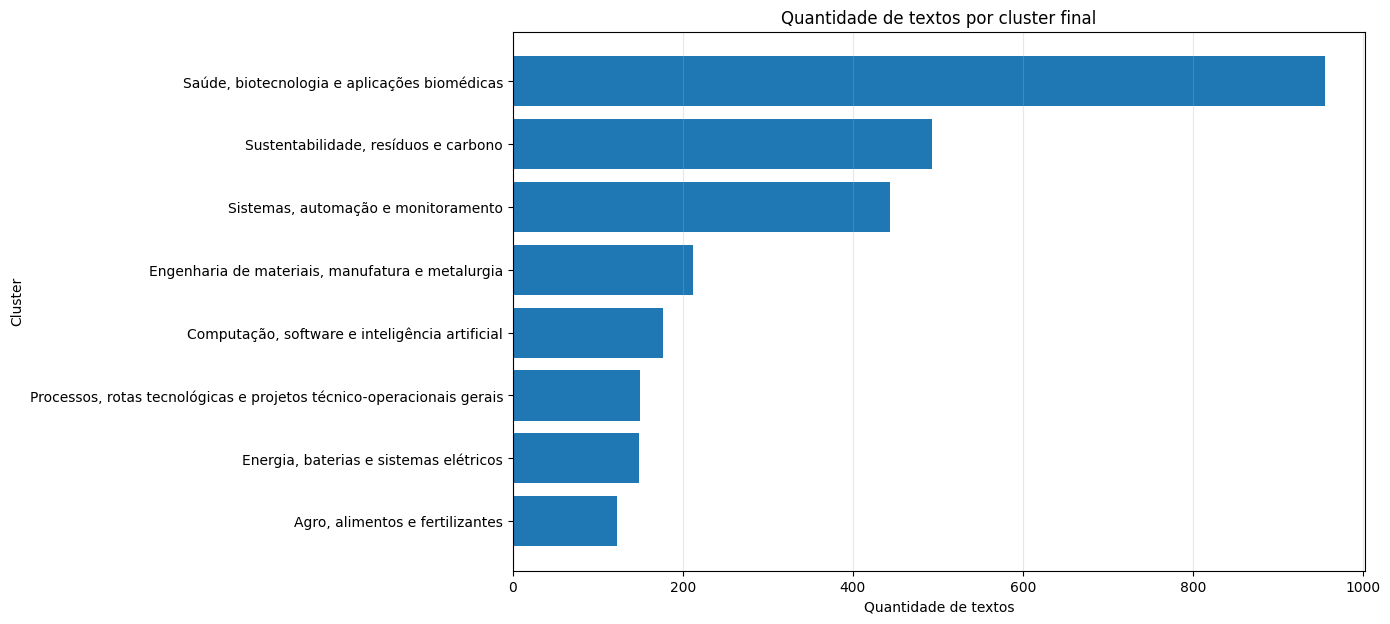

,nome_cluster,quantidade_textos
0,"Saúde, biotecnologia e aplicações biomédicas",955
1,"Sustentabilidade, resíduos e carbono",493
2,"Sistemas, automação e monitoramento",444
3,"Engenharia de materiais, manufatura e metalurgia",212
4,"Computação, software e inteligência artificial",177
5,"Processos, rotas tecnológicas e projetos técnico-operacionais gerais",150
6,"Energia, baterias e sistemas elétricos",148
7,"Agro, alimentos e fertilizantes",123


In [83]:
# ============================================================
# GRÁFICO DA QUANTIDADE DE TEXTOS POR CLUSTER FINAL
# ============================================================

df_distribuicao_cluster_final = (
    df_textos_filtrado["nome_cluster_hibrido_final"]
    .value_counts()
    .reset_index()
)

df_distribuicao_cluster_final.columns = [
    "nome_cluster",
    "quantidade_textos"
]

df_distribuicao_cluster_final = df_distribuicao_cluster_final.sort_values(
    by="quantidade_textos",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    df_distribuicao_cluster_final["nome_cluster"],
    df_distribuicao_cluster_final["quantidade_textos"]
)

plt.title("Quantidade de textos por cluster final")
plt.xlabel("Quantidade de textos")
plt.ylabel("Cluster")
plt.grid(True, axis="x", alpha=0.3)

plt.show()

display(df_distribuicao_cluster_final.sort_values(
    by="quantidade_textos",
    ascending=False
))

In [84]:
# ============================================================
# COBERTURA DO NER POR CLUSTER FINAL COM NOMES
# ============================================================

df_cobertura_ner_clusters_final_nomeado = df_cobertura_ner_clusters_final.copy()

df_cobertura_ner_clusters_final_nomeado["nome_cluster"] = (
    df_cobertura_ner_clusters_final_nomeado["cluster_hibrido_final"]
    .map(nomes_clusters_hibrido_final)
)

df_cobertura_ner_clusters_final_nomeado = df_cobertura_ner_clusters_final_nomeado[
    [
        "cluster_hibrido_final",
        "nome_cluster",
        "quantidade_textos",
        "textos_com_entidade_ner_v2",
        "textos_sem_entidade_ner_v2",
        "percentual_com_entidade_ner_v2",
        "percentual_sem_entidade_ner_v2",
        "media_entidades_por_texto_v2"
    ]
]

display(df_cobertura_ner_clusters_final_nomeado)

,cluster_hibrido_final,nome_cluster,quantidade_textos,textos_com_entidade_ner_v2,textos_sem_entidade_ner_v2,percentual_com_entidade_ner_v2,percentual_sem_entidade_ner_v2,media_entidades_por_texto_v2
0,0,"Sustentabilidade, resíduos e carbono",493,493,0,100.0,0.0,2.456389
1,1,"Sistemas, automação e monitoramento",444,444,0,100.0,0.0,2.299550
2,2,"Computação, software e inteligência artificial",177,177,0,100.0,0.0,2.548023
3,3,"Engenharia de materiais, manufatura e metalurgia",212,212,0,100.0,0.0,2.905660
4,4,"Saúde, biotecnologia e aplicações biomédicas",955,0,955,0.0,100.0,0.000000
5,5,"Energia, baterias e sistemas elétricos",148,148,0,100.0,0.0,3.189189
6,6,"Processos, rotas tecnológicas e projetos técnico-operacionais gerais",150,150,0,100.0,0.0,3.526667
7,7,"Agro, alimentos e fertilizantes",123,123,0,100.0,0.0,2.918699


## Interpretação dos grupos encontrados

A clusterização final identificou oito grupos principais:

1. **Sustentabilidade, resíduos e carbono**

   Reúne projetos relacionados a resíduos, sustentabilidade, carbono, reaproveitamento, reciclagem e materiais de base renovável.

2. **Sistemas, automação e monitoramento**

   Reúne projetos ligados a monitoramento, sensores, dispositivos, equipamentos, automação, hardware e coleta de dados.

3. **Computação, software e inteligência artificial**

   Reúne projetos de software, plataformas digitais, inteligência artificial, algoritmos, processamento de dados e soluções computacionais.

4. **Engenharia de materiais, manufatura e metalurgia**

   Reúne projetos sobre fabricação, aço, manufatura, corrosão, polímeros, materiais e processos industriais.

5. **Saúde, biotecnologia e aplicações biomédicas**

   Reúne projetos relacionados a saúde, enzimas, microrganismos, aplicações biomédicas e biotecnologia.

6. **Energia, baterias e sistemas elétricos**

   Reúne projetos ligados a energia elétrica, baterias, veículos elétricos, eficiência energética e sistemas de geração ou armazenamento.

7. **Processos, rotas tecnológicas e projetos técnico-operacionais gerais**

   Reúne projetos com linguagem mais geral sobre sistemas, controle, rotas tecnológicas, otimização, validação e processos. Esse cluster é uma limitação importante do modelo, pois muitos textos desse grupo não receberam entidades NER.

8. **Agro, alimentos e fertilizantes**

   Reúne projetos relacionados a agricultura, fertilizantes, soja, alimentos, biofertilizantes, bioinsumos e tecnologias agroindustriais.

## Limitação observada no cluster técnico-operacional geral

Mesmo após a criação da label `AREA_SISTEMAS_AUTOMACAO_MONITORAMENTO`, ainda permaneceu um cluster grande com poucos ou nenhum sinal de NER.

Esse resultado sugere que parte da base contém textos com linguagem muito genérica ou transversal, como:

- sistemas;
- controle;
- rotas tecnológicas;
- otimização;
- validação;
- plataformas;
- processos;
- equipamentos;
- soluções técnicas.

Esses termos aparecem em muitas áreas diferentes e, por isso, são difíceis de associar a uma área temática específica.

Assim, esse cluster não deve ser interpretado como erro simples do algoritmo, mas como um grupo residual de projetos técnico-operacionais ou interdisciplinares que exigiria uma modelagem mais refinada.

# 20. Salvamento dos resultados finais

Nesta etapa, serão salvos os principais artefatos do notebook:

- base final com clusters;
- resumo dos clusters;
- comparação final dos modelos;
- entidades extraídas pelo NER;
- cobertura do NER por cluster;
- resultados de KMeans;
- embeddings e features principais.

Esses arquivos podem ser usados para análise posterior, relatório e organização do repositório no GitHub.

In [85]:
# ============================================================
# SALVAMENTO DOS RESULTADOS FINAIS
# ============================================================

df_resumo_hibrido_final_nomeado.to_csv(
    os.path.join(OUTPUT_DIR, "resumo_clusters_hibrido_final_nomeado.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_comparacao_final_modelos.to_csv(
    os.path.join(OUTPUT_DIR, "comparacao_final_modelos.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_textos_filtrado.to_csv(
    os.path.join(OUTPUT_DIR, "df_textos_resultado_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_entidades_v2.to_csv(
    os.path.join(OUTPUT_DIR, "entidades_extraidas_ner_v2.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_cobertura_ner_clusters_final_nomeado.to_csv(
    os.path.join(OUTPUT_DIR, "cobertura_ner_clusters_final_nomeado.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_resultados_hibrido_final.to_csv(
    os.path.join(OUTPUT_DIR, "resultados_kmeans_hibrido_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_candidatos_hibrido_final.to_csv(
    os.path.join(OUTPUT_DIR, "candidatos_kmeans_hibrido_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_titulos_hibrido_final.to_csv(
    os.path.join(OUTPUT_DIR, "titulos_representativos_clusters_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_tfidf_hibrido_final_clusters.to_csv(
    os.path.join(OUTPUT_DIR, "tfidf_medio_por_cluster_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

df_entidades_por_cluster_hibrido_final.to_csv(
    os.path.join(OUTPUT_DIR, "entidades_por_cluster_final.csv"),
    index=False,
    encoding="utf-8-sig"
)

np.save(
    os.path.join(OUTPUT_DIR, "features_hibridas_final_norm.npy"),
    features_hibridas_final_norm
)

print("Resultados finais salvos em:")
print(OUTPUT_DIR)

print("\nArquivos disponíveis:")
for arquivo in sorted(os.listdir(OUTPUT_DIR)):
    print("-", arquivo)

Resultados finais salvos em:
/kaggle/working/resultados_parciais

Arquivos disponíveis:
- candidatos_kmeans_hibrido_final.csv
- candidatos_representacoes_bertimbau.csv
- cobertura_ner_clusters_final_nomeado.csv
- comparacao_final_modelos.csv
- comparacao_representacoes_bertimbau.csv
- comparacao_tfidf_titulo.csv
- df_textos_filtrado_com_embeddings_info.csv
- df_textos_filtrado_com_ner_v2.csv
- df_textos_filtrado_inicial.csv
- df_textos_resultado_final.csv
- distribuicao_training_data_ner_v2.csv
- embeddings_enriquecido_ner_v2.npy
- embeddings_texto_original.npy
- embeddings_titulo_reforcado.npy
- entidades_candidatas_ner_v2.csv
- entidades_extraidas_ner_v2.csv
- entidades_por_cluster_final.csv
- features_hibridas_final_norm.npy
- historico_treinamento_ner_v2.csv
- labels_ner_treino_v2.csv
- metricas_ner_v2_por_label.csv
- resultados_kmeans_hibrido_final.csv
- resumo_clusters_hibrido_final_nomeado.csv
- resumo_limites_tokens_bert.csv
- resumo_ruidos.csv
- termos_candidatos_ner.csv
- tfi

In [86]:
# ============================================================
# COMPACTAÇÃO DOS RESULTADOS FINAIS
# ============================================================

import shutil

arquivo_zip_resultados = "/kaggle/working/resultados_finais_clusterizacao.zip"

if os.path.exists(arquivo_zip_resultados):
    os.remove(arquivo_zip_resultados)

shutil.make_archive(
    base_name=arquivo_zip_resultados.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print("Arquivo ZIP criado:")
print(arquivo_zip_resultados)

Arquivo ZIP criado:
/kaggle/working/resultados_finais_clusterizacao.zip


# 21. Conclusões

Este notebook apresentou uma abordagem de clusterização temática de projetos científicos usando técnicas de Processamento de Linguagem Natural.

A metodologia final combinou:

- limpeza textual conservadora;
- análise exploratória com TF-IDF;
- treinamento de um NER personalizado com spaCy;
- geração de embeddings com BERTimbau;
- construção de uma representação híbrida;
- clusterização com KMeans;
- interpretação dos grupos com TF-IDF, NER e títulos representativos.

A representação escolhida como resultado principal foi:

BERTimbau + TF-IDF/SVD + NER V2


Essa representação foi escolhida porque apresentou o melhor equilíbrio entre métrica e interpretabilidade.

O resultado final agrupou os projetos em oito clusters temáticos:

Sustentabilidade, resíduos e carbono;

Sistemas, automação e monitoramento;

Computação, software e inteligência artificial;

Engenharia de materiais, manufatura e metalurgia;

Saúde, biotecnologia e aplicações biomédicas;

Energia, baterias e sistemas elétricos;

Processos, rotas tecnológicas e projetos técnico-operacionais gerais;

Agro, alimentos e fertilizantes.

O Silhouette Score da representação híbrida final não foi extremamente alto, mas isso é esperado em uma base interdisciplinar, na qual muitos projetos combinam diferentes áreas tecnológicas.

Assim, o objetivo principal não foi obter separação perfeita, mas construir uma metodologia interpretável para análise temática dos textos.

# 22. Limitações

Apesar dos resultados obtidos, o projeto possui algumas limitações importantes.

## 1. Textos curtos e públicos

A base utiliza títulos e descrições públicas dos projetos, e não documentos científicos completos.

Muitos textos são curtos ou resumidos, o que limita a quantidade de informação disponível para os modelos.

## 2. Interdisciplinaridade dos projetos

Muitos projetos combinam áreas diferentes, como:

- inteligência artificial e energia;
- sensores e saúde;
- resíduos e materiais;
- automação e agro;
- software e monitoramento industrial.

Por isso, a separação entre clusters não é naturalmente rígida.

## 3. NER semiautomático

O `TRAINING_DATA` do NER foi construído de forma semiautomática, usando listas de termos de referência.

Isso permitiu criar um modelo mais coerente do que o exemplo inicial, mas ainda não equivale a uma anotação manual feita por especialistas.

## 4. Cobertura limitada das labels

Mesmo com a inclusão da label de sistemas, automação e monitoramento, ainda existe um cluster residual com baixa cobertura de NER.

Isso indica que algumas áreas ou padrões textuais ainda não foram suficientemente cobertos pelas labels.

## 5. KMeans exige número fixo de clusters

O KMeans exige definir previamente o número de clusters.

Essa escolha pode influenciar o resultado e não garante que os grupos naturais da base tenham exatamente o mesmo número de categorias escolhido.

## 6. Visualizações em duas dimensões perdem informação

PCA e t-SNE são úteis para visualização, mas reduzem uma representação de muitas dimensões para apenas duas.

Portanto, sobreposição nos gráficos não significa necessariamente que a clusterização falhou.

# 23. Possíveis melhorias futuras

Para versões futuras do projeto, algumas melhorias podem ser feitas.

## 1. Criar um conjunto de validação manual

Uma melhoria importante seria selecionar uma amostra dos projetos e anotá-la manualmente com labels temáticas.

Isso permitiria avaliar o NER de forma mais confiável.

## 2. Refinar as labels do NER

O cluster residual indica que ainda há padrões temáticos não totalmente capturados.

Possíveis novas labels ou ajustes seriam:

- processos industriais;
- rotas tecnológicas;
- validação experimental;
- gestão e operação;
- plataformas e serviços digitais;
- equipamentos industriais.

## 3. Testar BERTopic

O BERTopic combina embeddings com técnicas de redução dimensional e agrupamento, sendo bastante usado para topic modeling.

Ele poderia ser comparado com a abordagem atual.

## 4. Testar UMAP e HDBSCAN

UMAP poderia ser usado para reduzir dimensionalidade preservando relações locais, e HDBSCAN poderia identificar clusters sem exigir número fixo de grupos.

Isso seria útil porque a base pode conter grupos de tamanhos diferentes e projetos intermediários entre áreas.

## 5. Comparar diferentes pesos da representação híbrida

Os pesos usados na representação híbrida foram definidos empiricamente.

Futuramente, seria possível testar sistematicamente diferentes combinações de pesos para BERTimbau, TF-IDF e NER.

## 6. Testar limites maiores de tokens

Neste notebook foi usado `MAX_LEN_BERT = 256`.

Como alguns textos passam desse limite, versões futuras poderiam testar `MAX_LEN_BERT = 384` ou `512`, comparando custo computacional e ganho de desempenho.

## 7. Usar modelos de sentence embeddings

Outra possibilidade seria testar modelos de embeddings de sentenças, como modelos da família Sentence-BERT multilíngue ou modelos específicos para português.

Esses modelos podem ser mais adequados para representar textos inteiros do que o uso direto do BERT com mean pooling.

# 24. Encerramento

O notebook construiu uma solução completa e interpretável para clusterização temática de projetos científicos.

A principal contribuição foi combinar BERTimbau, TF-IDF e NER personalizado para gerar agrupamentos temáticos mais explicáveis.

O resultado final não deve ser visto como uma classificação definitiva dos projetos, mas como uma ferramenta exploratória para entender padrões temáticos em uma base textual interdisciplinar.

Para a entrega provisória, o notebook já apresenta:

- metodologia clara;
- experimentação com diferentes representações;
- modelo NER personalizado;
- clusterização final interpretável;
- análise das limitações;
- sugestões de melhoria para a próxima etapa do projeto.